# Auxiliar

## Pacotes e configurações

In [ ]:
#pip install --upgrade pip
#pip install factor_analyzer


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis, PCA
import numpy as np
from factor_analyzer import FactorAnalyzer

## Funções

In [2]:
def normalizador_min_max(dados, variaveis):
    
    for j in variaveis:
        menor = min(dados[str(j)]) 
        maior = max(dados[str(j)])
        
        dif = maior - menor
        if dif==0:
            dif=1 
        
        for i in range(dados.shape[0]):
            dados.loc[i,j] = (dados[str(j)][i]-menor)/ dif

    return(dados) 


def normalizador_log(dados, variaveis):
    for j in variaveis:
        for i in range(dados.shape[0]):
            if pd.notnull(dados.loc[i, str(j)]) and dados.loc[i, str(j)] > 0:
                dados.loc[i, str(j)] = np.log(dados.loc[i, str(j)])
            else:
                dados.loc[i, str(j)] = np.log(1e-5)

    return dados 

In [3]:
def PCA_elbow(dados, componentes = 10, seed = 42):
    X = dados
    pca = PCA(n_components= componentes, svd_solver = 'auto',random_state = seed)
    Principal_components=pca.fit_transform(X)
    pca_df = pd.DataFrame(data = Principal_components,
                          #columns = ['PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5', 'PC 6']
                         )
    PC_values = np.arange(pca.n_components_) + 1
    plt.plot(PC_values, pca.explained_variance_ratio_, 'ro-', linewidth=2)
    plt.title('Scree Plot')
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Variance Explained')
    plt.show()

In [4]:
def PCA_explicabilidade(dados, seed = 42):
    X = dados
    n = len(dados.columns) + 1
    pca = PCA(n_components = 0.95)
    pca.fit(X)
    reduced = pca.transform(X)

    pca = PCA(random_state = seed).fit(X)

    %matplotlib inline
    plt.rcParams["figure.figsize"] = (12,6)

    fig, ax = plt.subplots()
    xi = np.arange(1, n, step=1)
    y = np.cumsum(pca.explained_variance_ratio_)

    plt.ylim(0.0,1.1)
    plt.plot(xi, y, marker='o', linestyle='--', color='b')

    plt.xlabel('Number of Components')
    plt.xticks(np.arange(0, n, step=1)) #change from 0-based array index to 1-based human-readable label
    plt.ylabel('Cumulative variance (%)')
    plt.title('The number of components needed to explain variance')

    plt.axhline(y=0.95, color='r', linestyle='-')
    plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

    ax.grid(axis='x')
    plt.show()

In [5]:
#################################
###### Top ABS Correlations #####
#################################


def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

# Importação dos dados

In [6]:
df = pd.read_csv('coordenadas_mapeadas_variaveis.csv')
clusters = pd.read_csv('coord_cluster_6.csv')
df_C = pd.merge(df, clusters, how='inner', left_on=['n_coord'], right_on=['n_coord'])

In [25]:
df_C_aux = pd.merge(df, clusters, how='inner', left_on=['n_coord'], right_on=['n_coord'])

In [8]:
df_C.set_index('n_coord', inplace=True)

# Análise Geral

In [29]:
df_C_aux.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3135 entries, 0 to 3134
Data columns (total 58 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   geometry                                     3135 non-null   object 
 1   n_coord                                      3135 non-null   int64  
 2   Altitude_numerica                            3135 non-null   float64
 3   Declividade_numerica                         3135 non-null   float64
 4   Orientacao_numerica                          3135 non-null   float64
 5   Curv_Vertical_numerica                       3135 non-null   float64
 6   Curv_Horizontal_numerica                     3135 non-null   float64
 7   Declividade_classes_A                        3135 non-null   float64
 8   Declividade_classes_B                        3135 non-null   float64
 9   Declividade_classes_C                        3135 non-null   float64
 10  

--------------------
Vegetacao_Natural_Dominante
--------------------


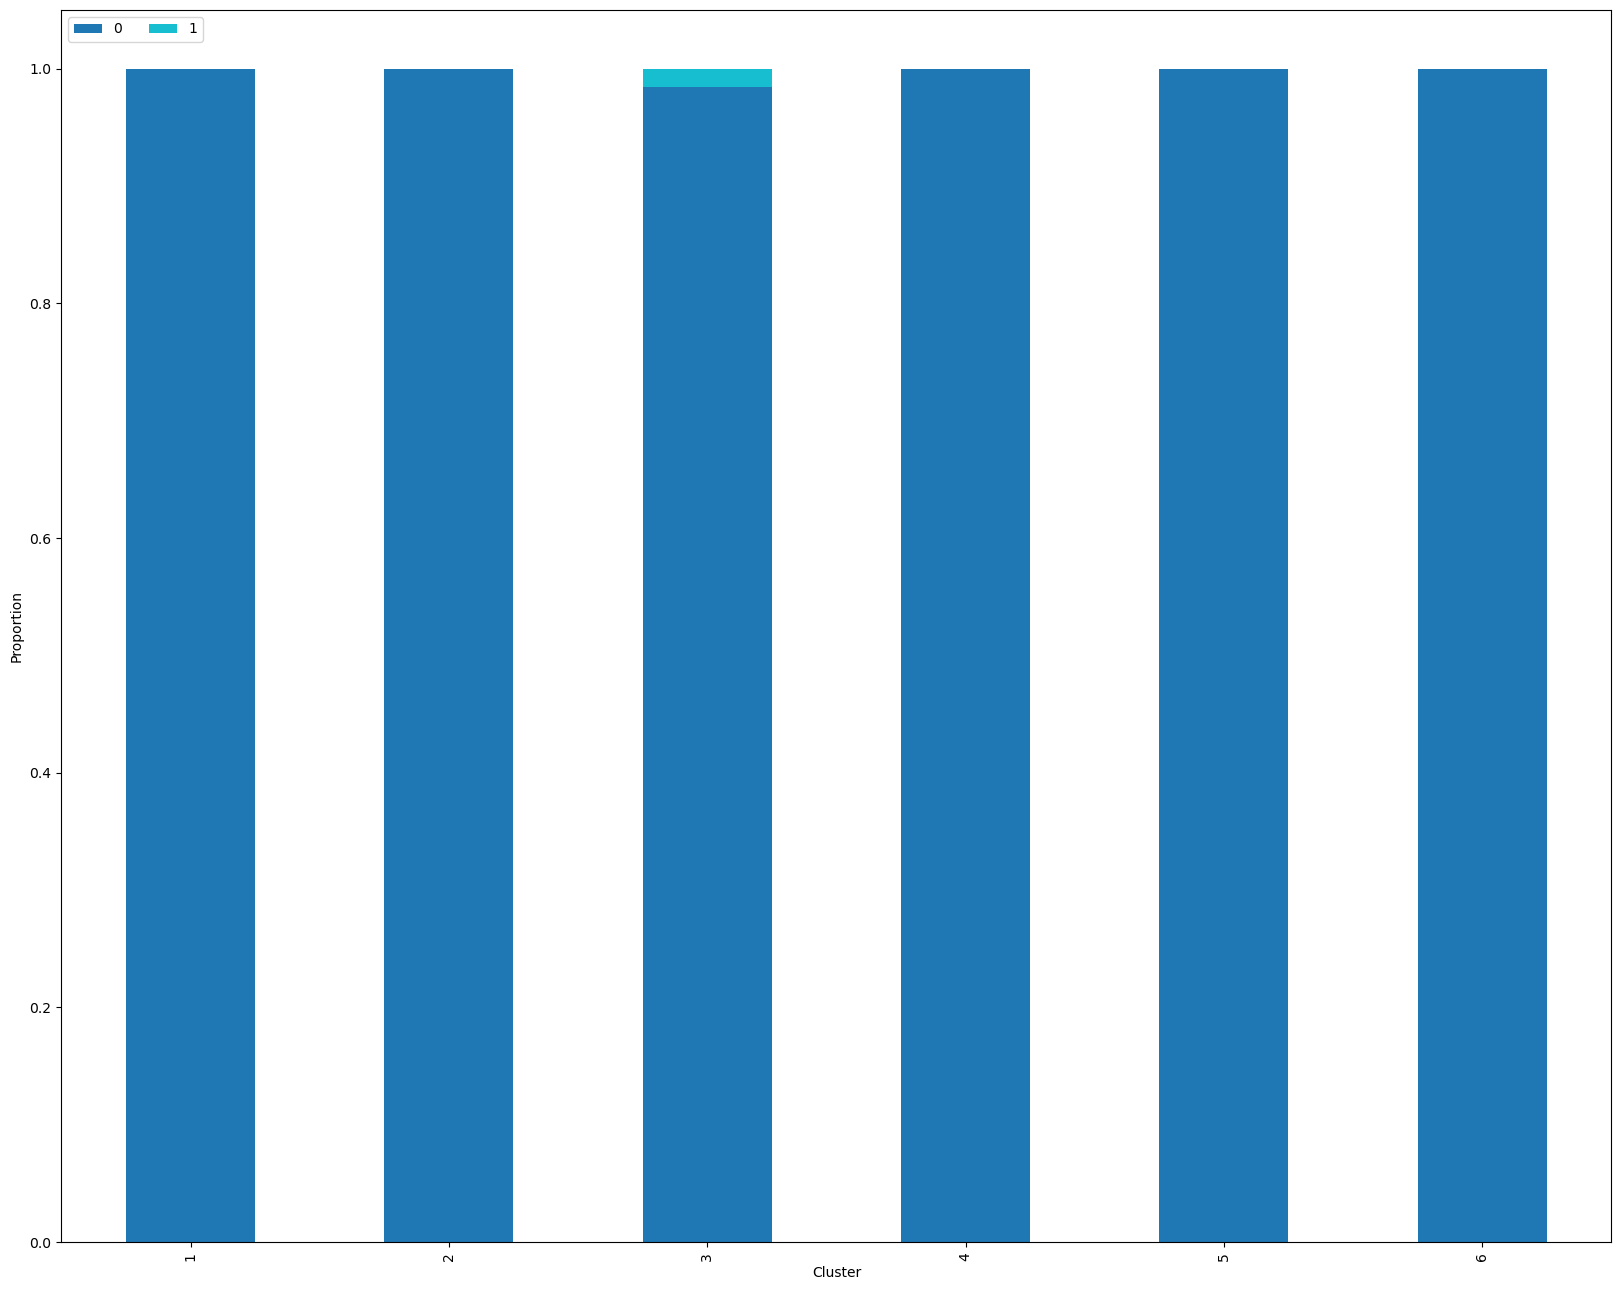

--------------------
Area_Antropica_Dominante
--------------------


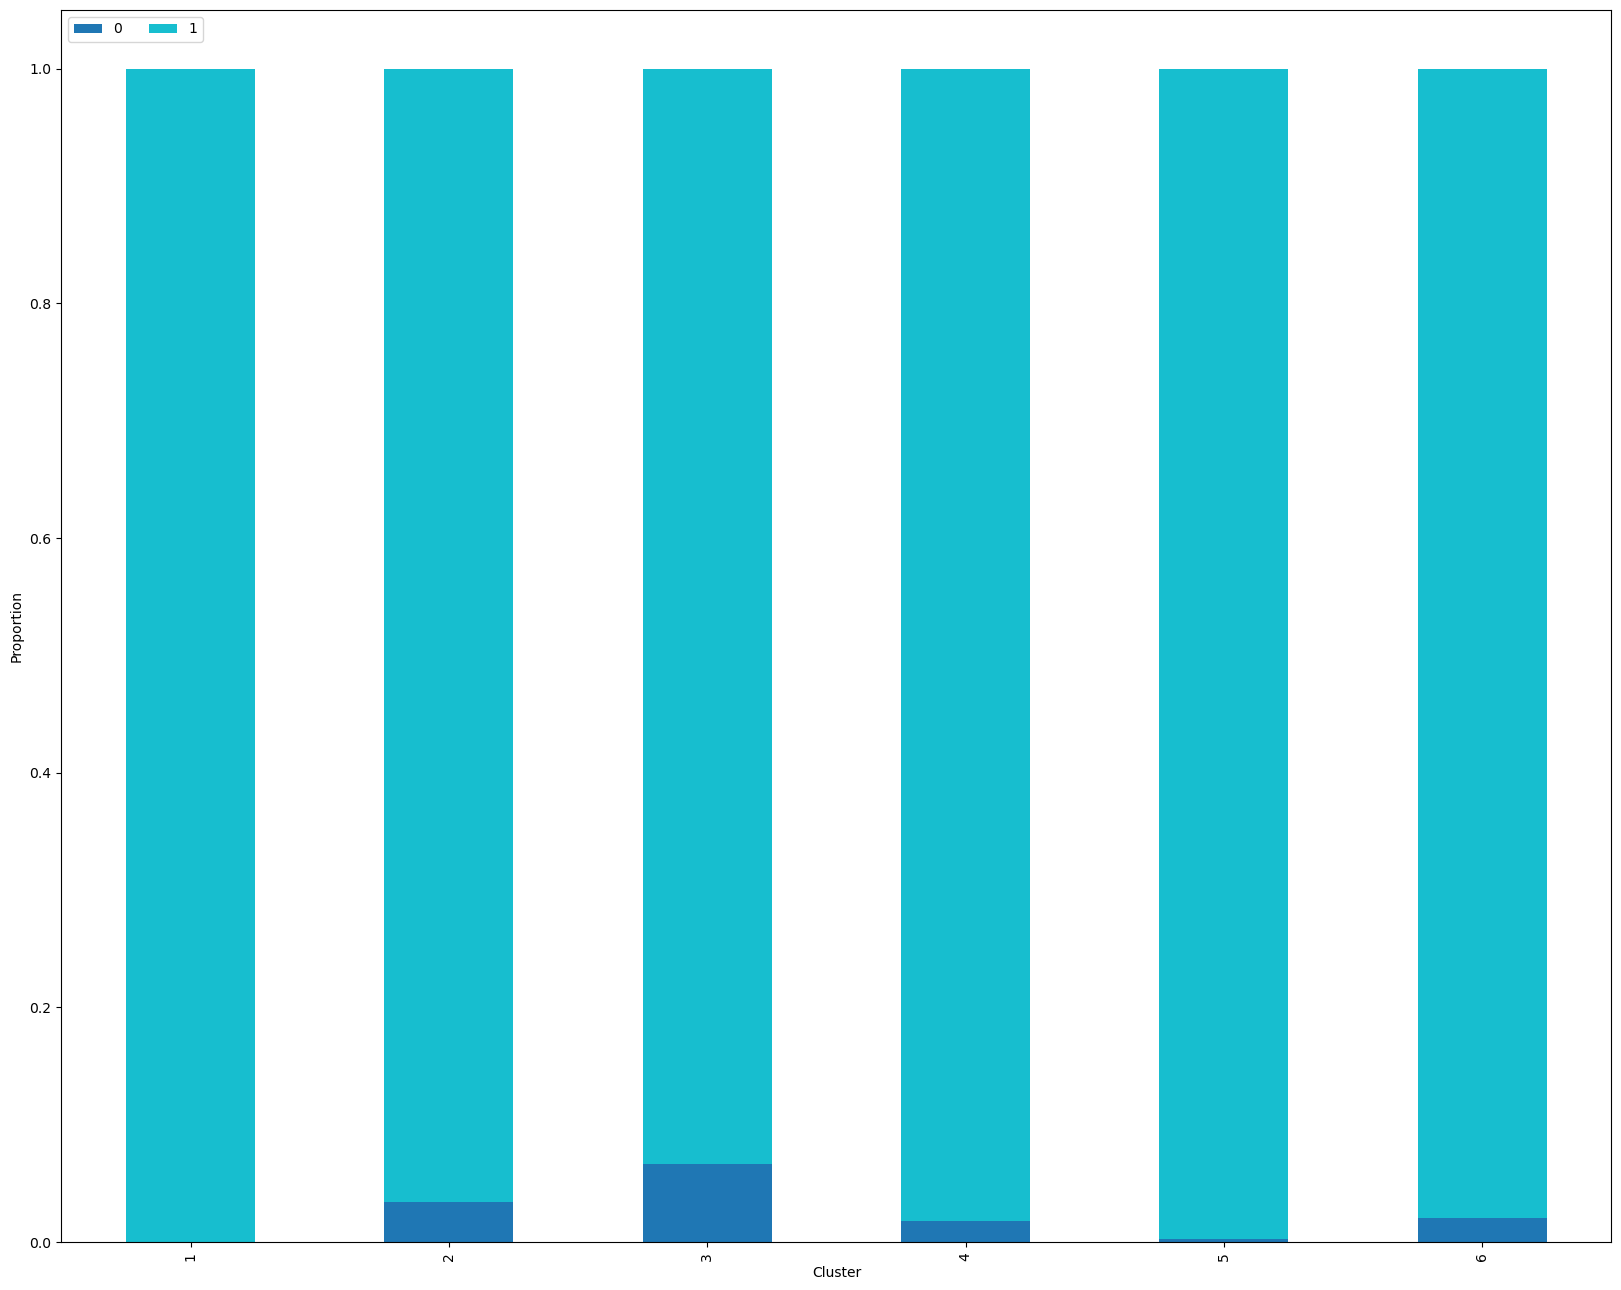

--------------------
Floresta_Ombrofila_Densa
--------------------


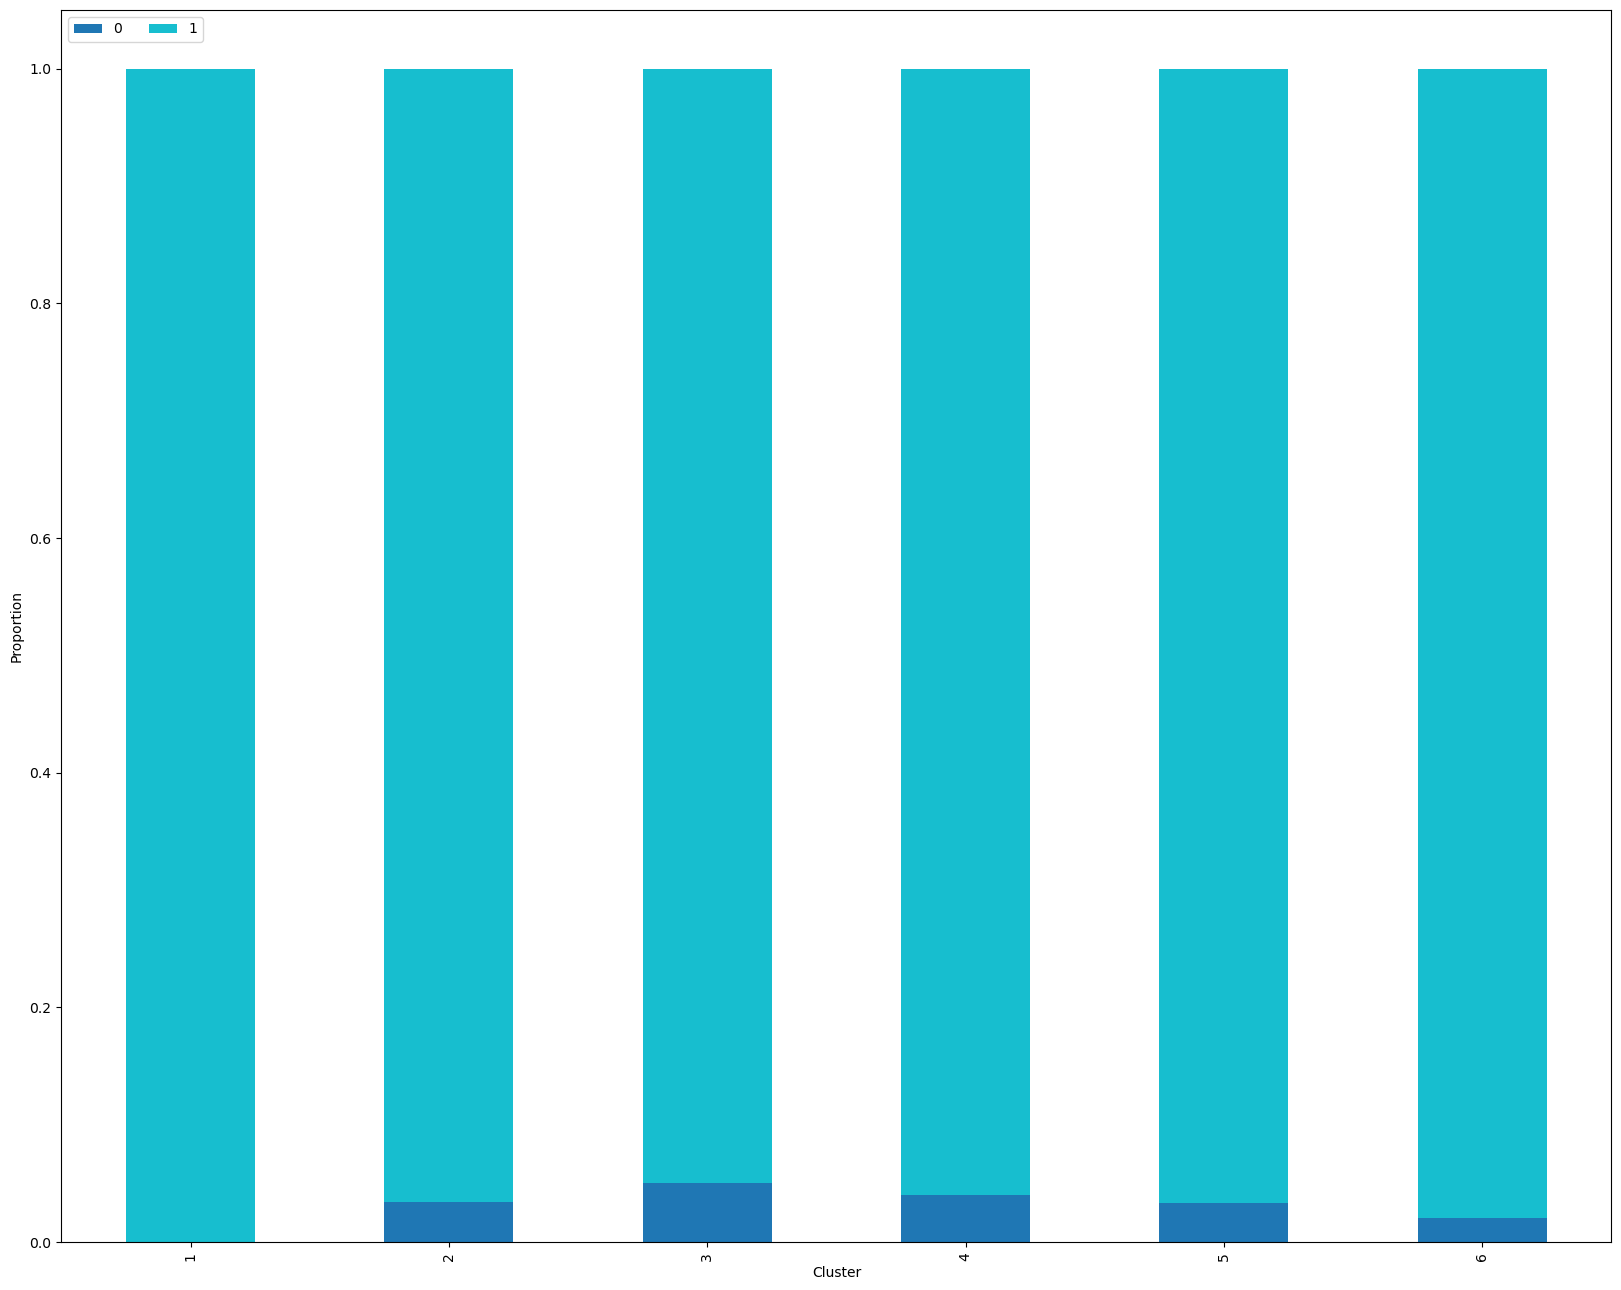

--------------------
Formacao_Pioneira
--------------------


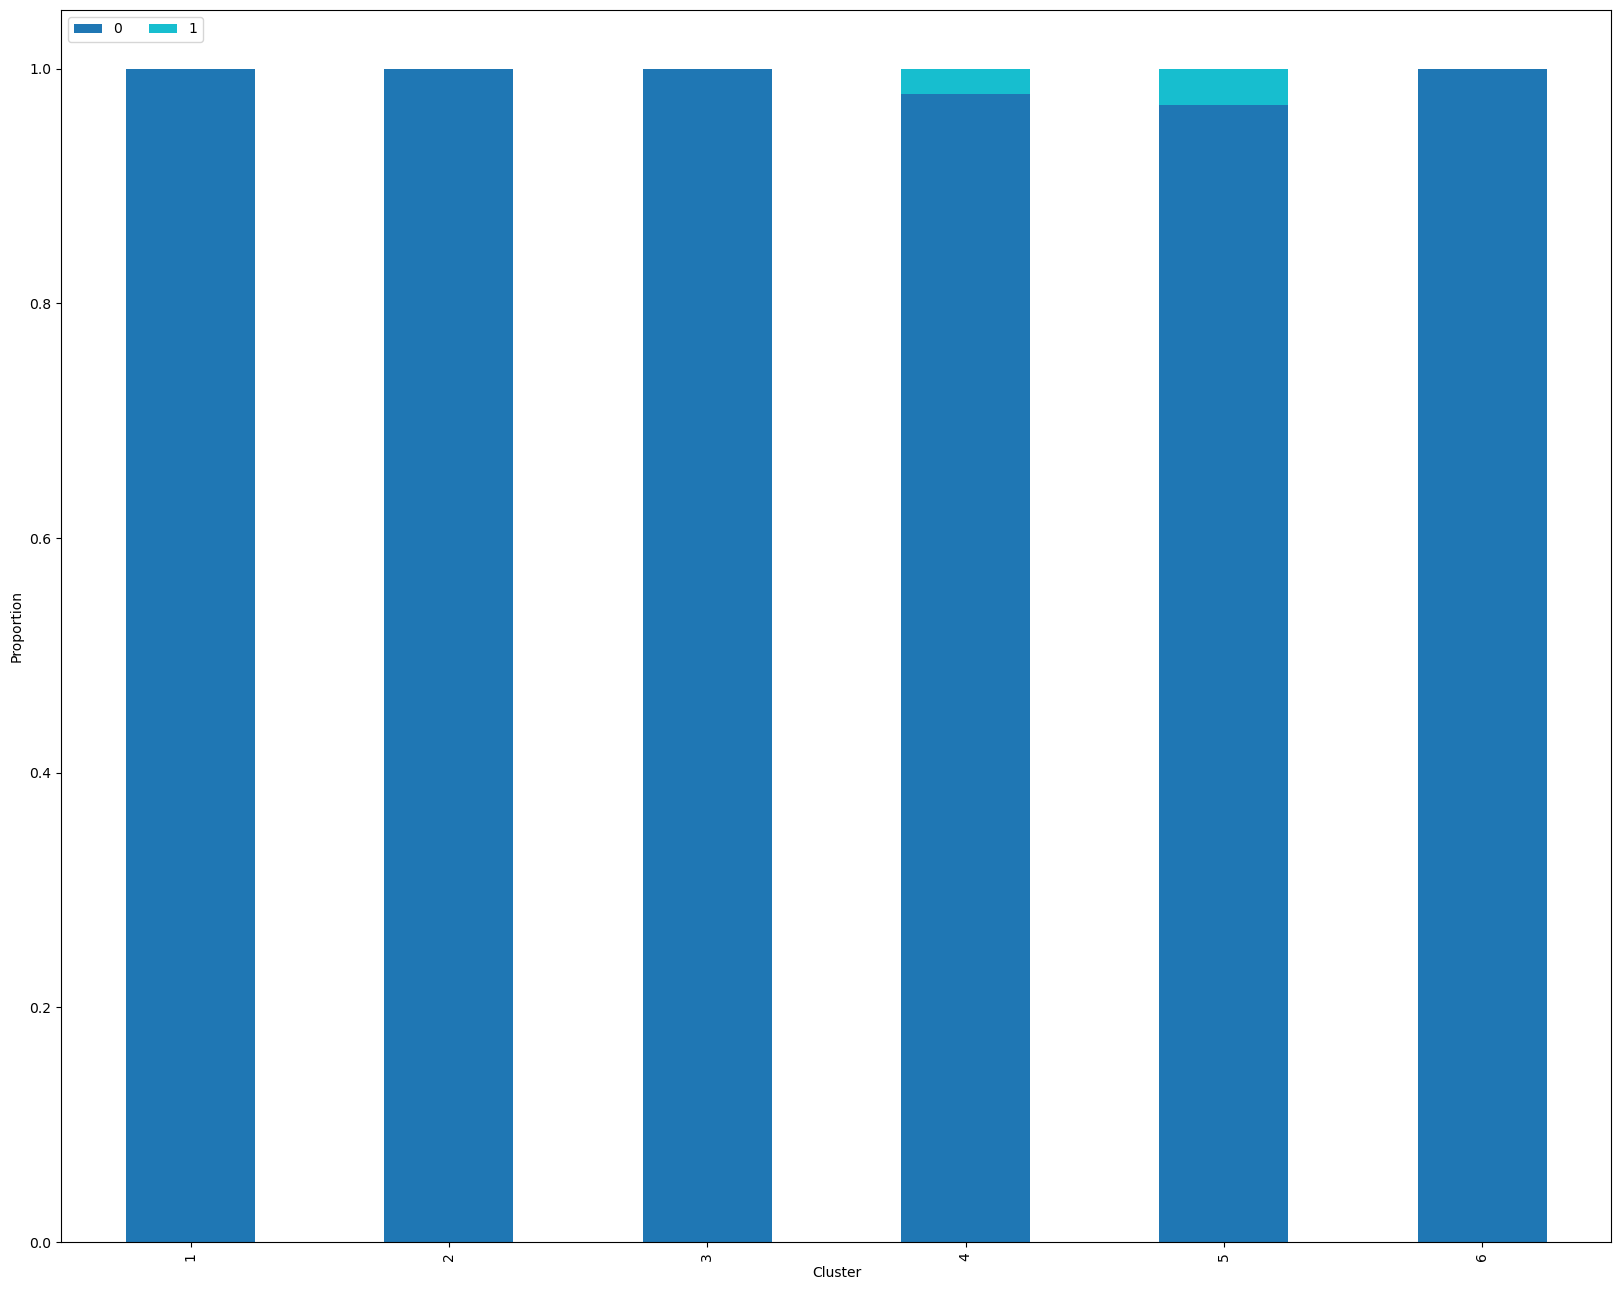

--------------------
Floresta_Ombrofila_Densa_Submontana
--------------------


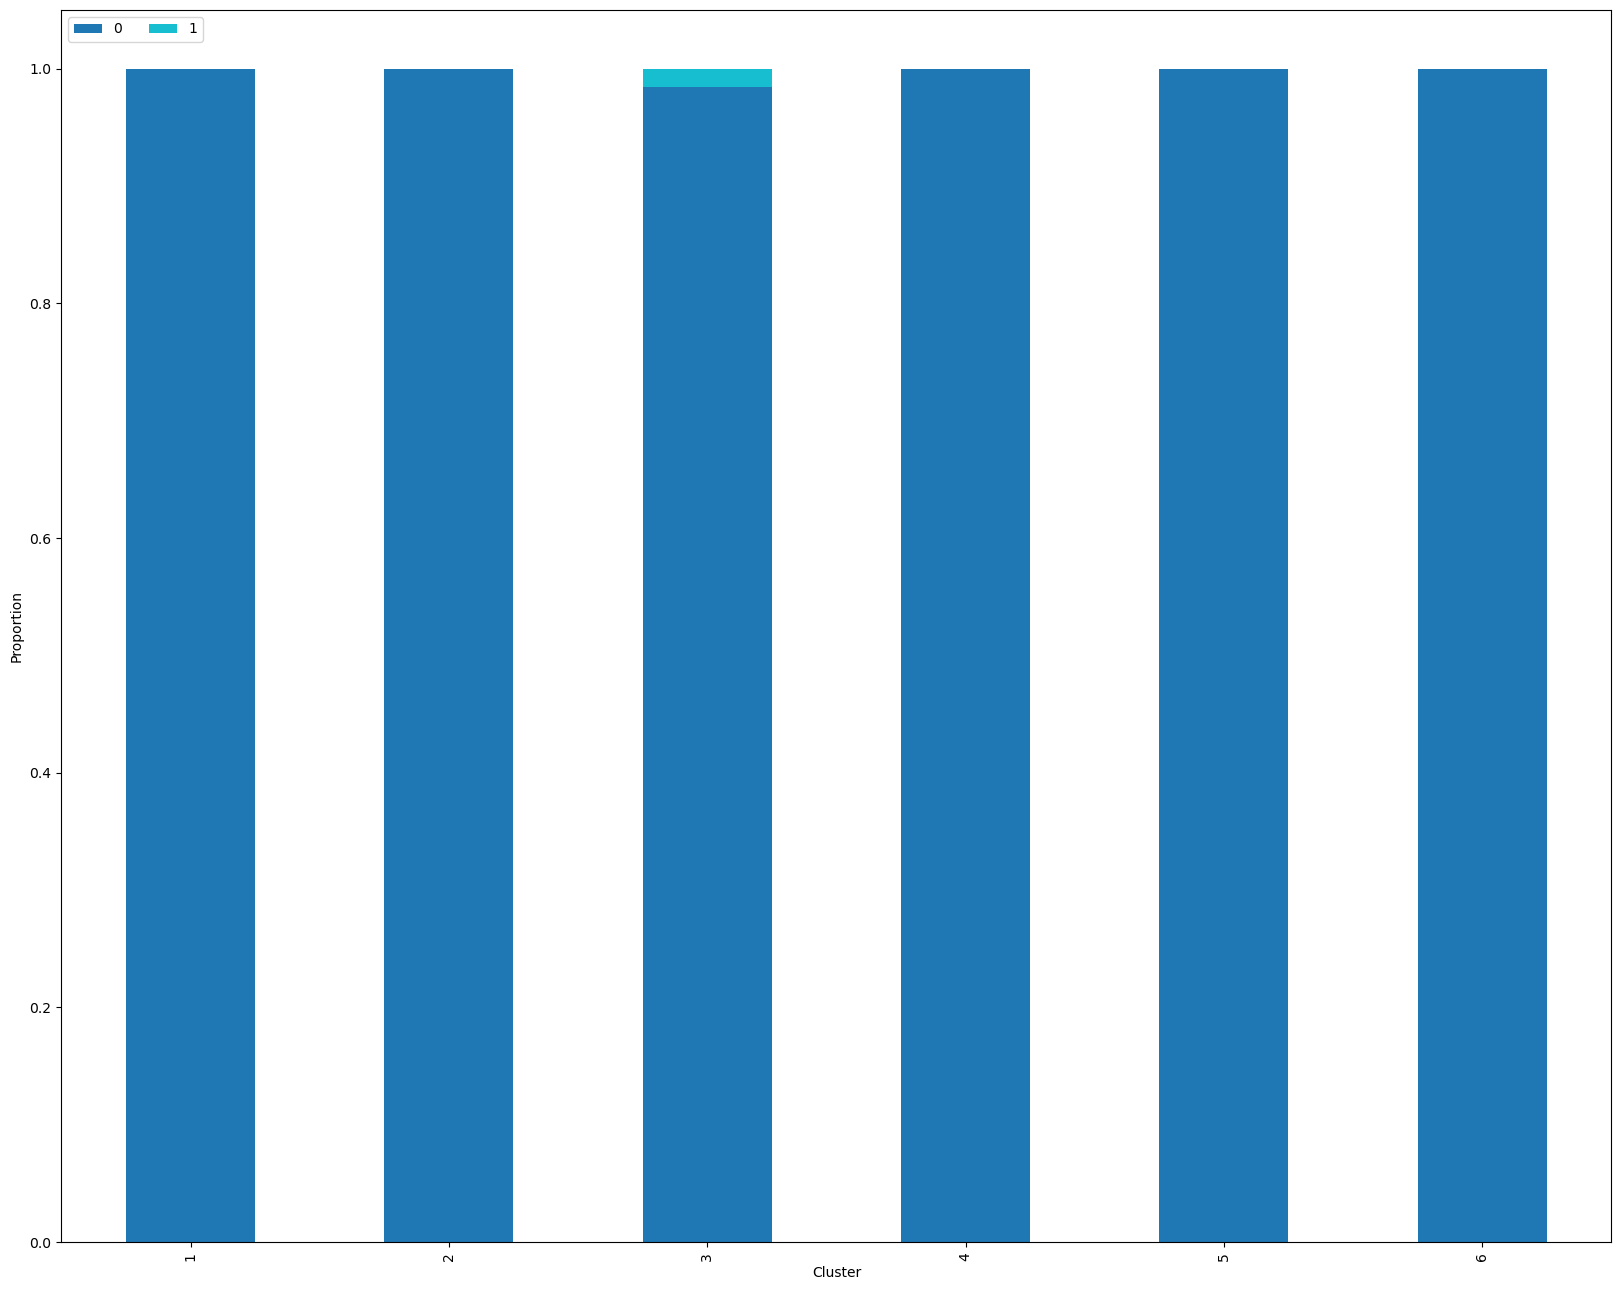

--------------------
Influencia_urbana
--------------------


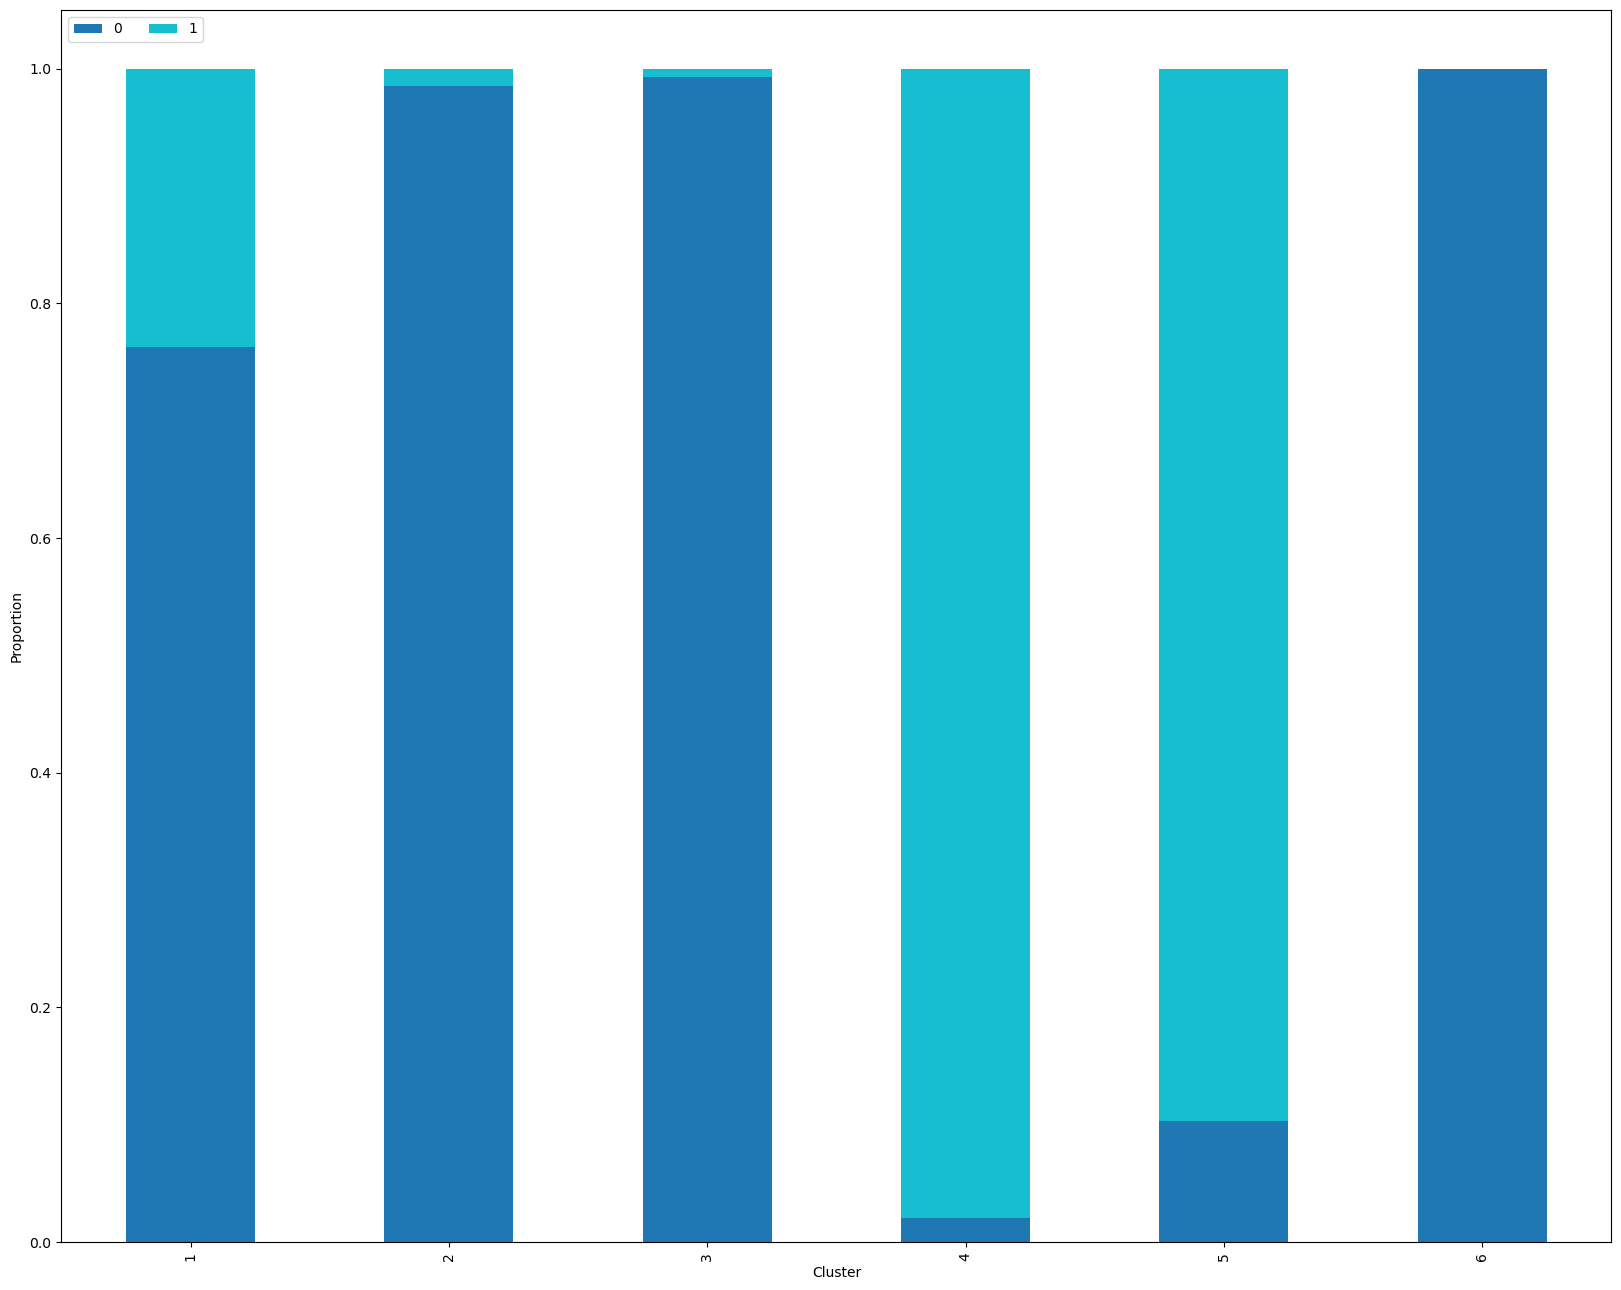

--------------------
legenda_2_Pecuária (pastagens)
--------------------


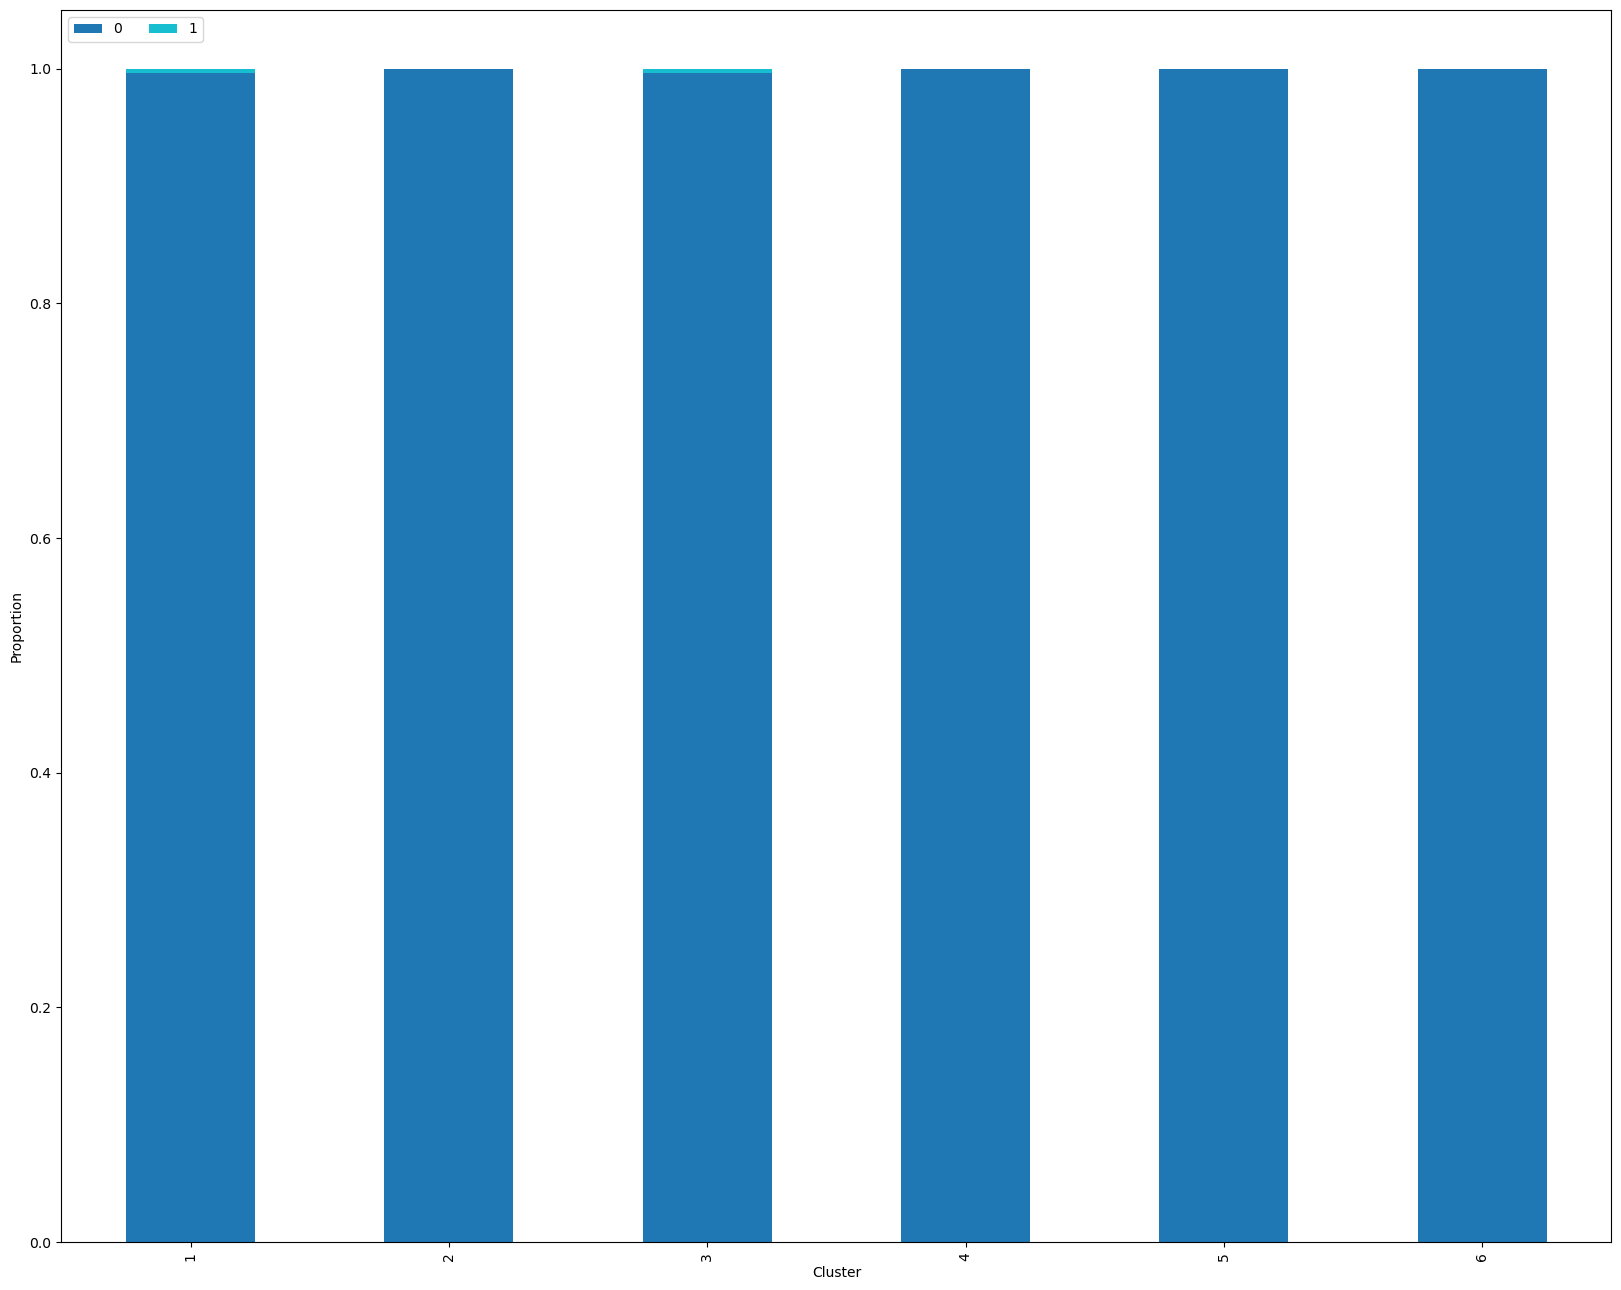

--------------------
Vegetacao_Secundaria
--------------------


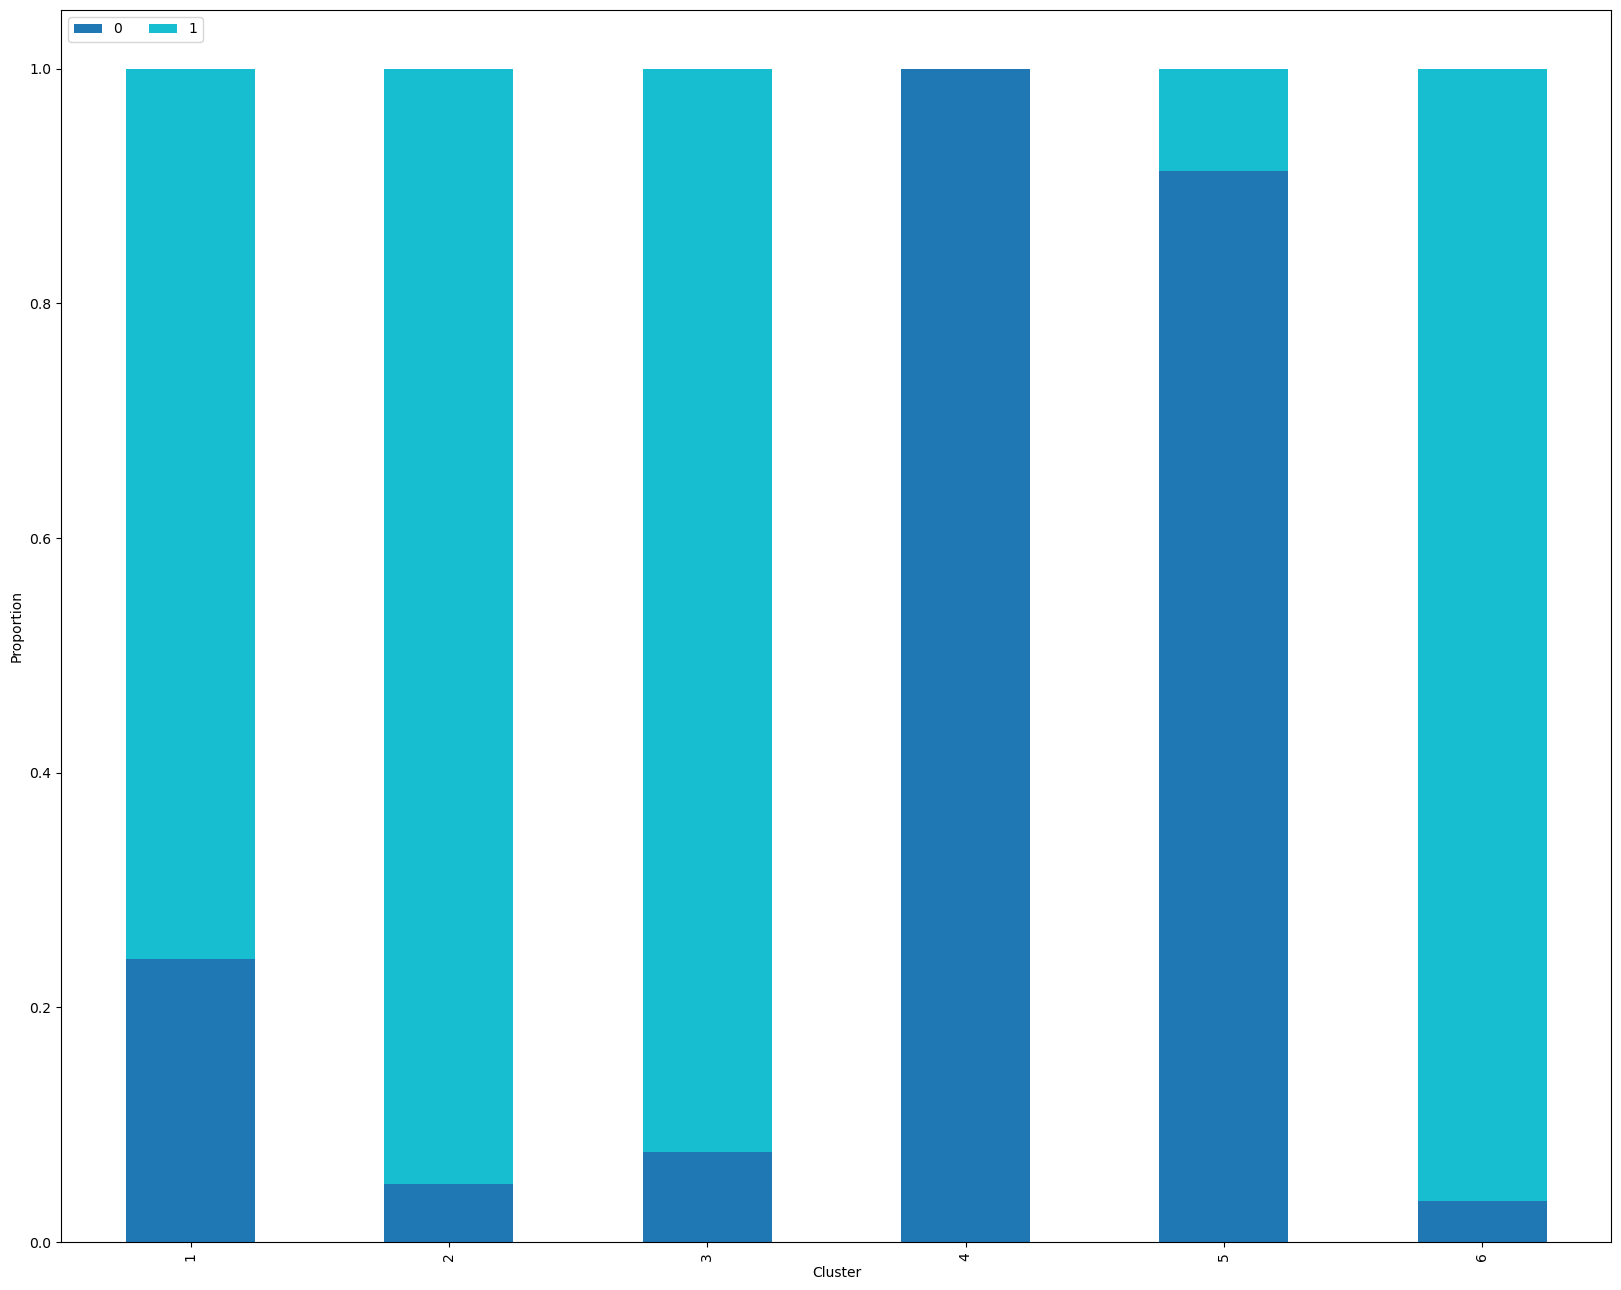

--------------------
Argilossolo
--------------------


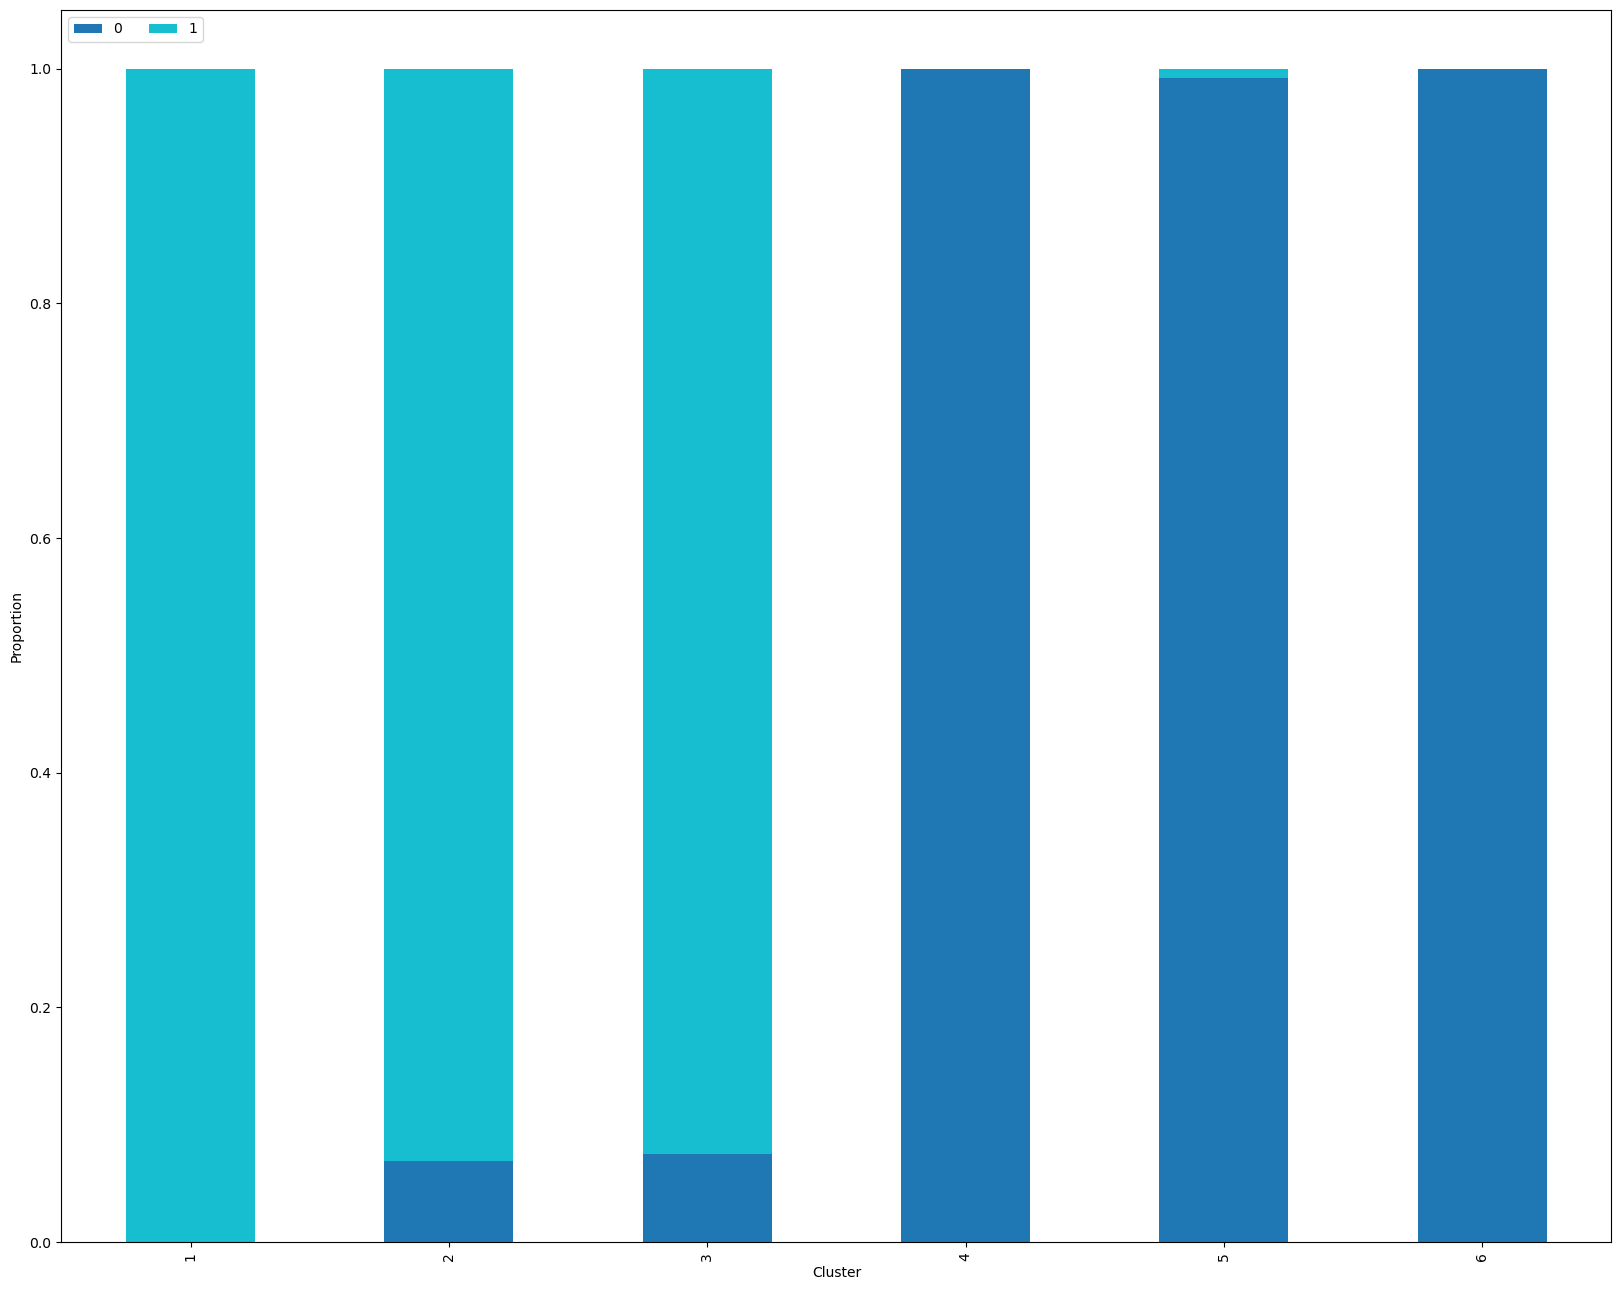

--------------------
Gleissolo
--------------------


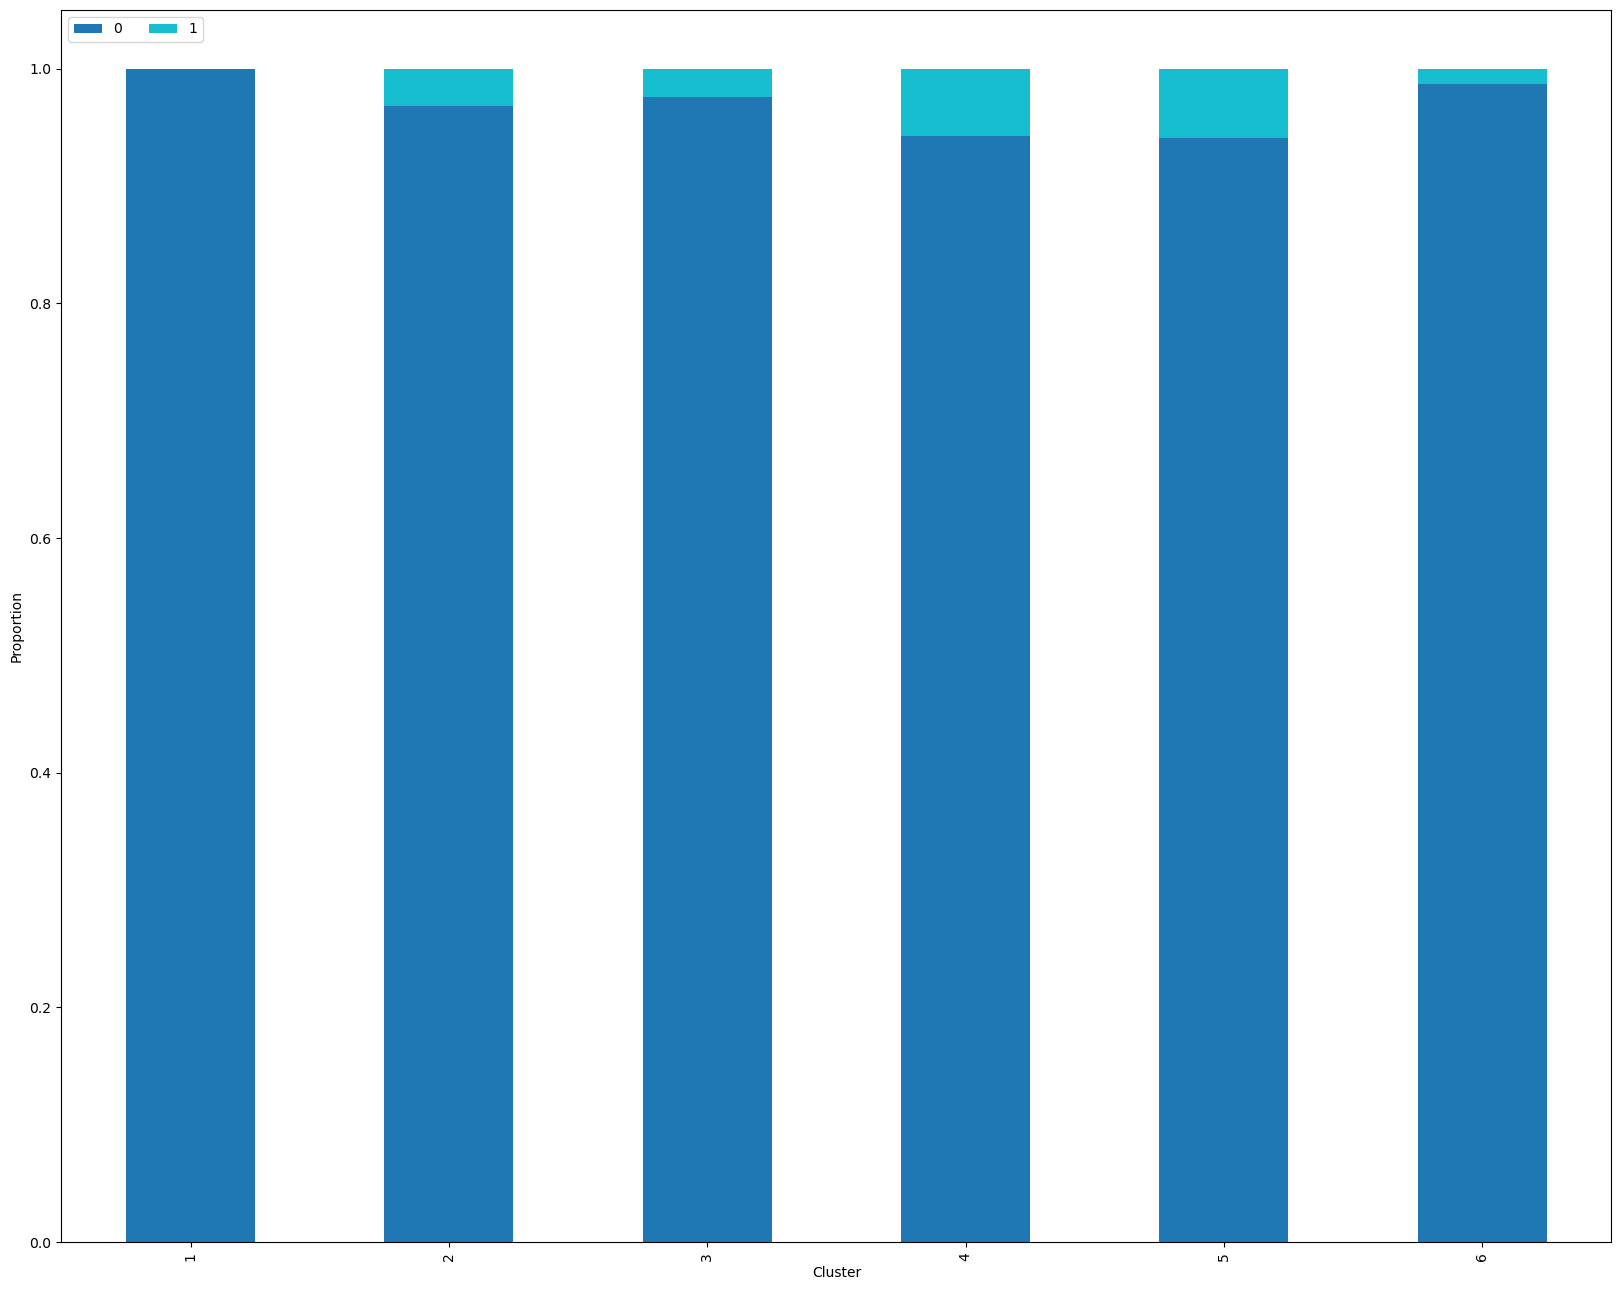

--------------------
Argilossolo_Vermelho_Amarelo
--------------------


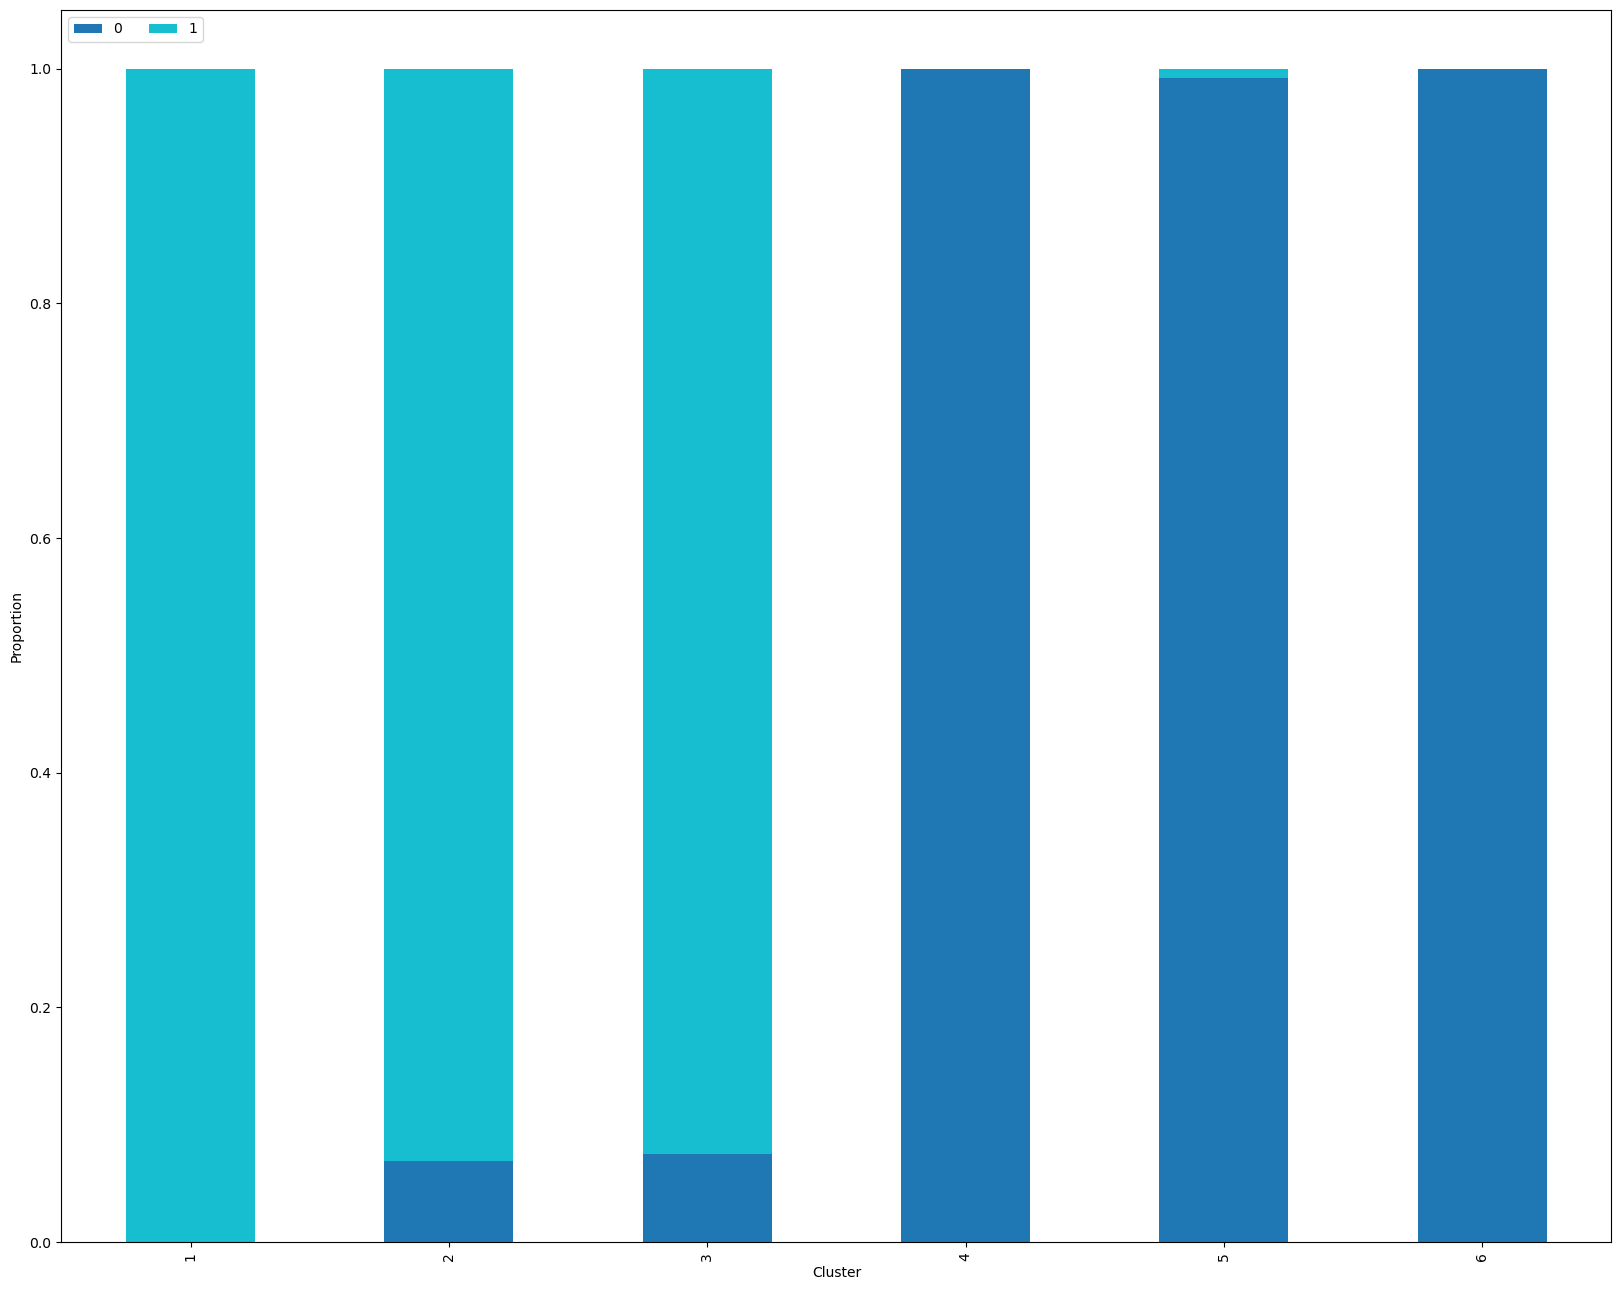

--------------------
Gleissolo_Melanico
--------------------


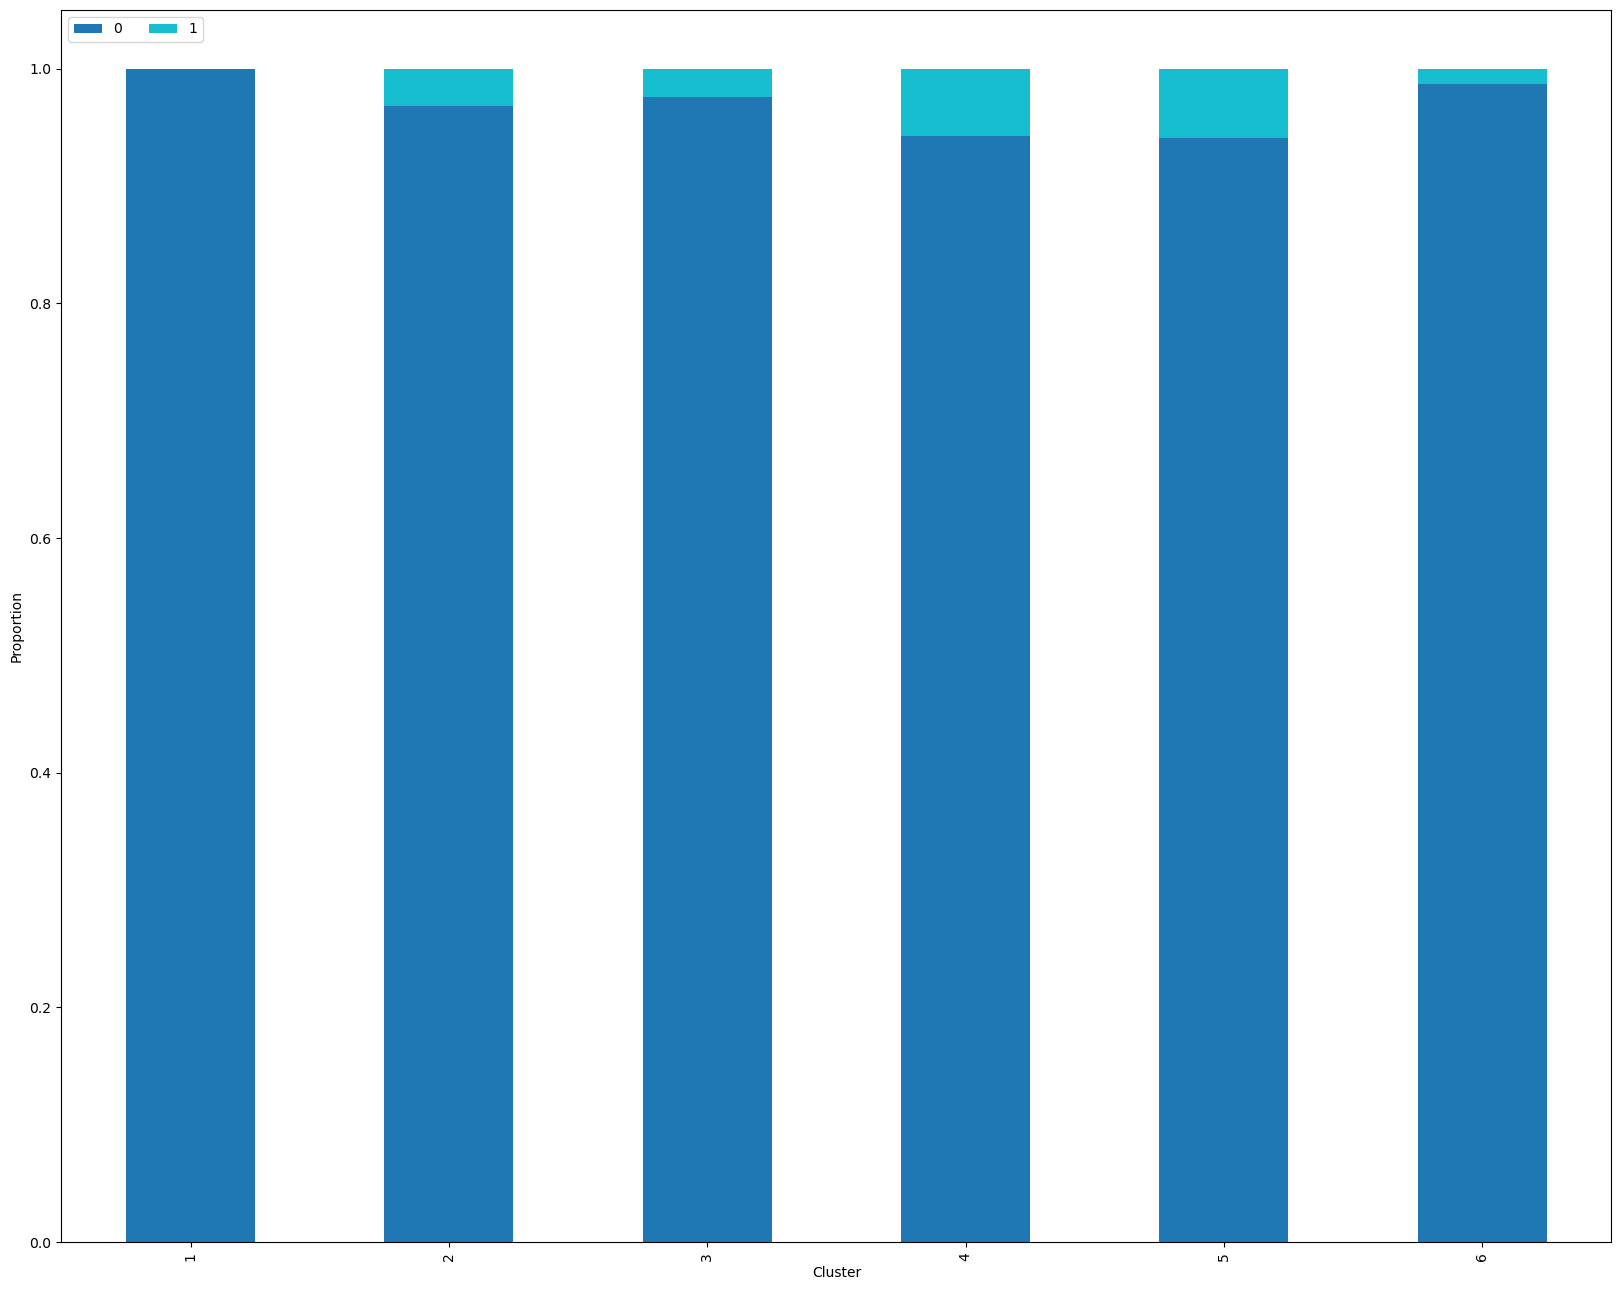

--------------------
Area_Urbana
--------------------


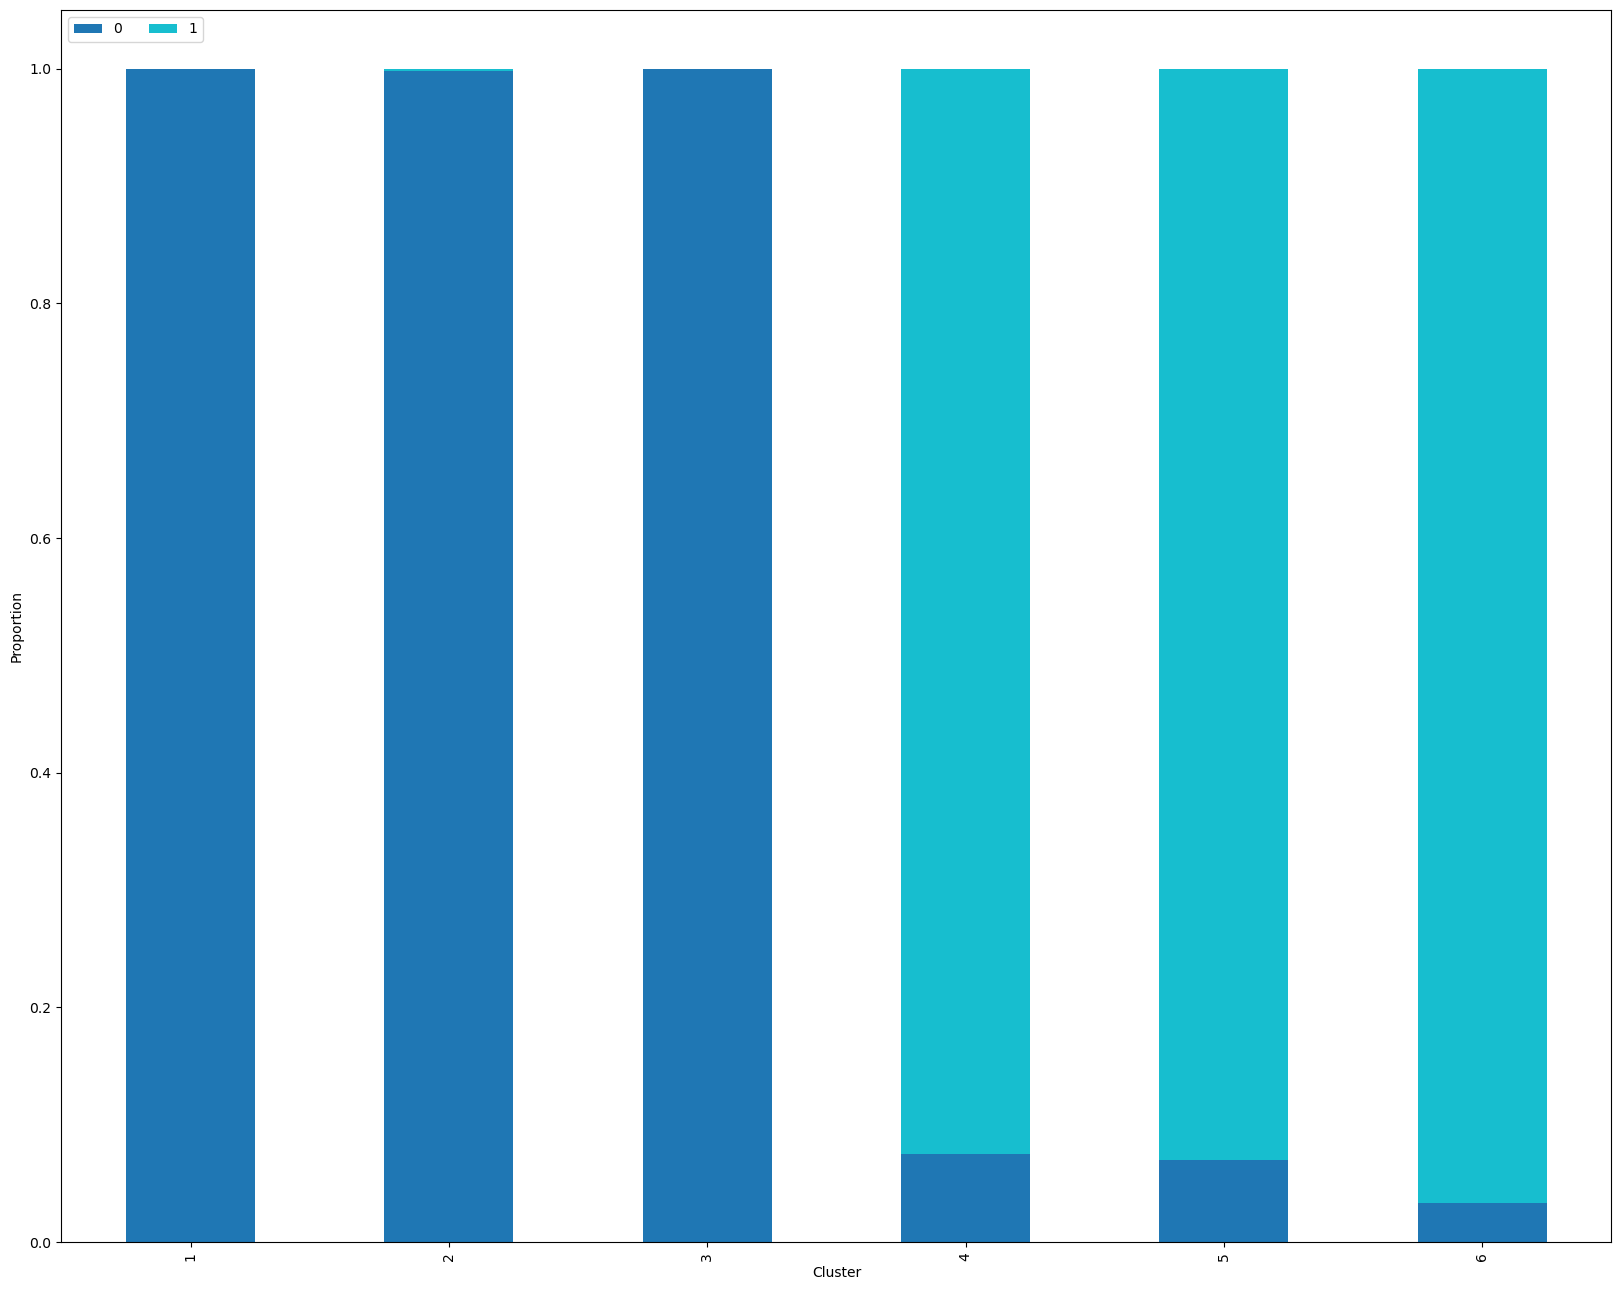

--------------------
Unidades_de_Conservacao_Protecao_N_Integral
--------------------


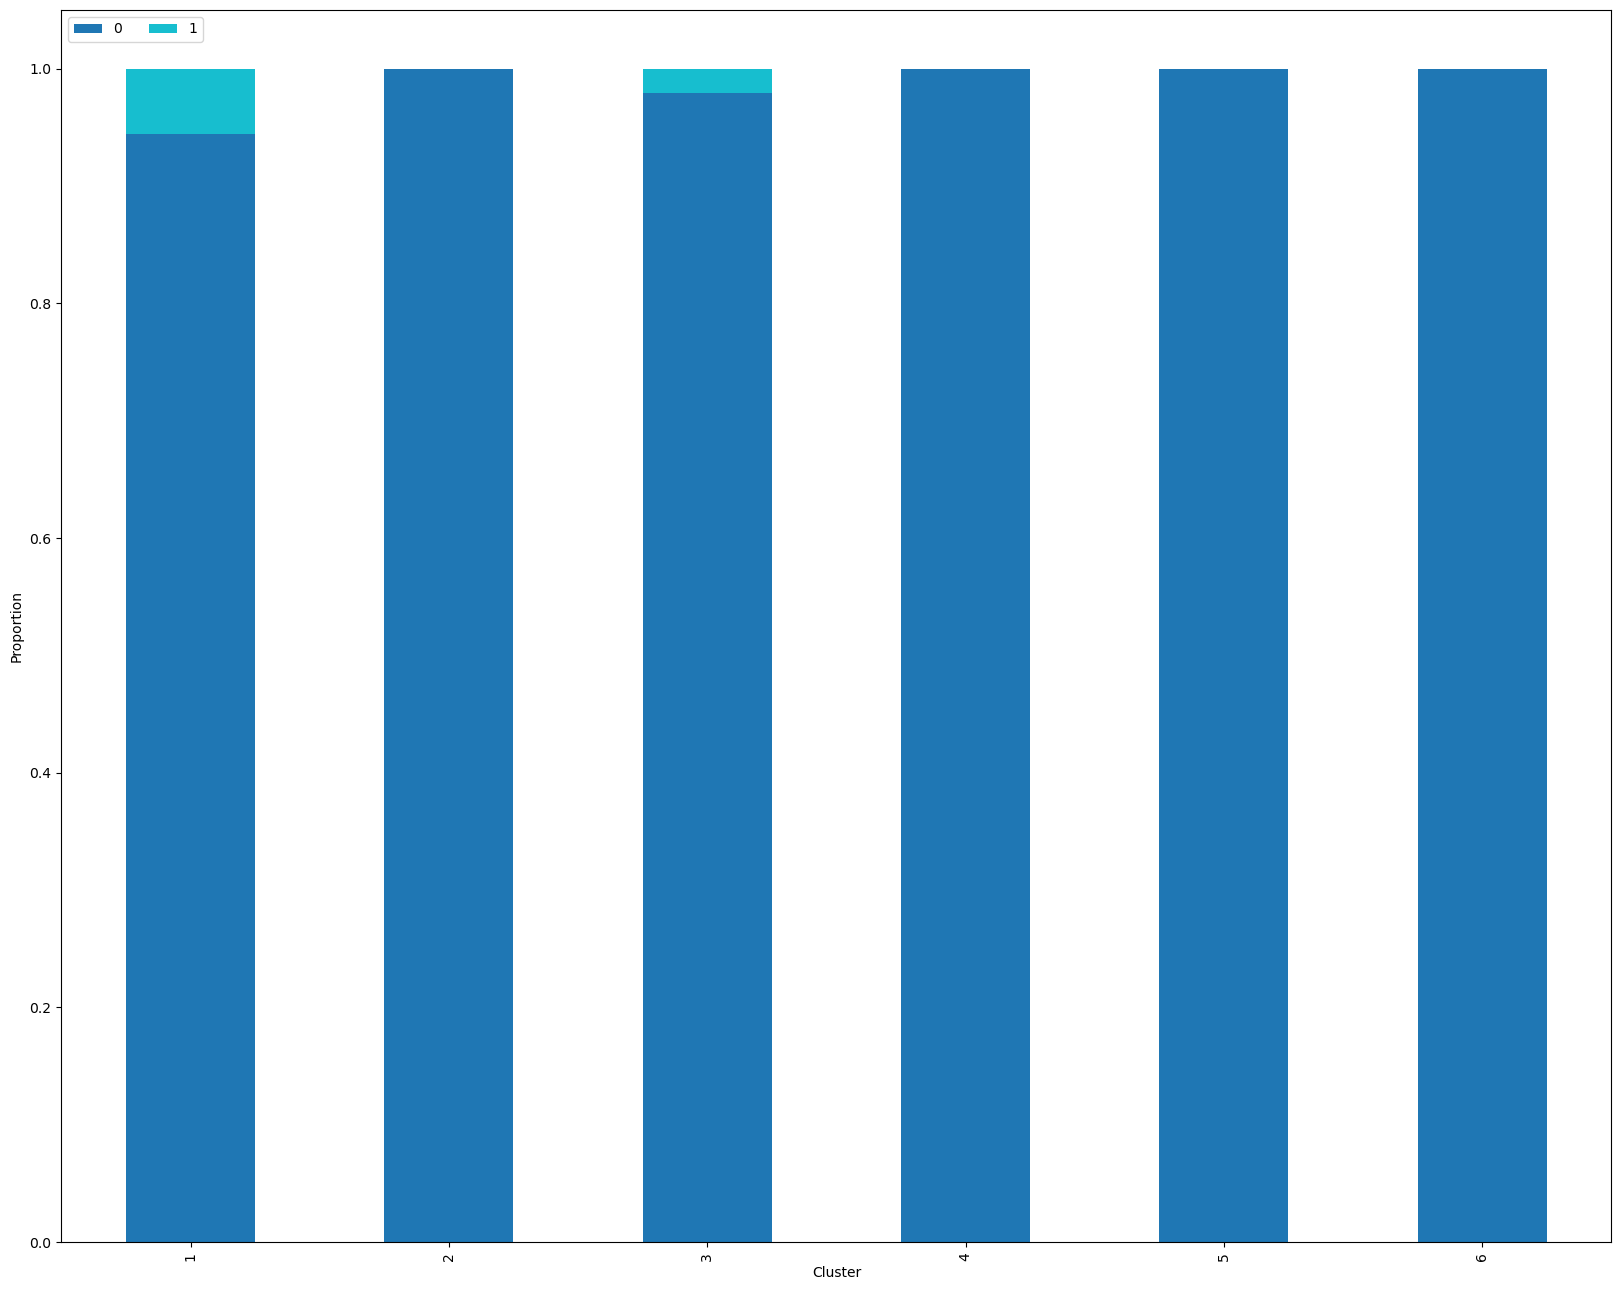

--------------------
Unidades_de_Conservacao_Protecao_Integral
--------------------


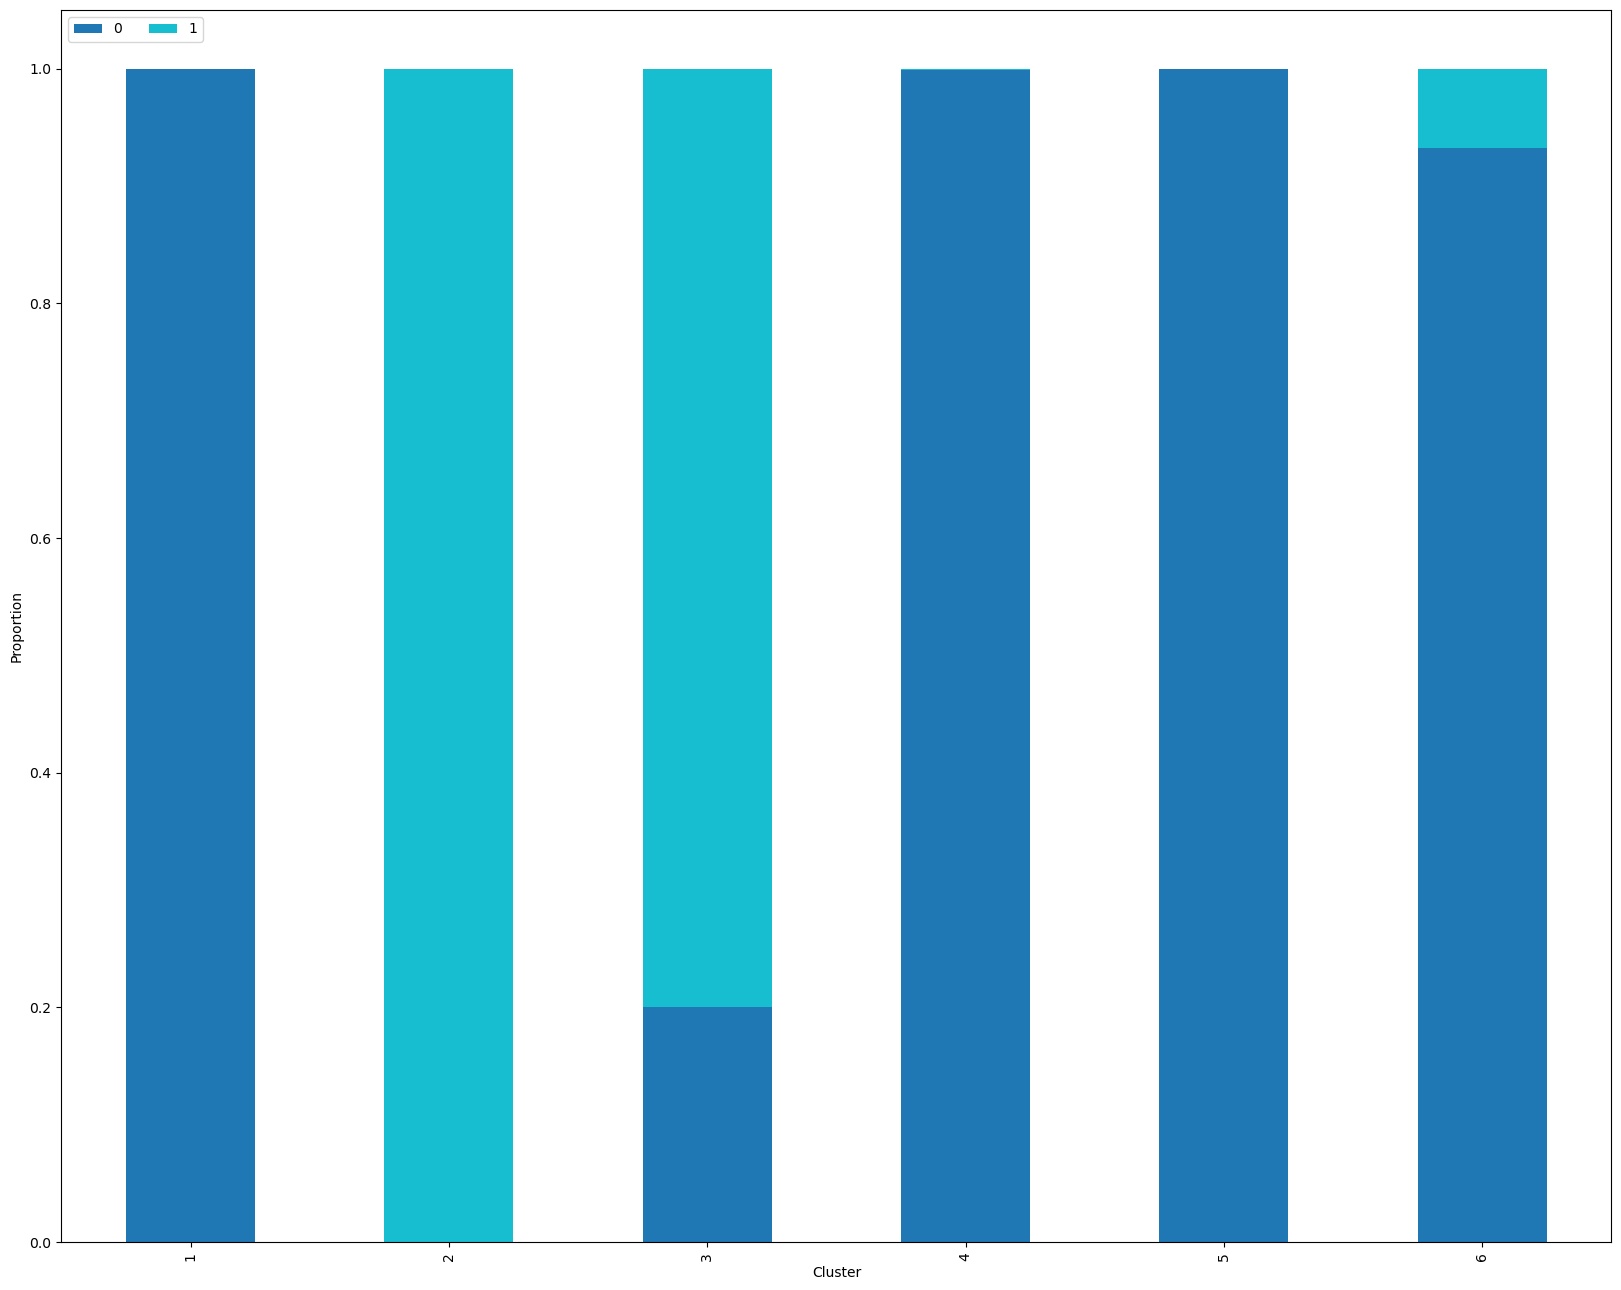

--------------------
Sem_Plano_de_Menejo
--------------------


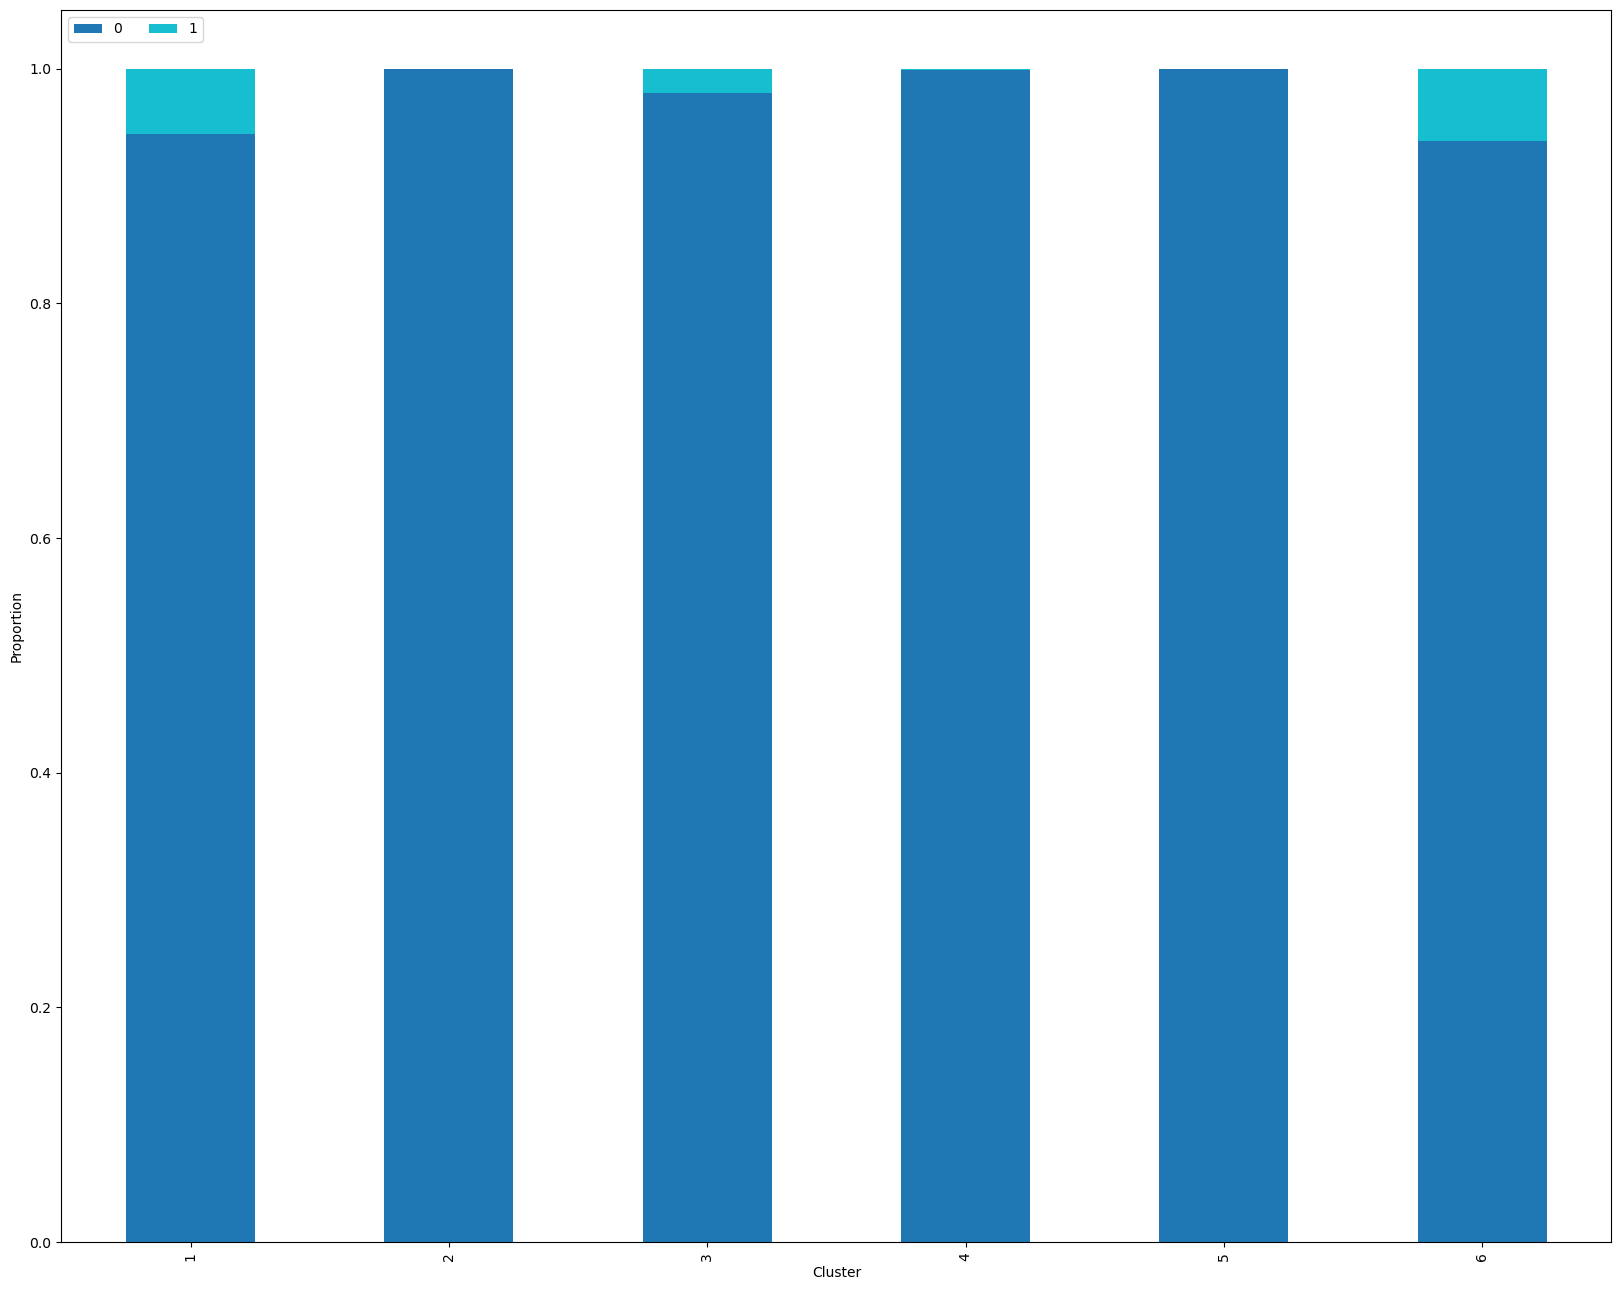

--------------------
Plano_de_Manejo
--------------------


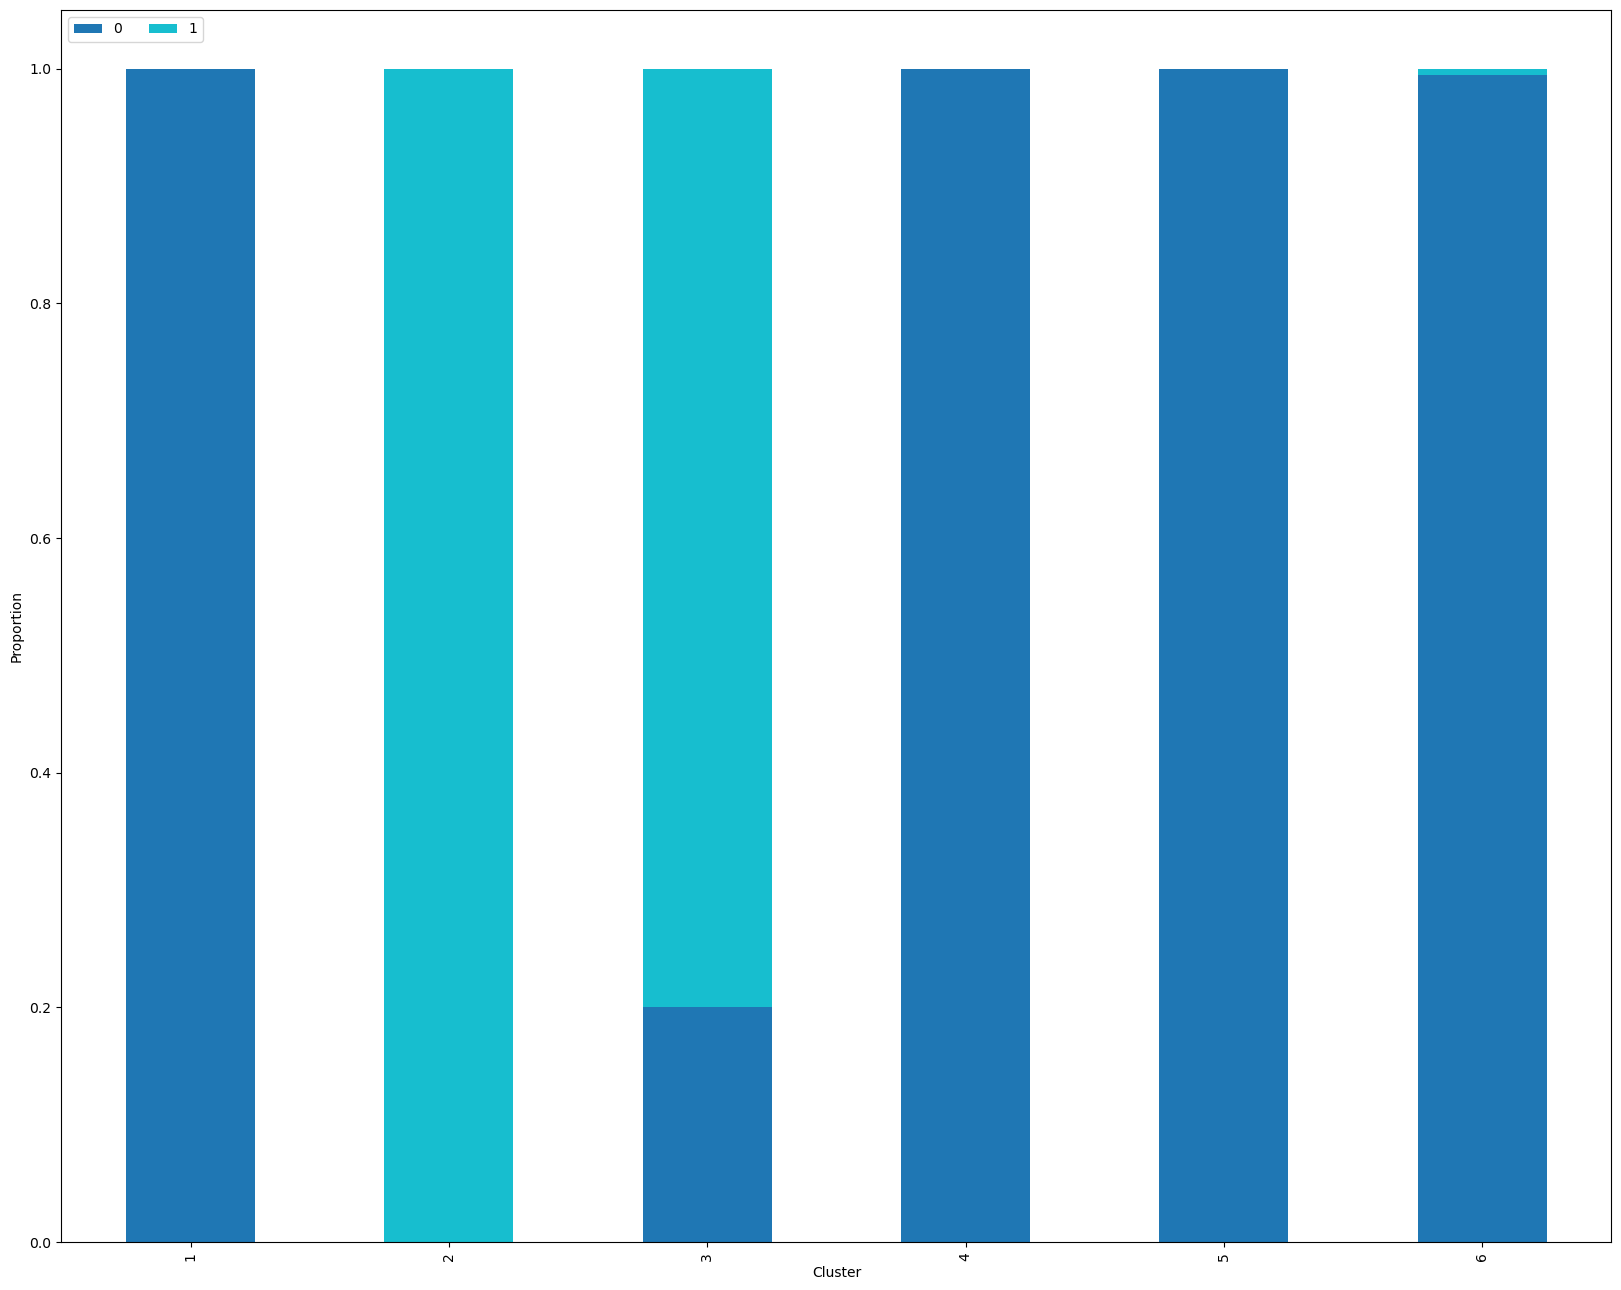

--------------------
flg_comunidades
--------------------


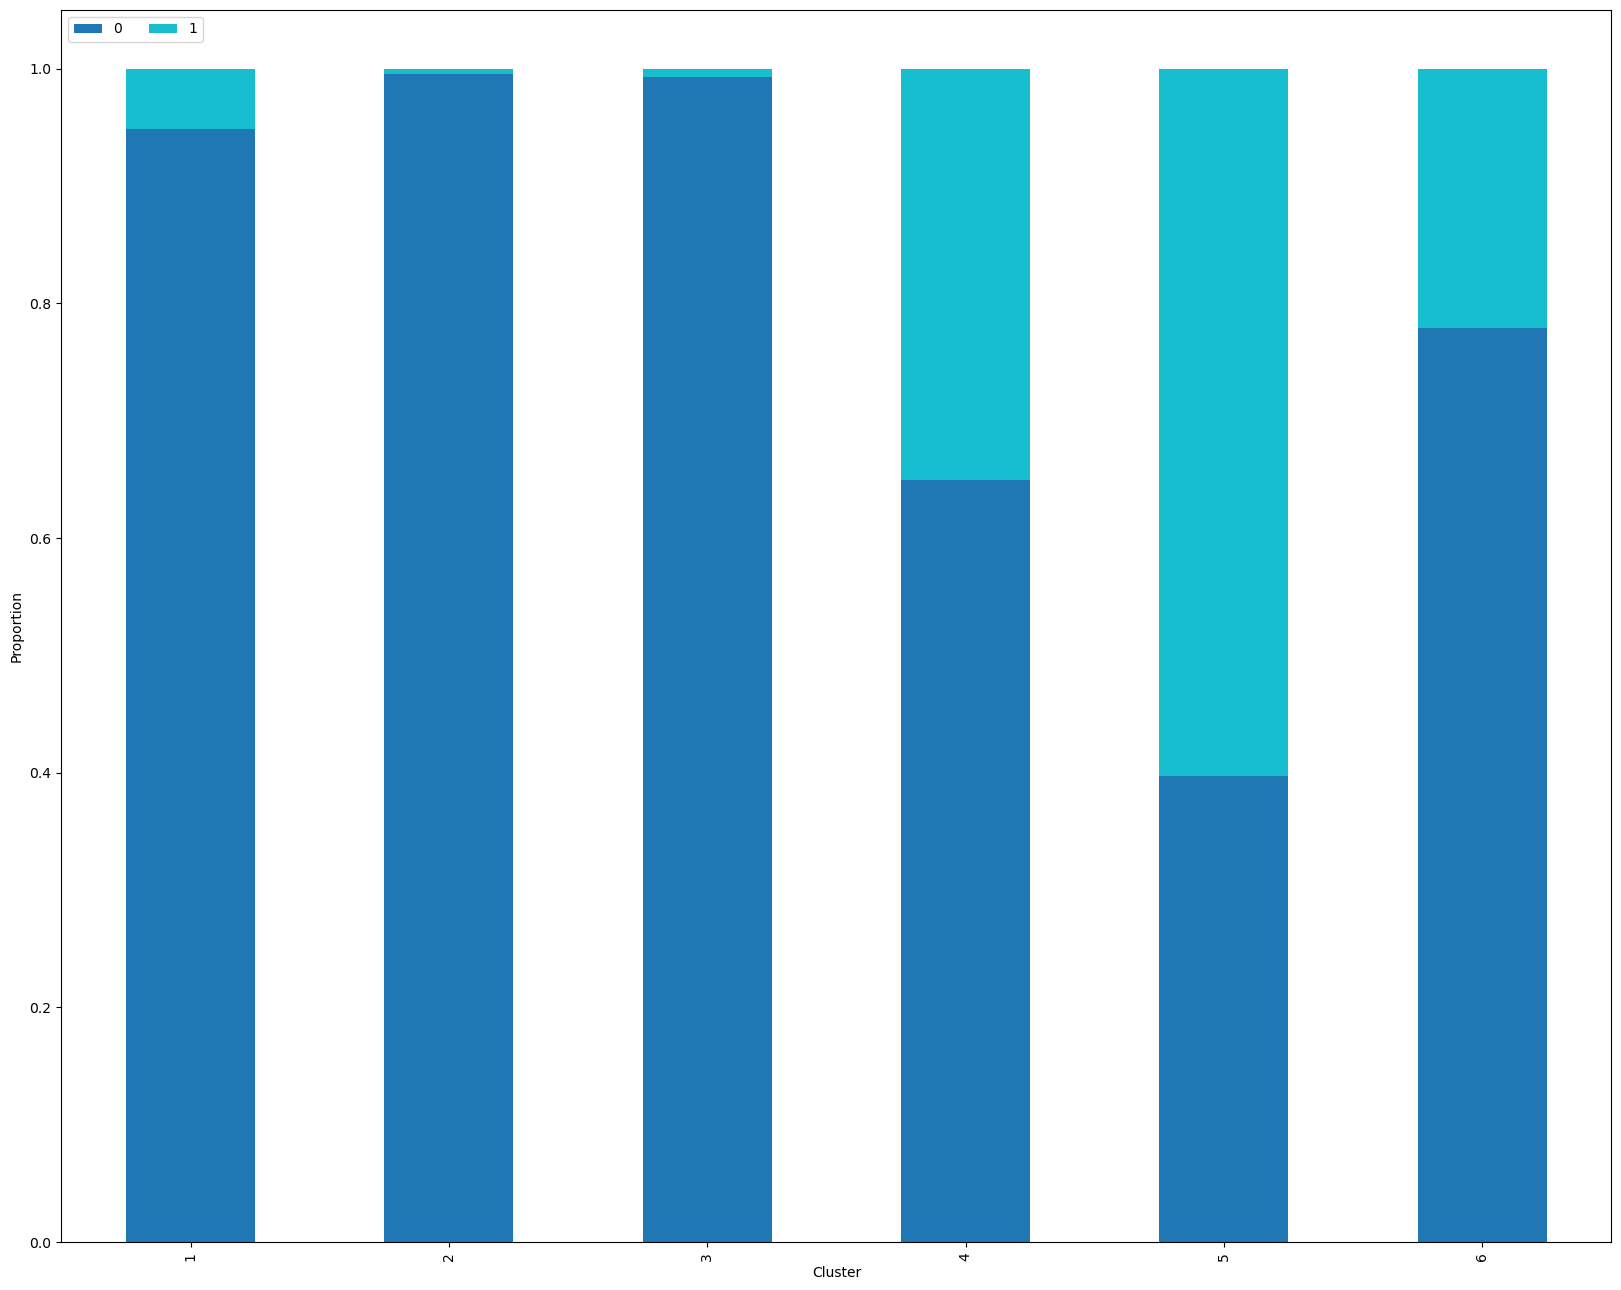

--------------------
flg_agricola
--------------------


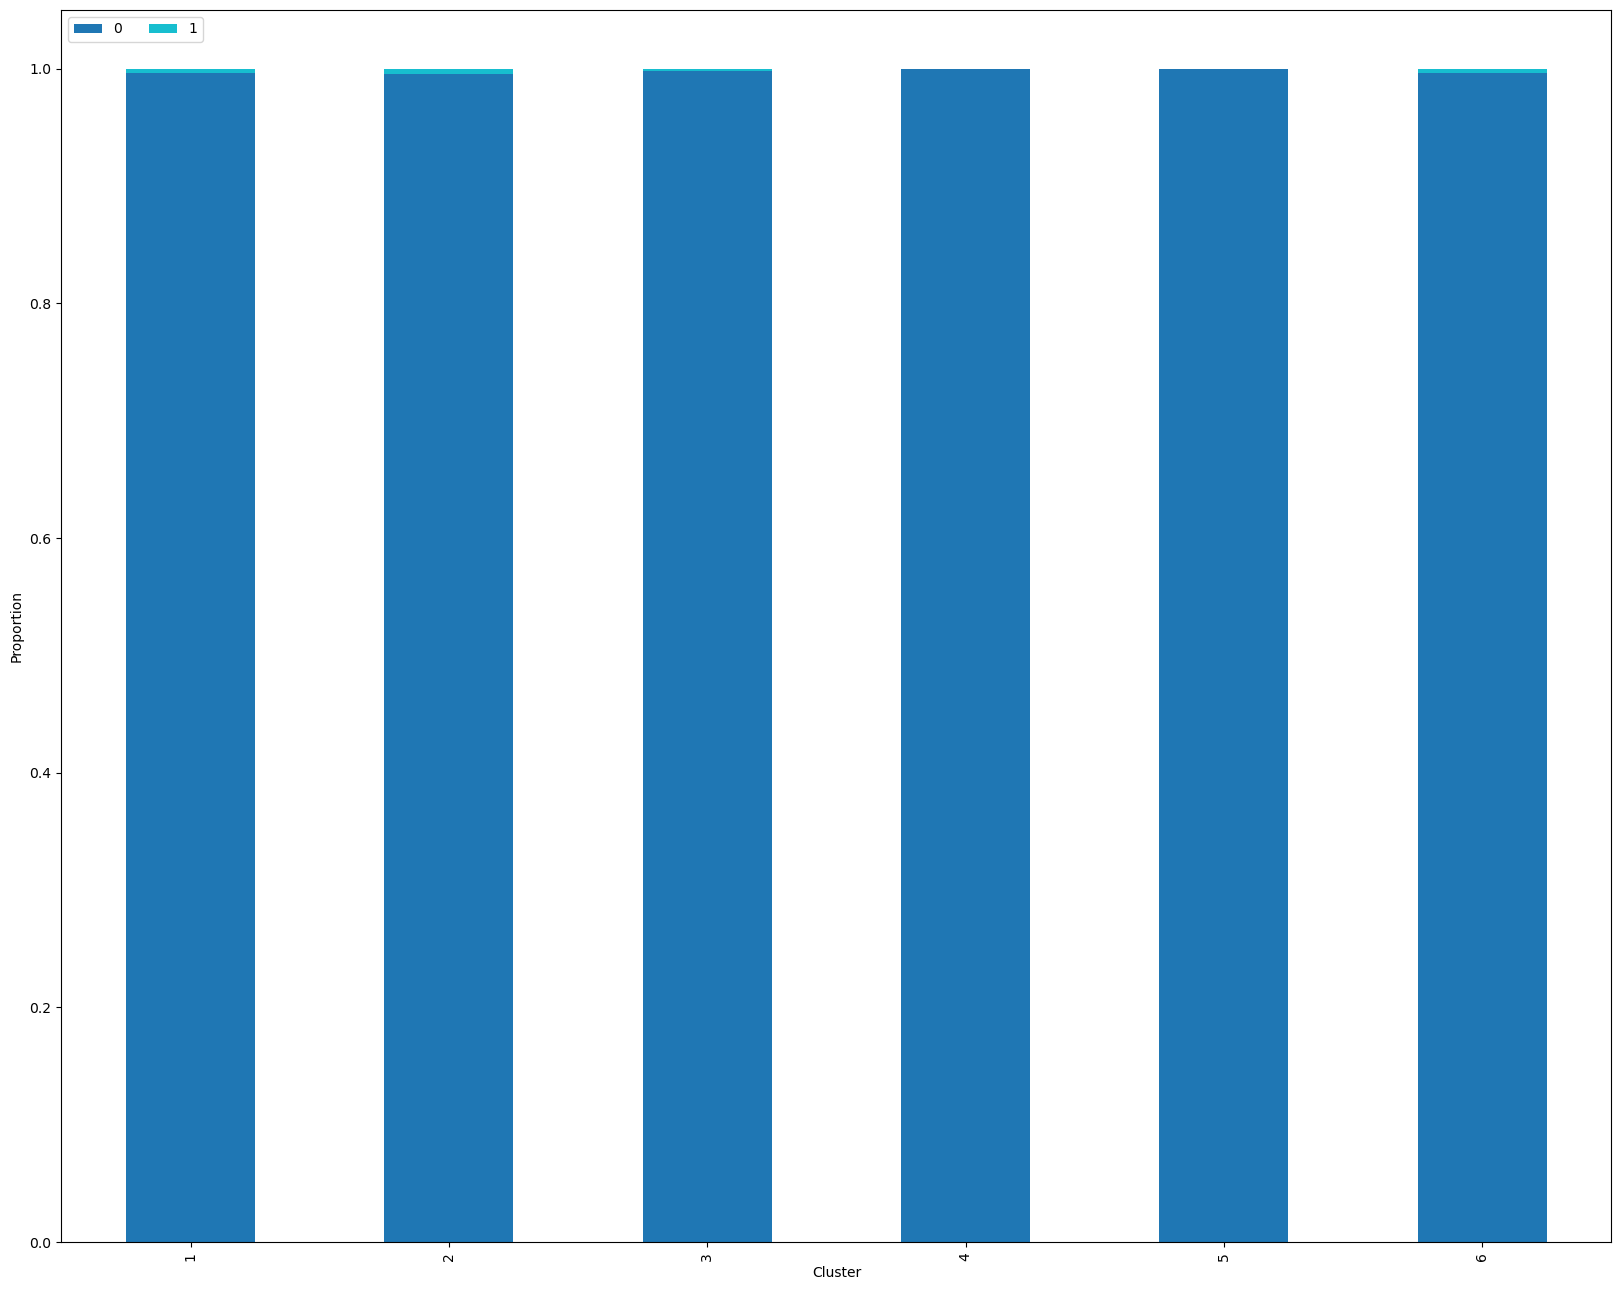

--------------------
flg_exploracao_mineral
--------------------


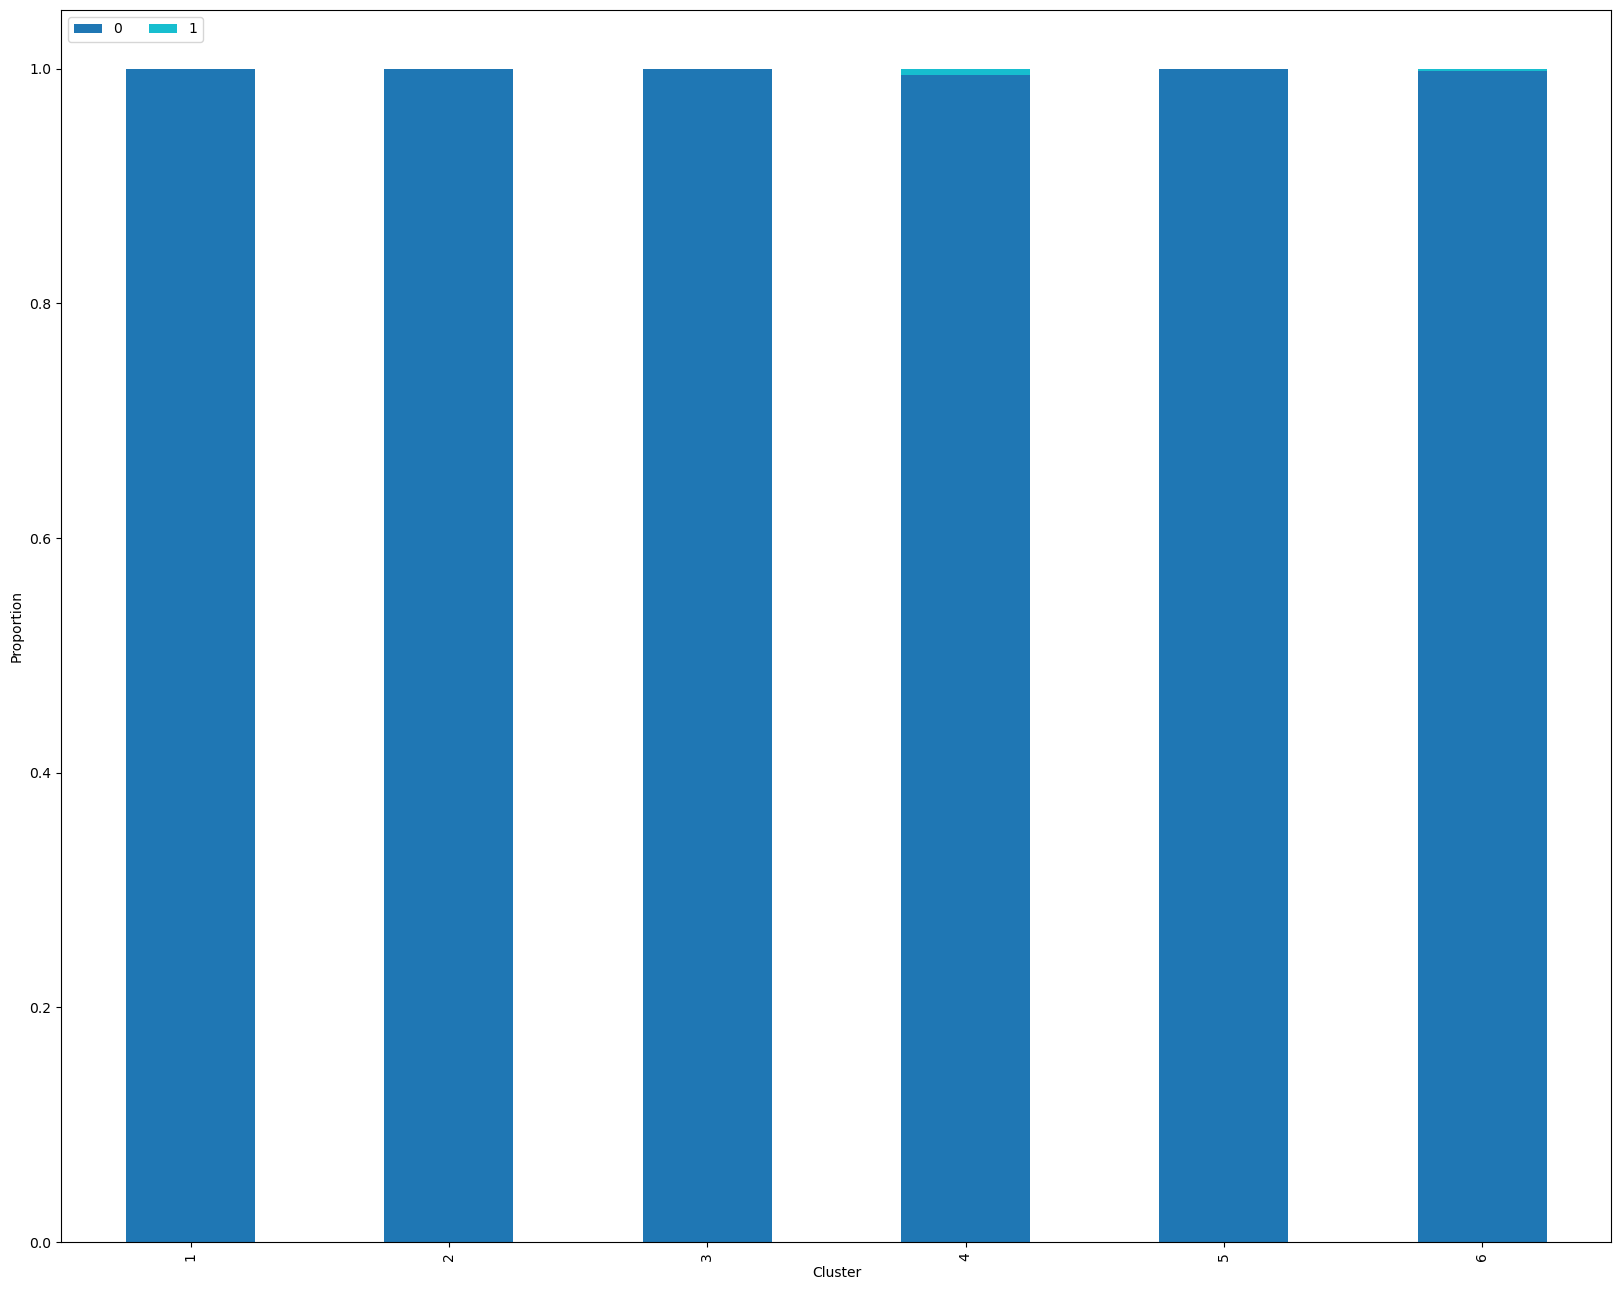

--------------------
flg_corpo_hidrico
--------------------


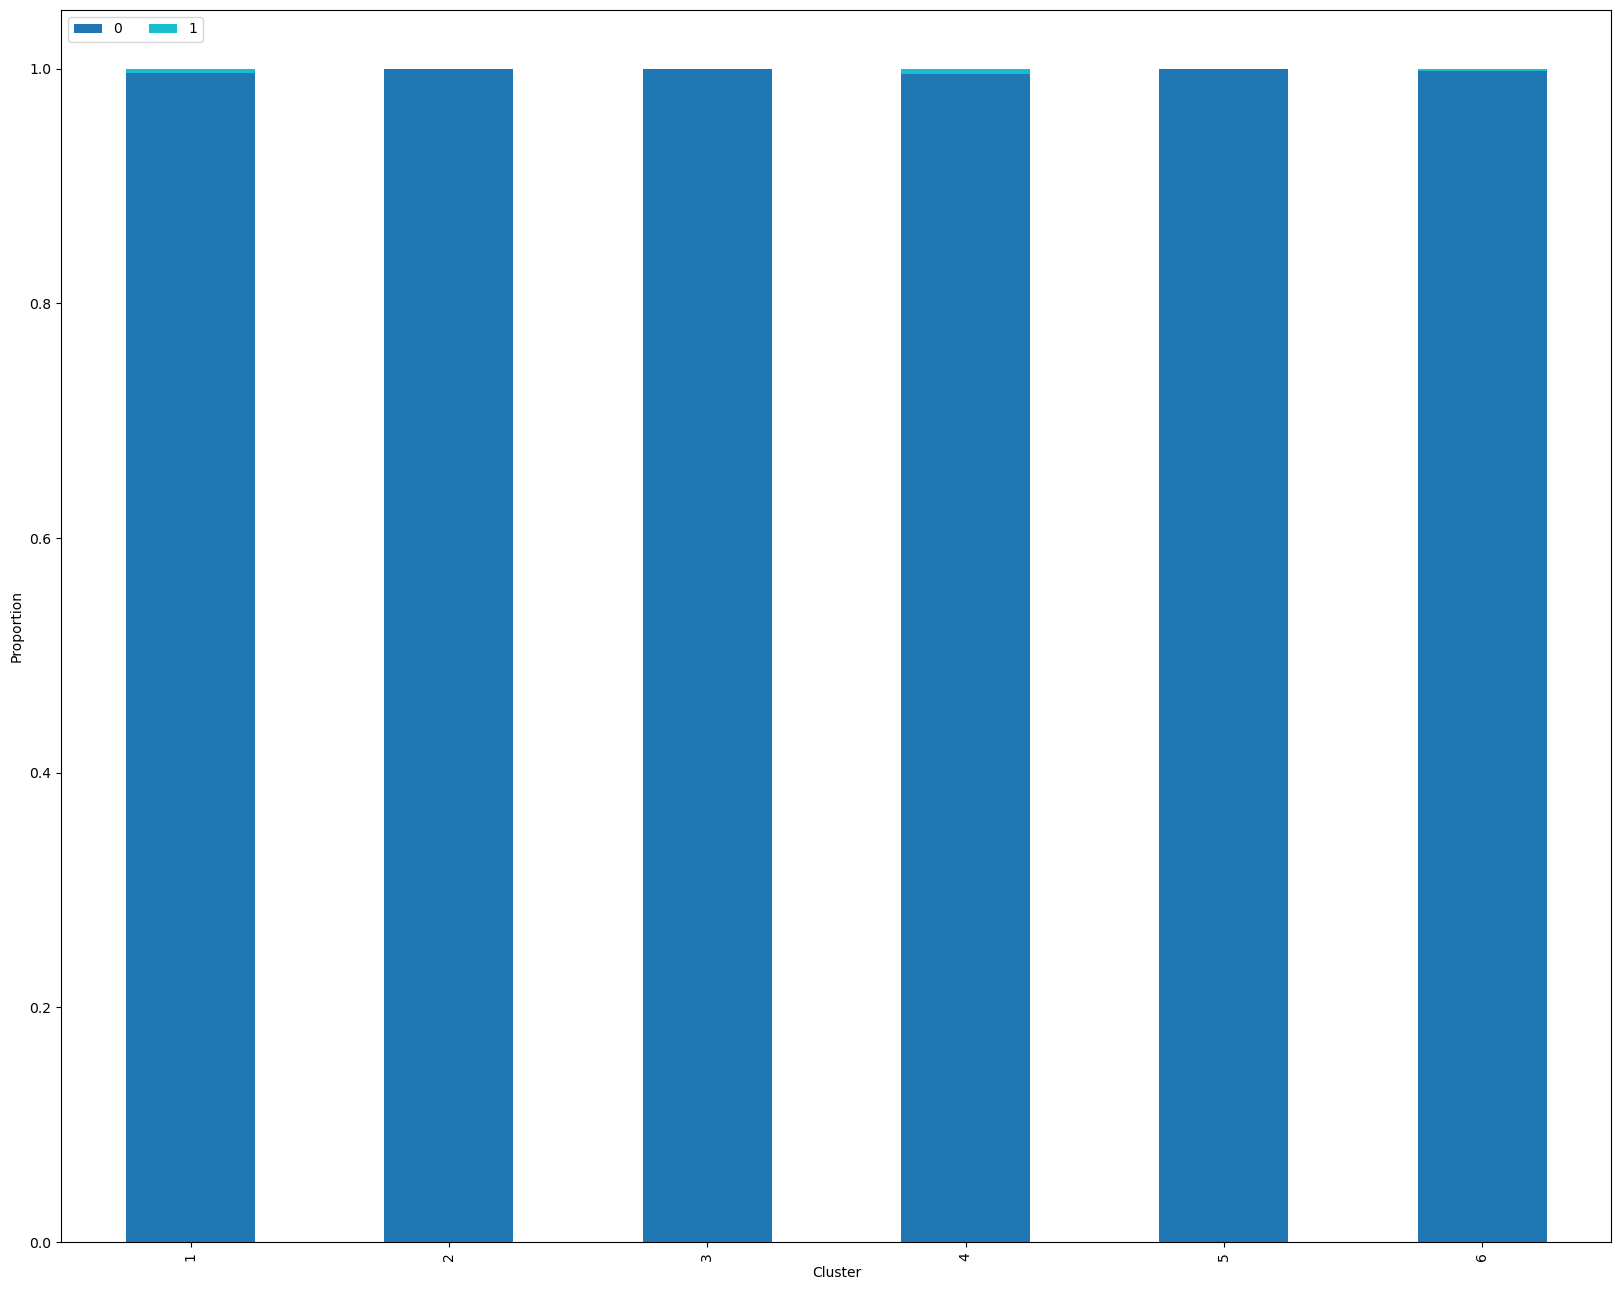

--------------------
flg_rocha
--------------------


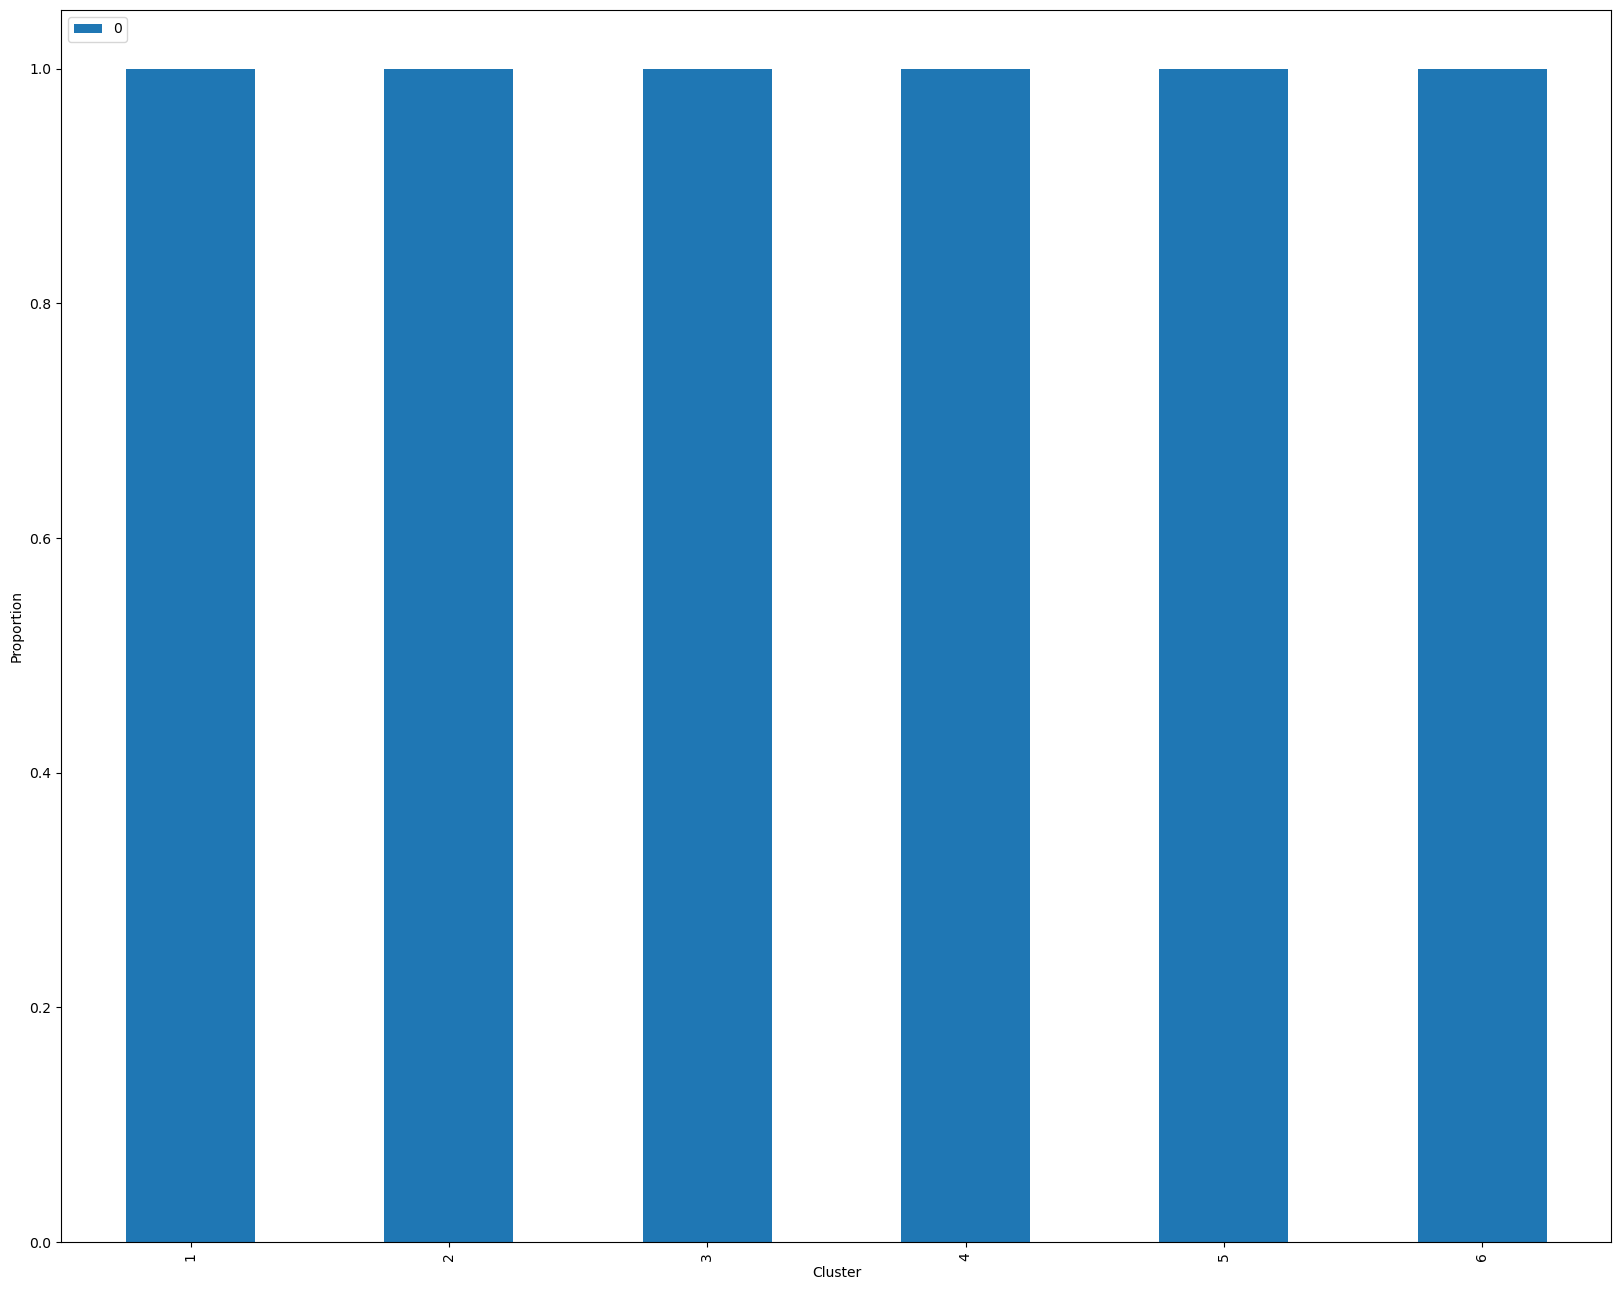

--------------------
flg_cobertura_vegetal
--------------------


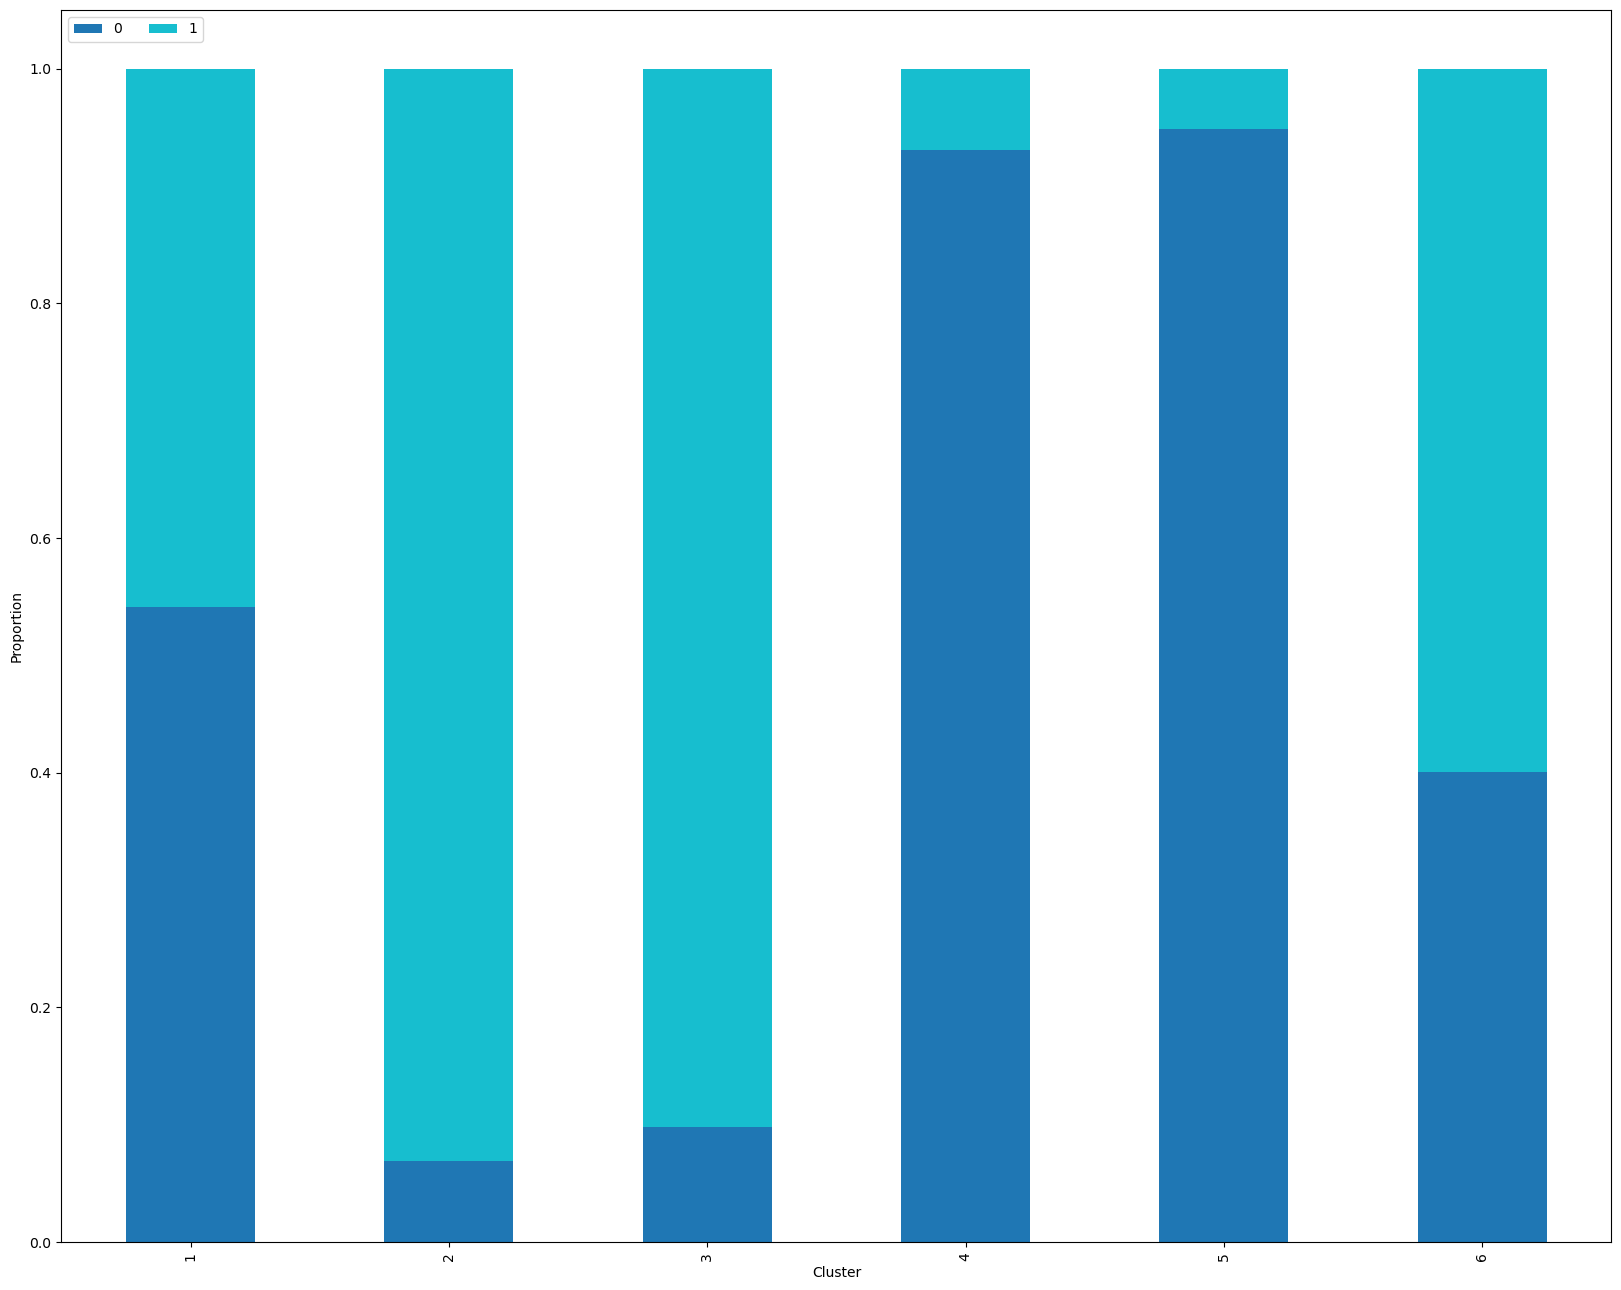

--------------------
flg_afloramento_rochoso
--------------------


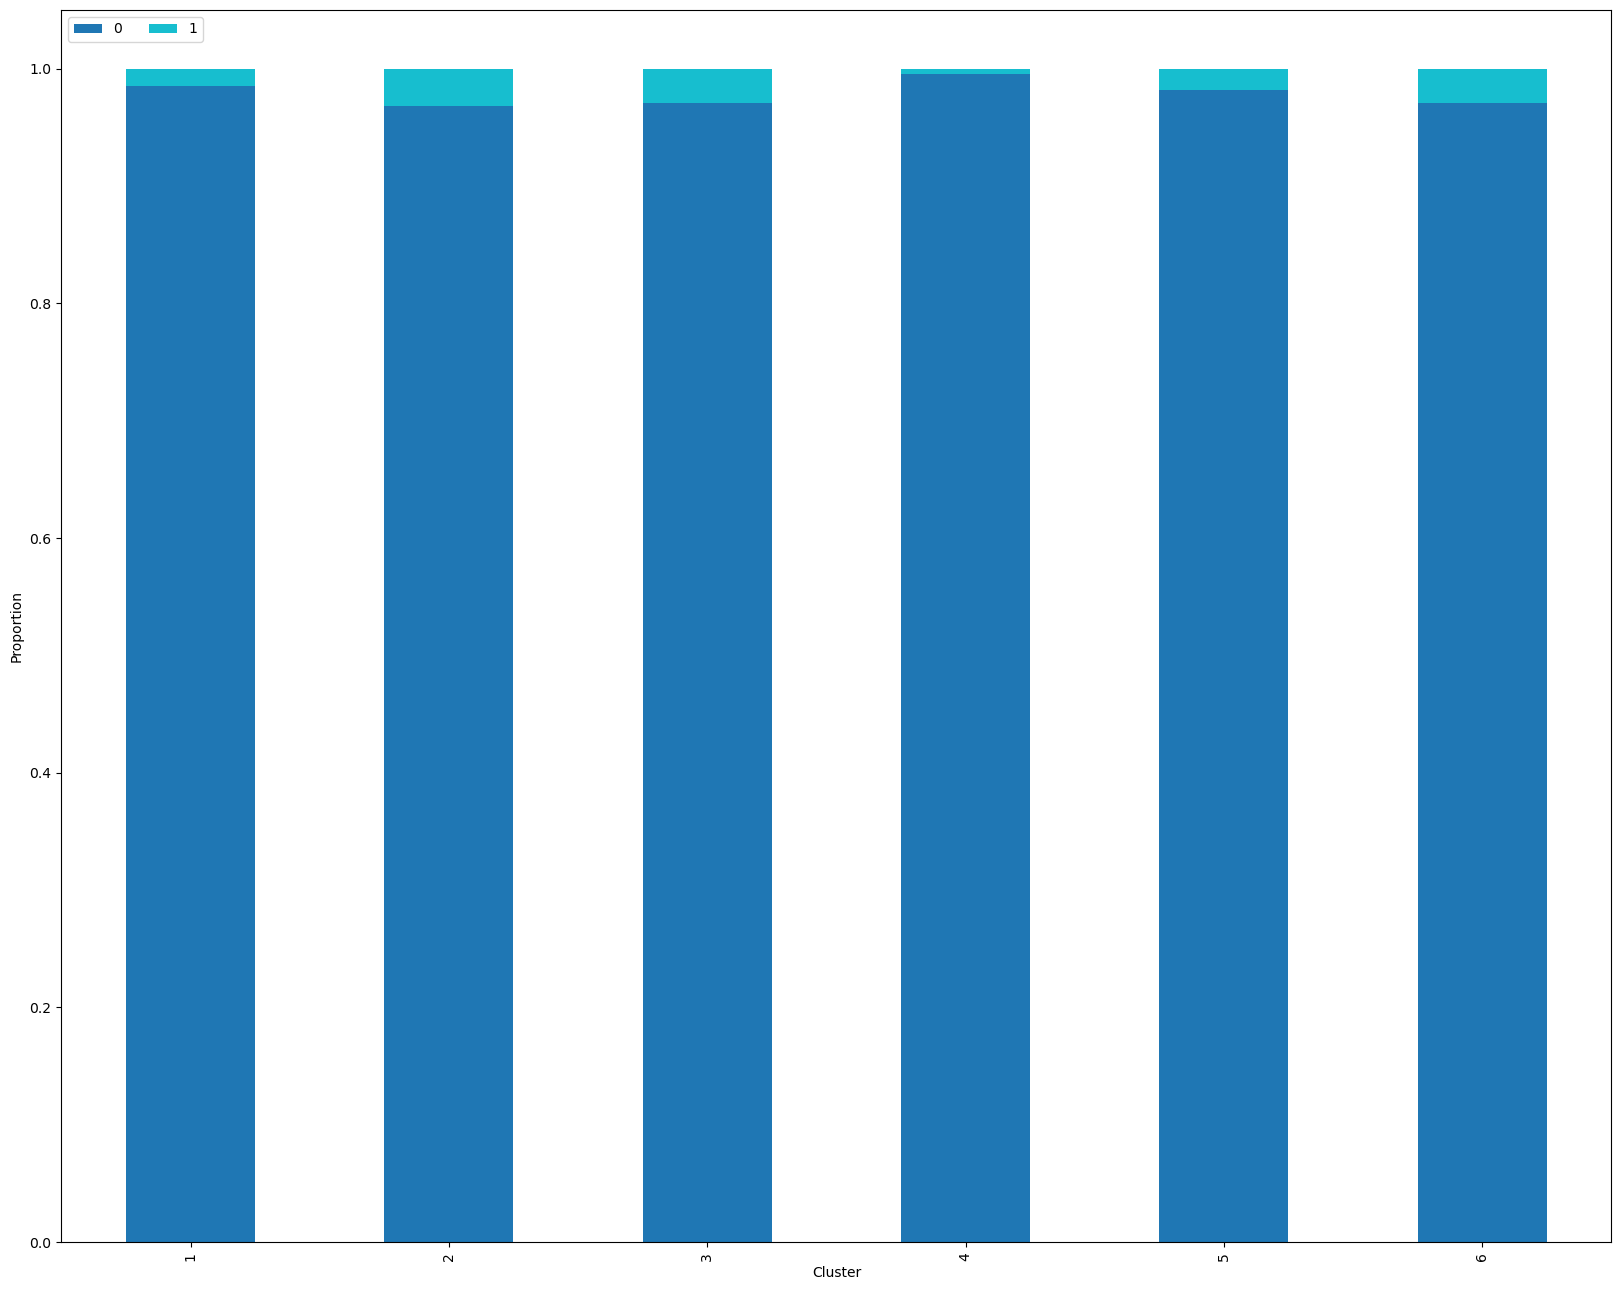

--------------------
flg_favela
--------------------


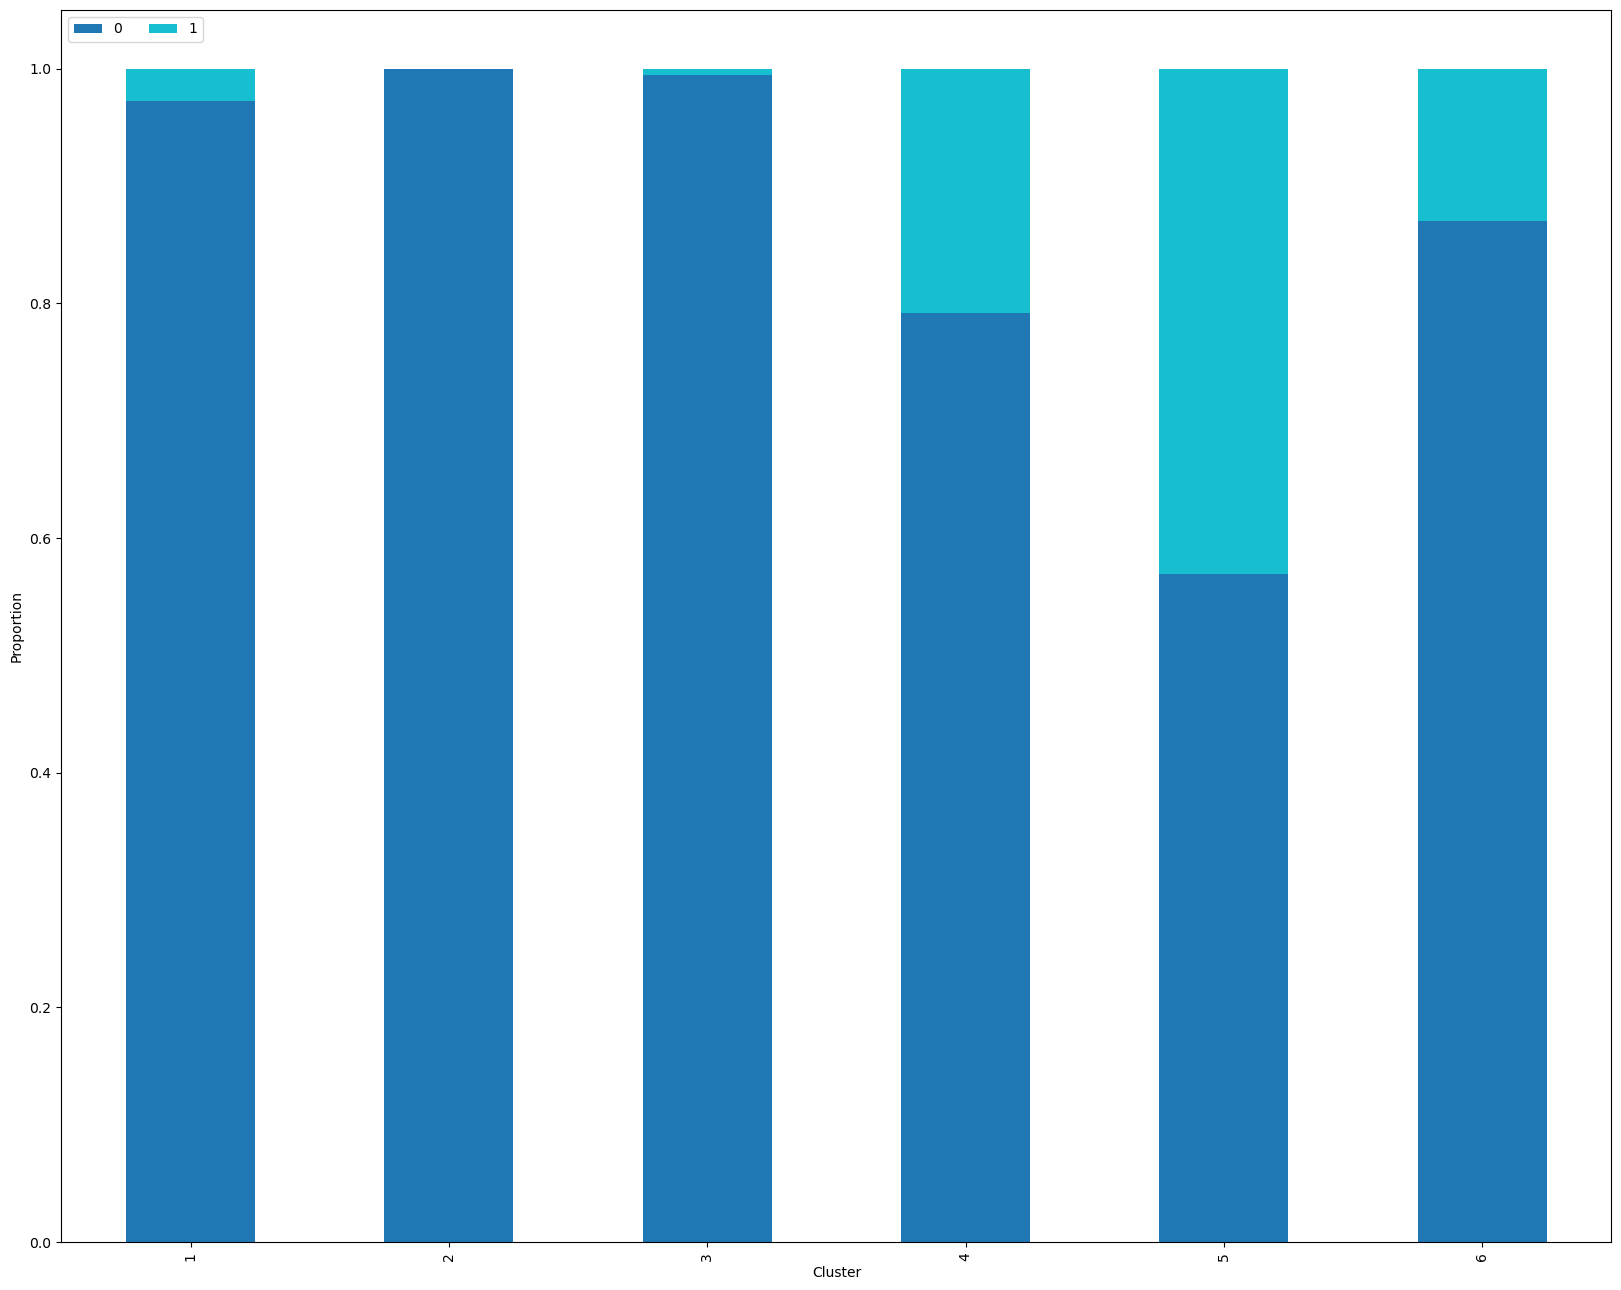

--------------------
flg_ocupacao_desordenada
--------------------


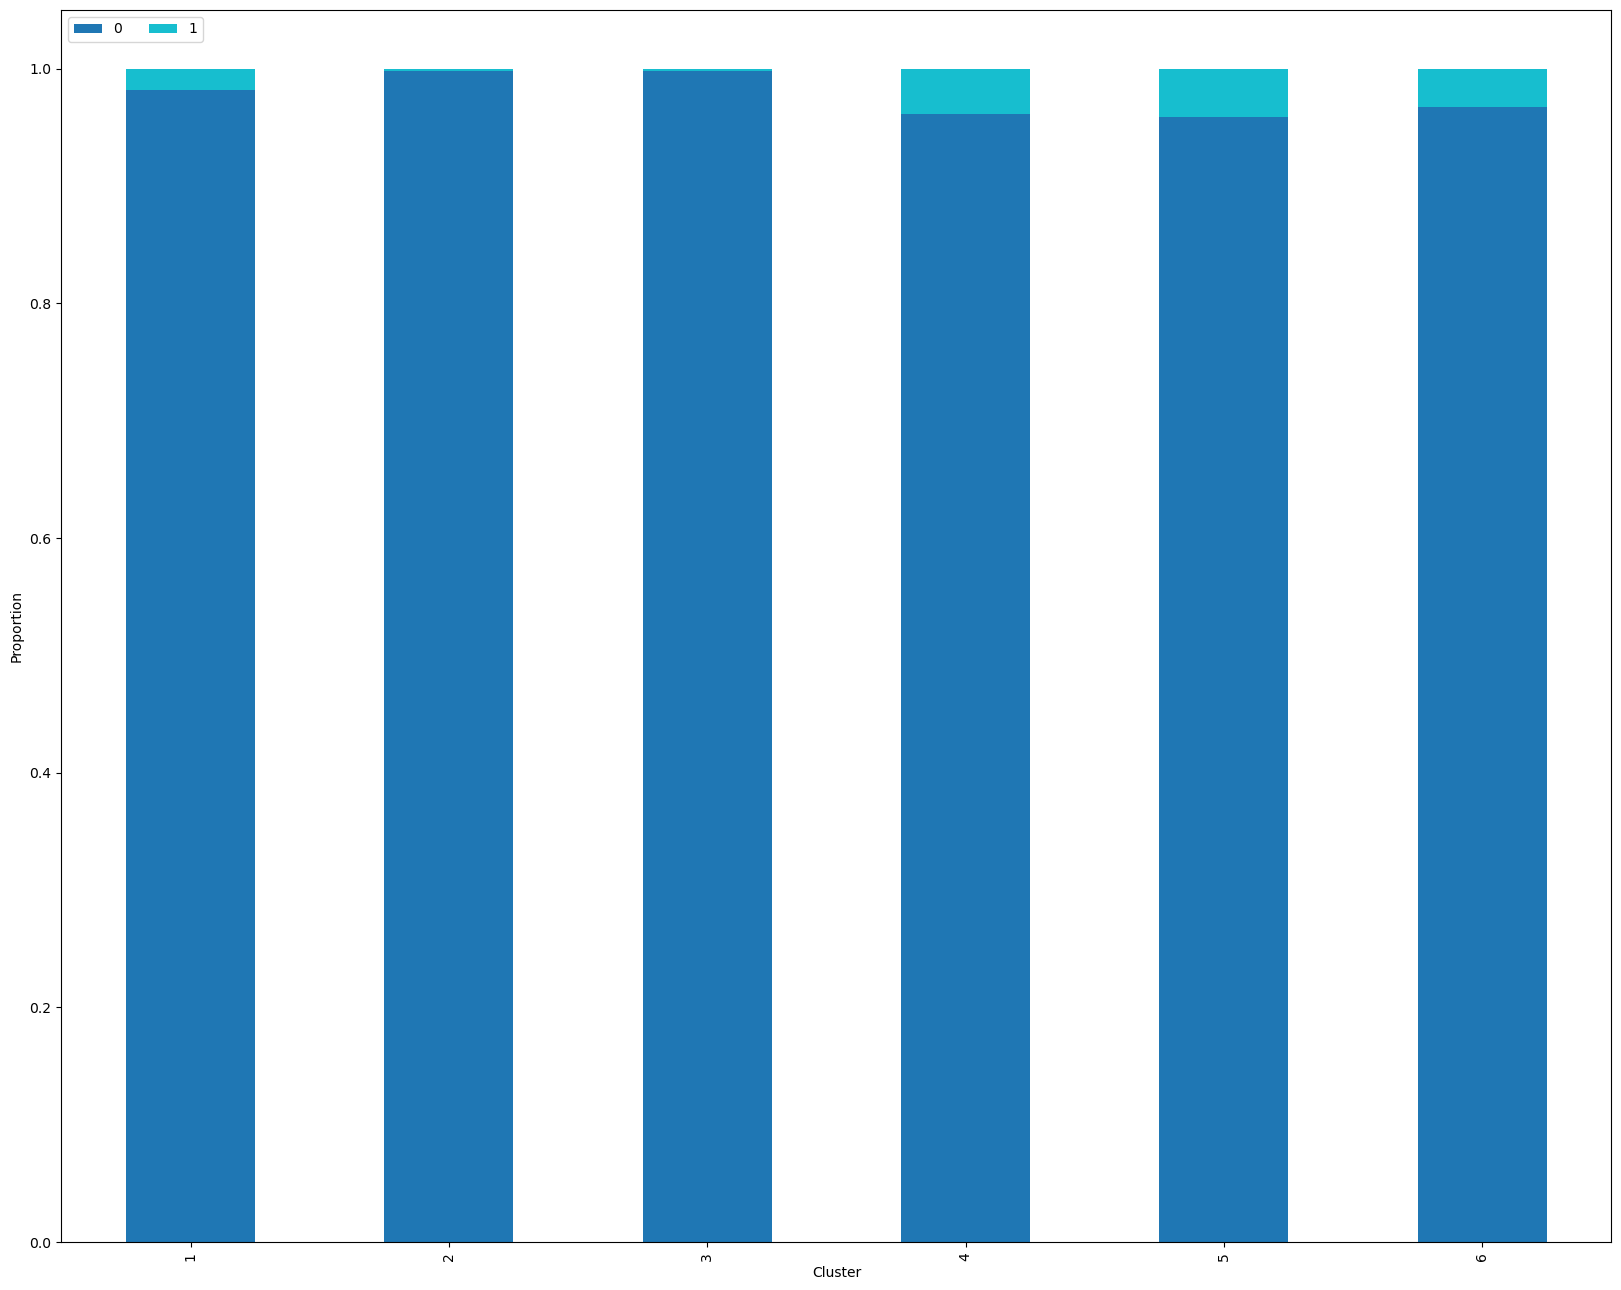

--------------------
graurisc
--------------------


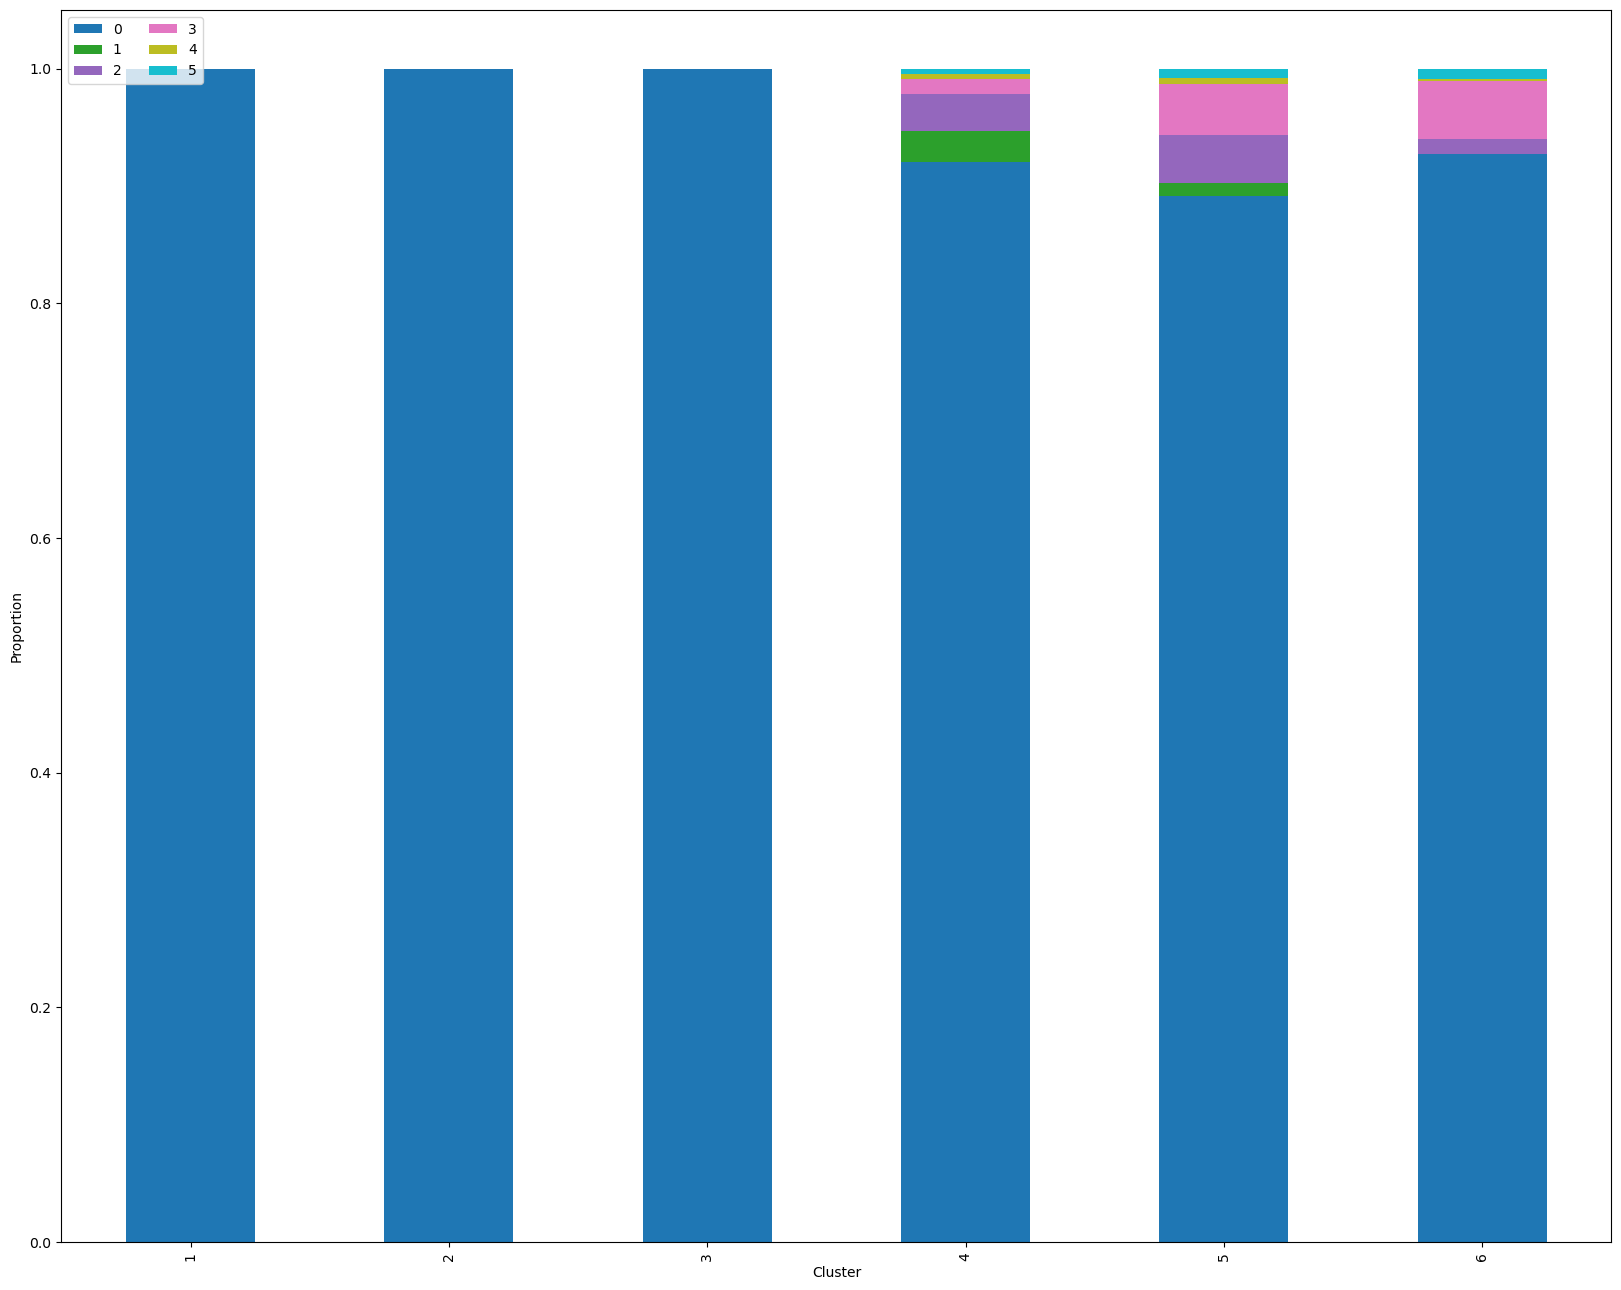

--------------------
flg_areas_de_risco
--------------------


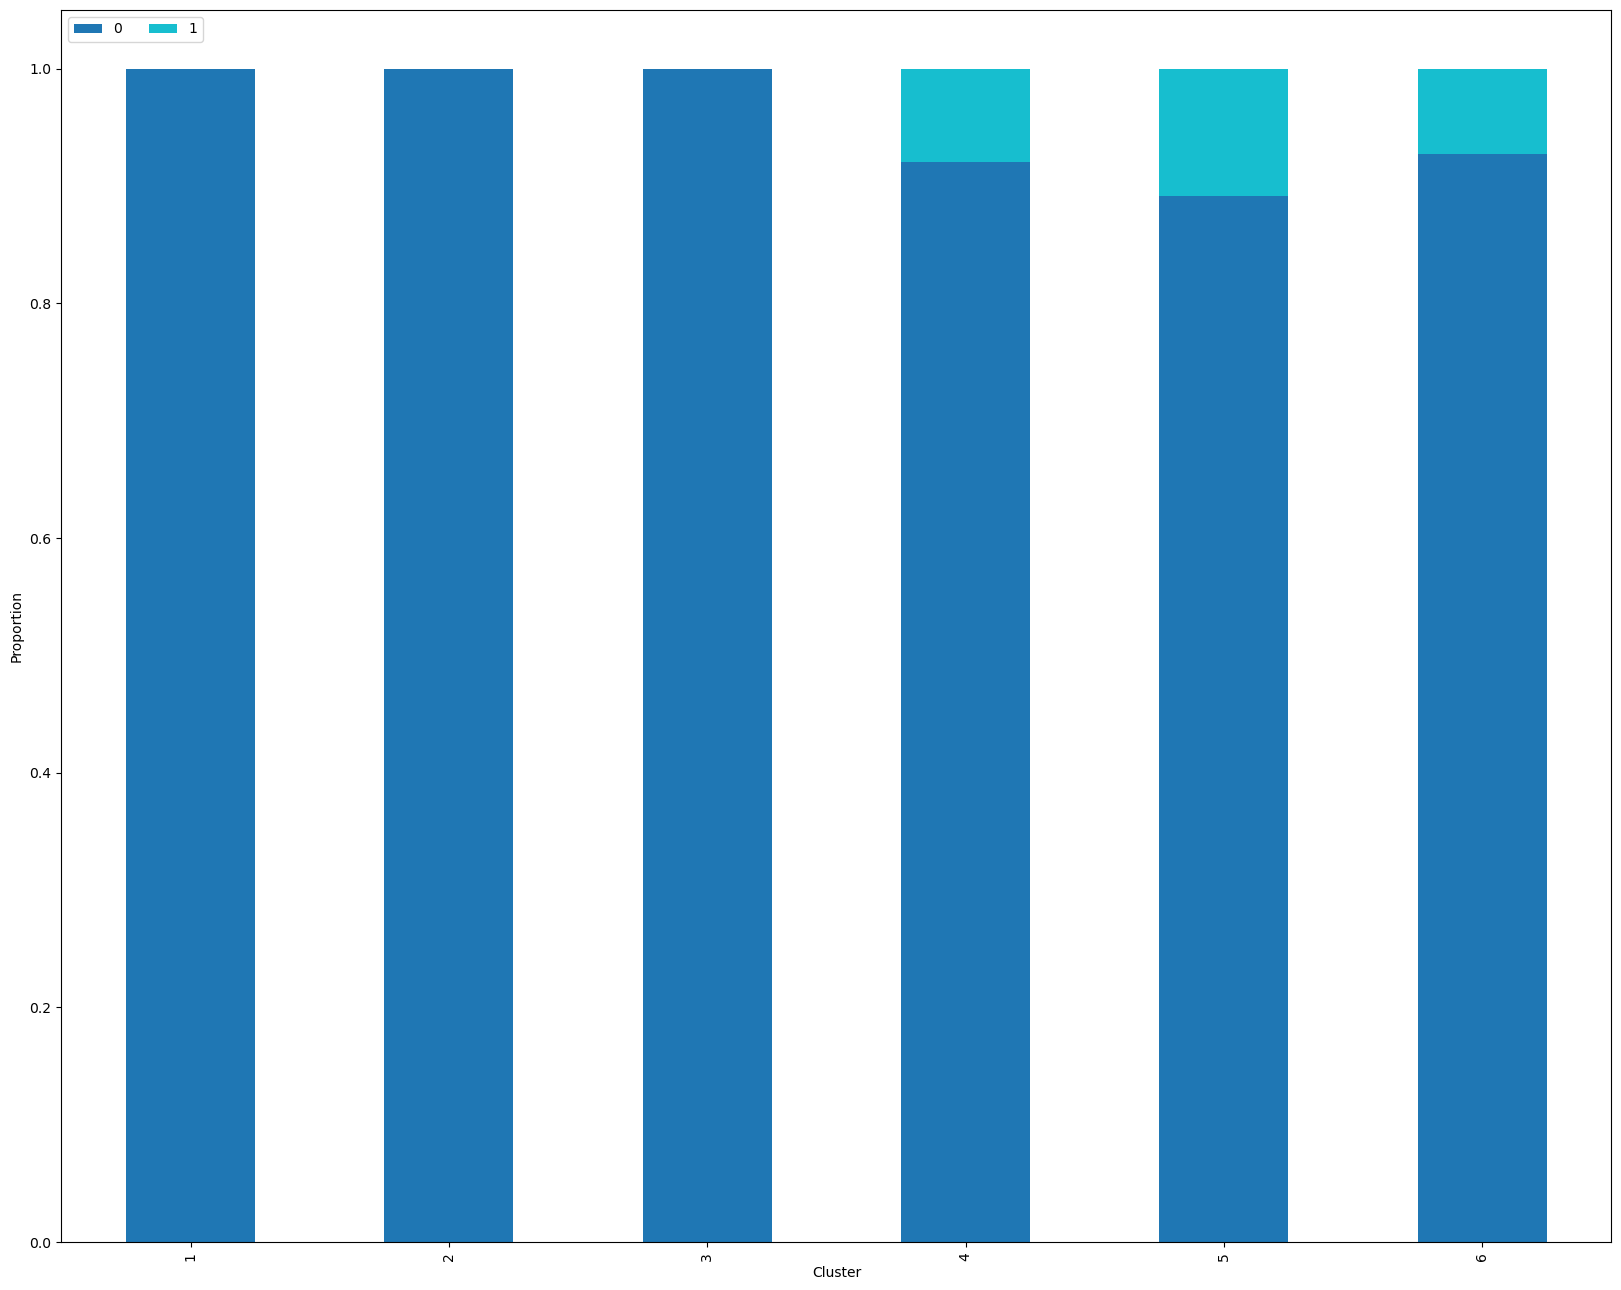

--------------------
Acoes_DC_0
--------------------


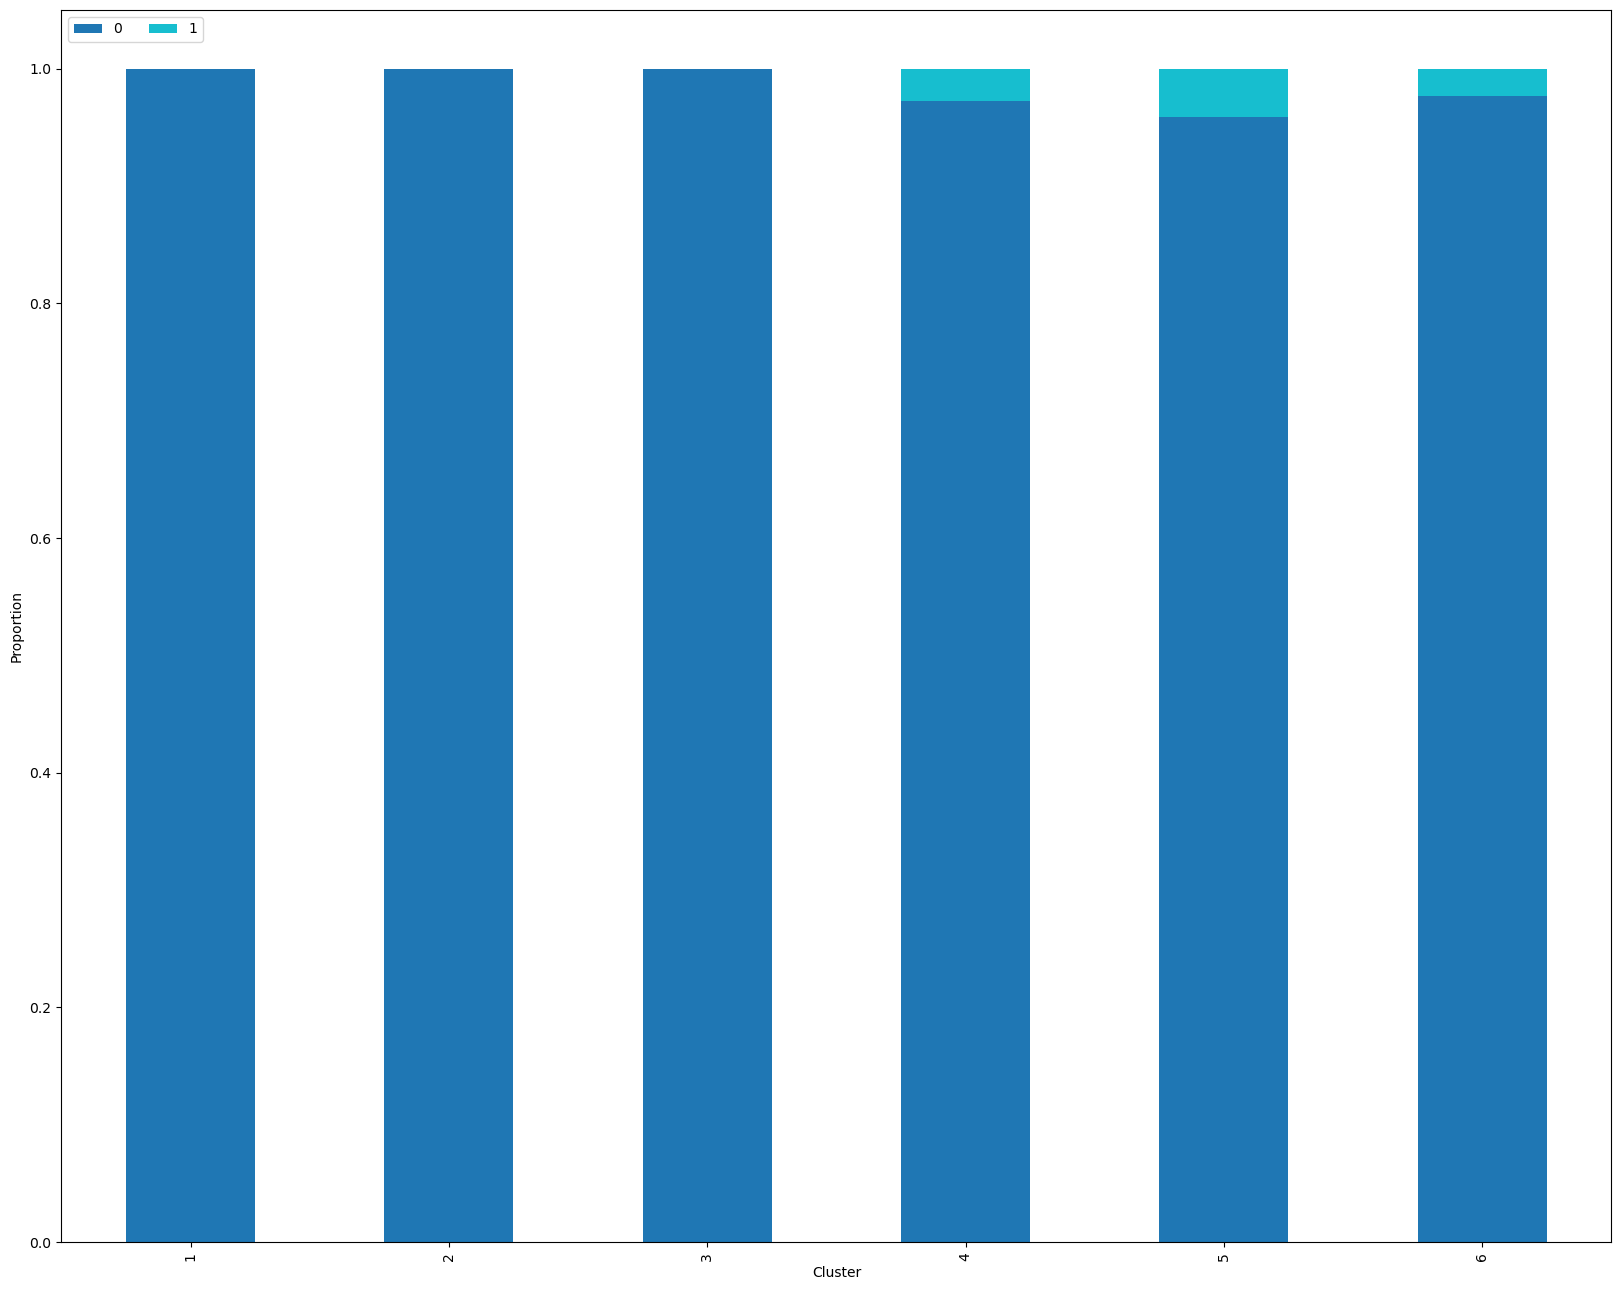

--------------------
Acoes_DC_1
--------------------


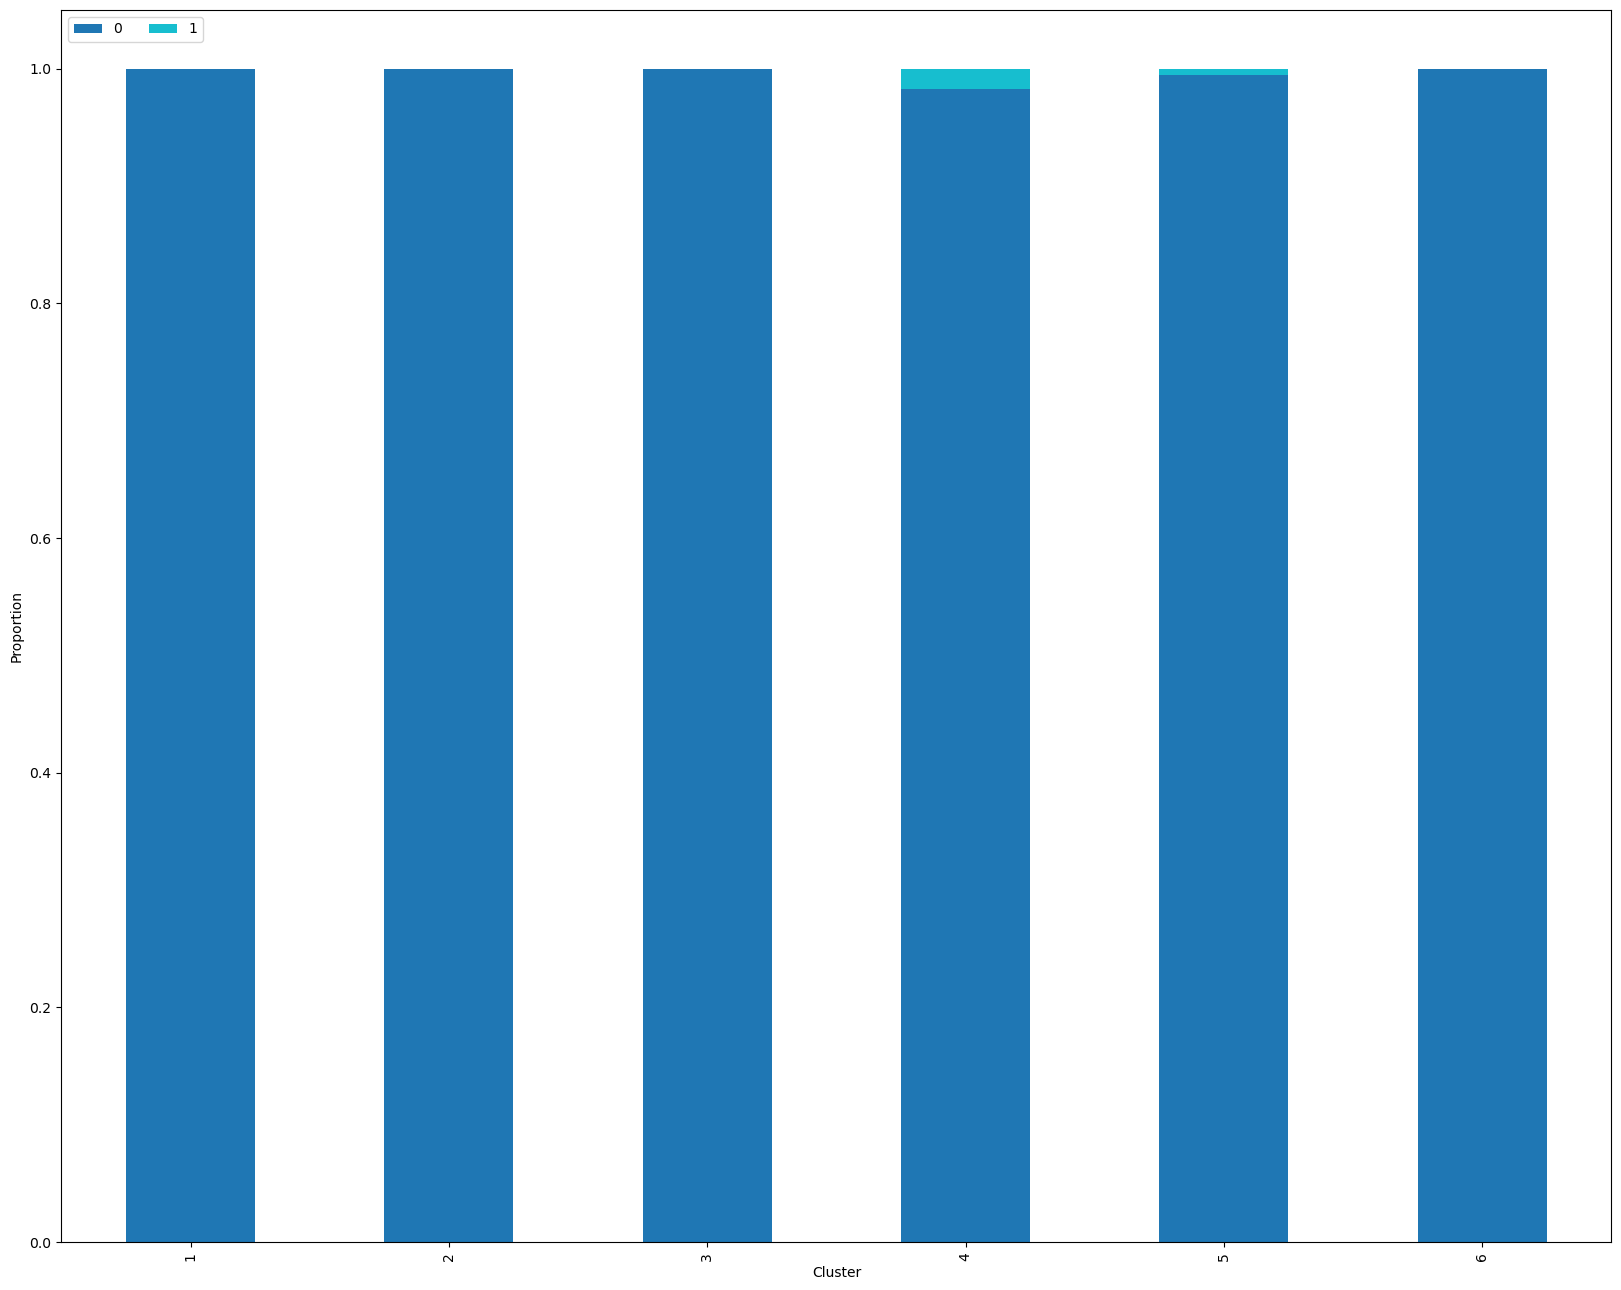

--------------------
Acoes_DC_2
--------------------


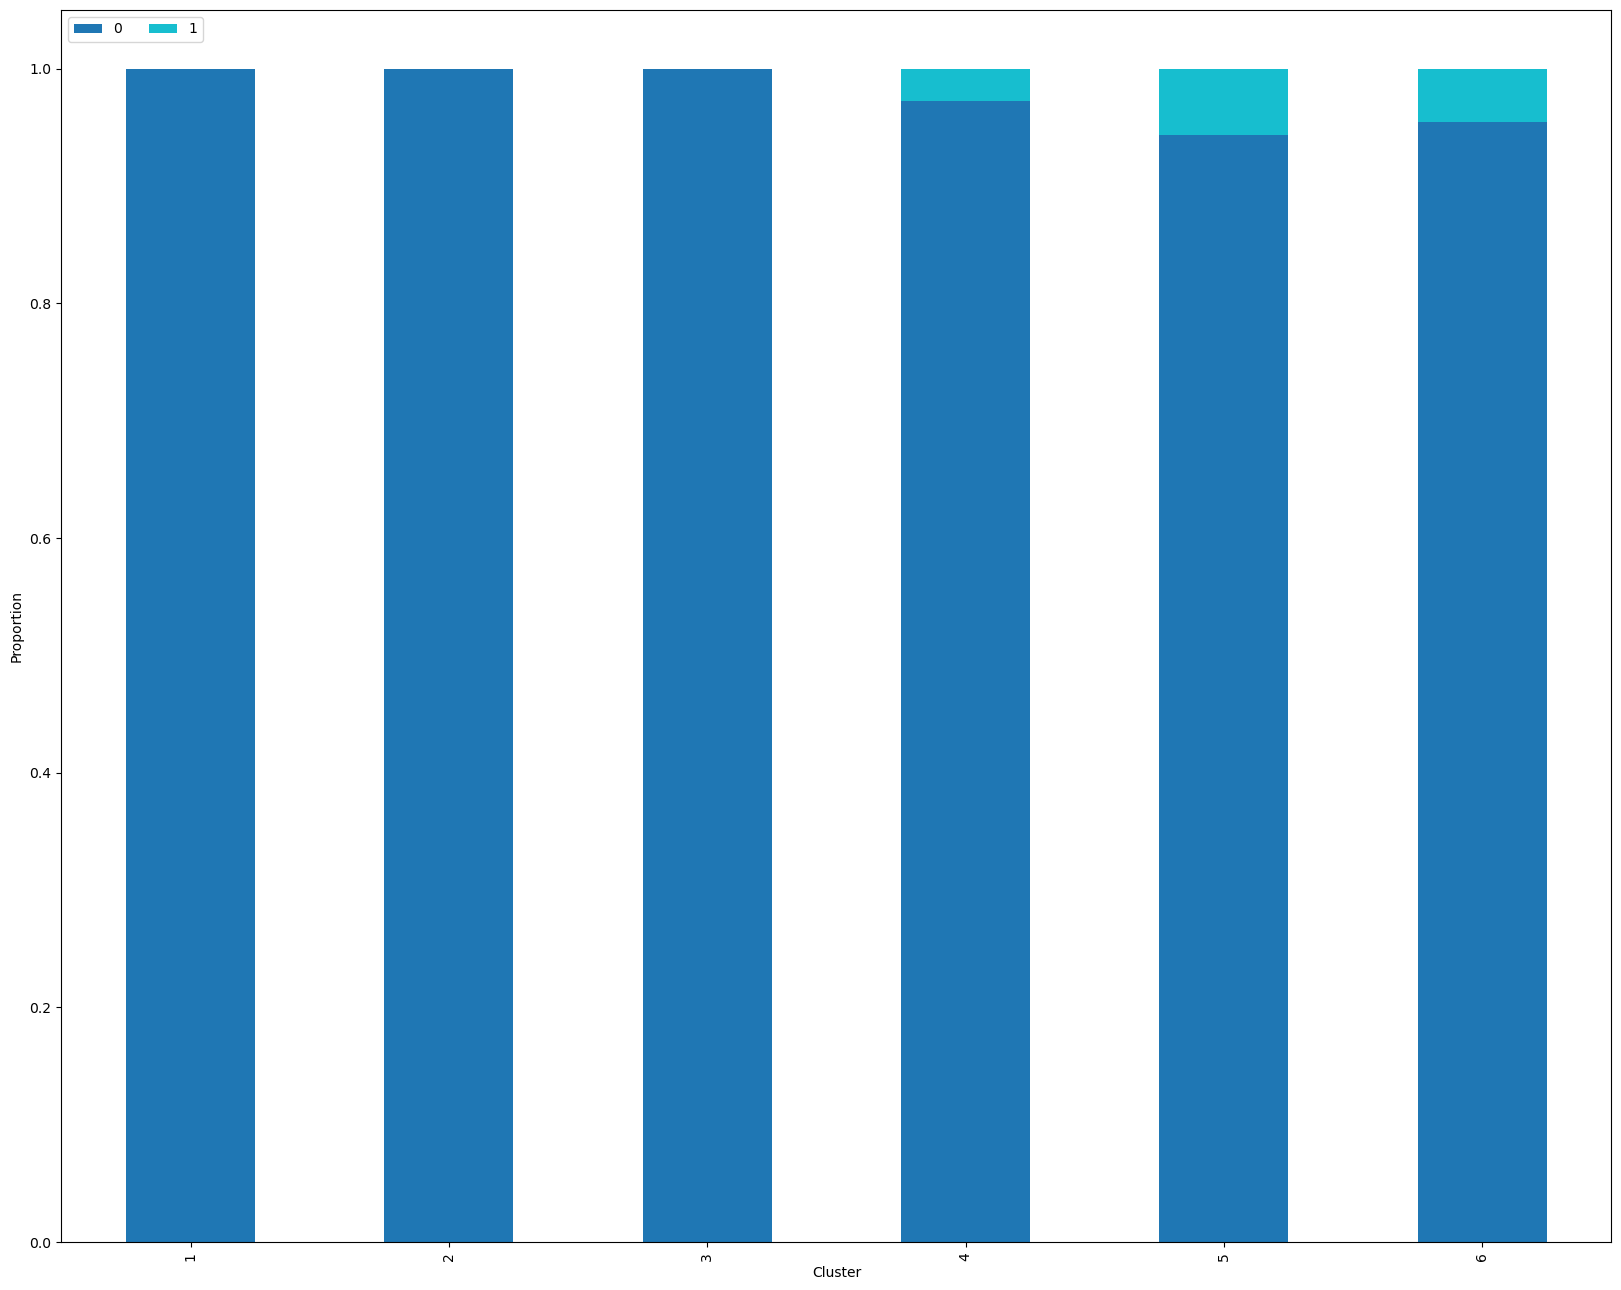

--------------------
Acoes_DC_3
--------------------


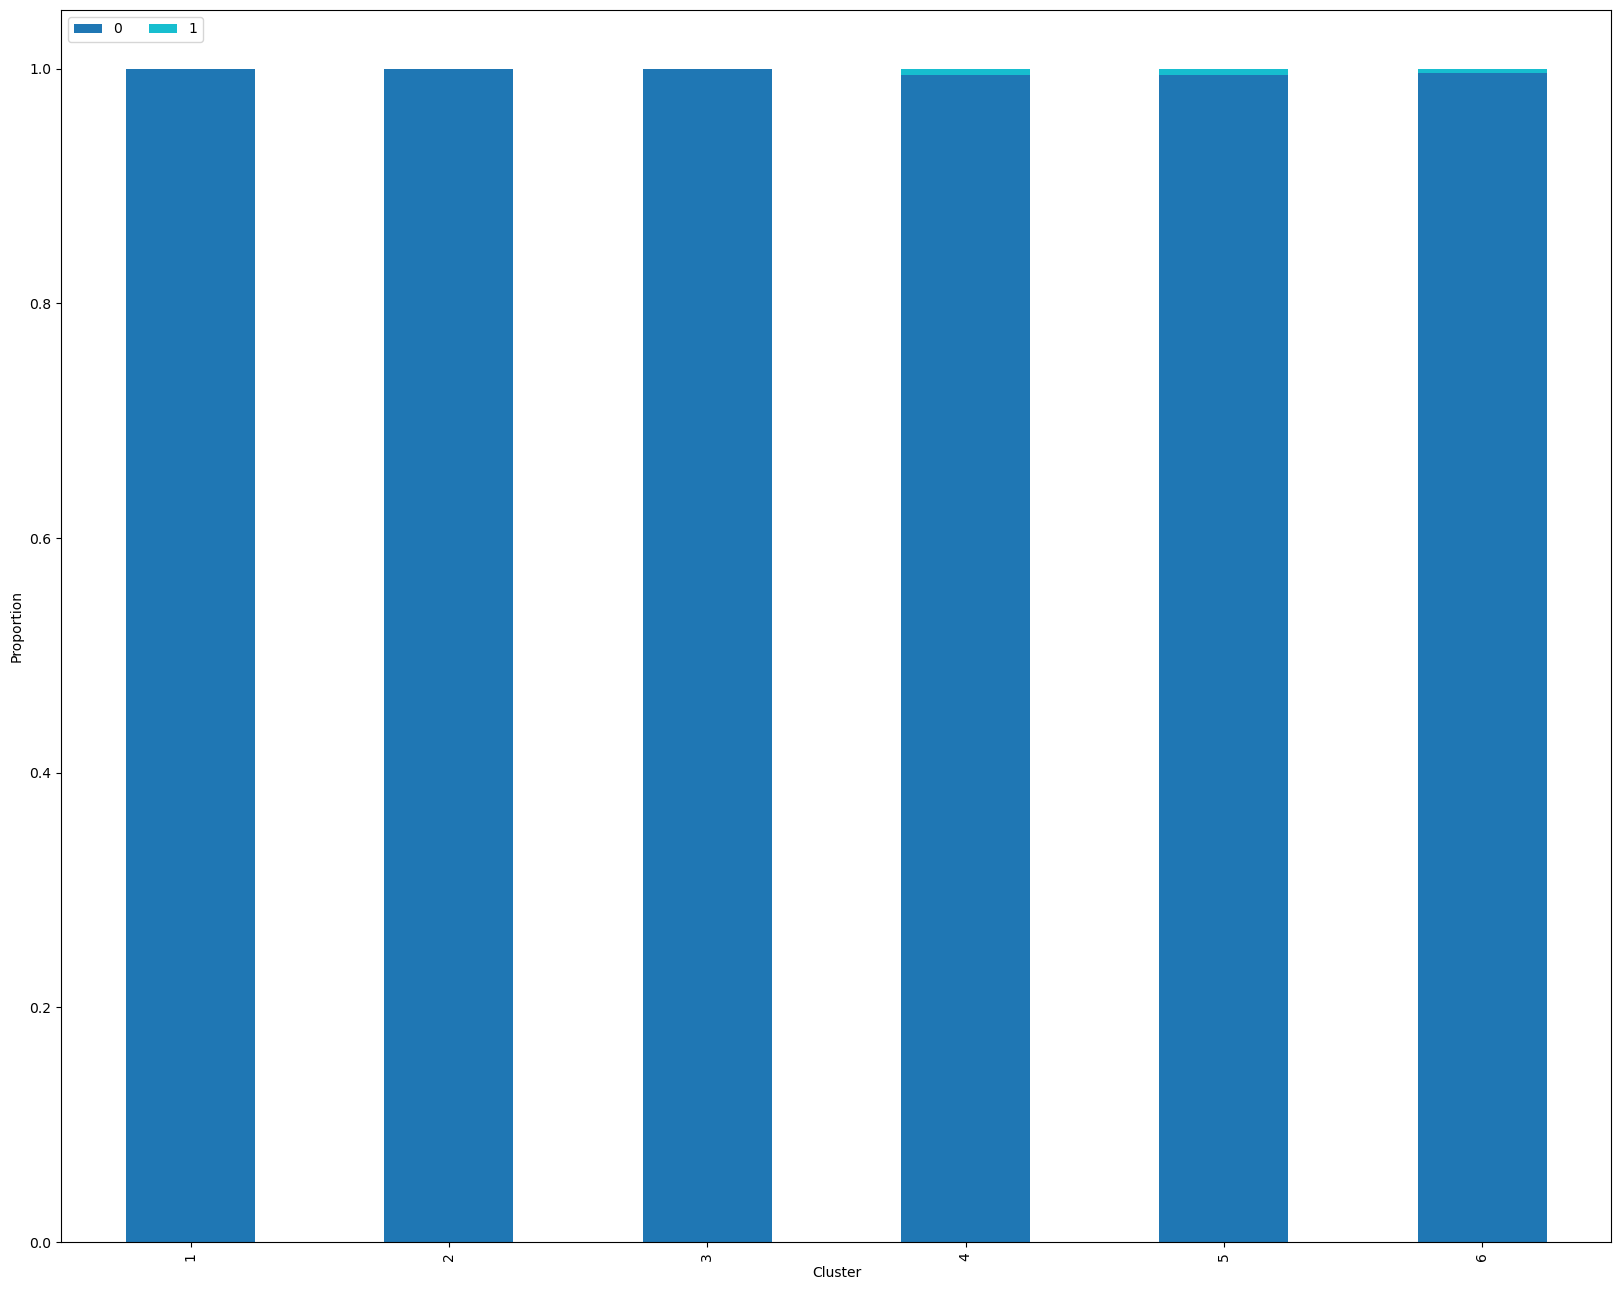

In [35]:
variaveis = ['Vegetacao_Natural_Dominante'                
, 'Area_Antropica_Dominante'                   
, 'Floresta_Ombrofila_Densa'                   
, 'Formacao_Pioneira'                          
, 'Floresta_Ombrofila_Densa_Submontana'        
, 'Influencia_urbana'                          
, 'legenda_2_Pecuária (pastagens)'             
, 'Vegetacao_Secundaria'                       
, 'Argilossolo'                                
, 'Gleissolo'                                  
, 'Argilossolo_Vermelho_Amarelo'               
, 'Gleissolo_Melanico'                         
, 'Area_Urbana'                                
, 'Unidades_de_Conservacao_Protecao_N_Integral'
, 'Unidades_de_Conservacao_Protecao_Integral'  
, 'Sem_Plano_de_Menejo'                        
, 'Plano_de_Manejo'                            
, 'flg_comunidades'                            
, 'flg_agricola'                               
, 'flg_exploracao_mineral'                     
, 'flg_corpo_hidrico'                          
, 'flg_rocha'                                  
, 'flg_cobertura_vegetal'                      
, 'flg_afloramento_rochoso'                    
, 'flg_favela'                                 
, 'flg_ocupacao_desordenada'                   
, 'graurisc'                                   
, 'flg_areas_de_risco'                         
, 'Acoes_DC_0'                                 
, 'Acoes_DC_1'                                 
, 'Acoes_DC_2'                                 
, 'Acoes_DC_3'                                              

]
for variavel in variaveis:
    print(20*'-')
    print( variavel)
    print(20*'-')
    cross_tab_prop = pd.crosstab(index=df_C_aux['Cluster'],
                                 columns=df_C_aux[variavel],
                                 normalize="index")
    
    cross_tab = pd.crosstab(index=df_C_aux['Cluster'],
                                 columns=df_C_aux[variavel])
    
    cross_tab_prop.plot(kind='bar', 
                        stacked=True, 
                        colormap='tab10', 
                        figsize=(20, 16))
    
    plt.legend(loc="upper left", ncol=2)
    plt.xlabel("Cluster")
    plt.ylabel("Proportion")
    plt.show()

--------------------
Altitude_numerica
--------------------


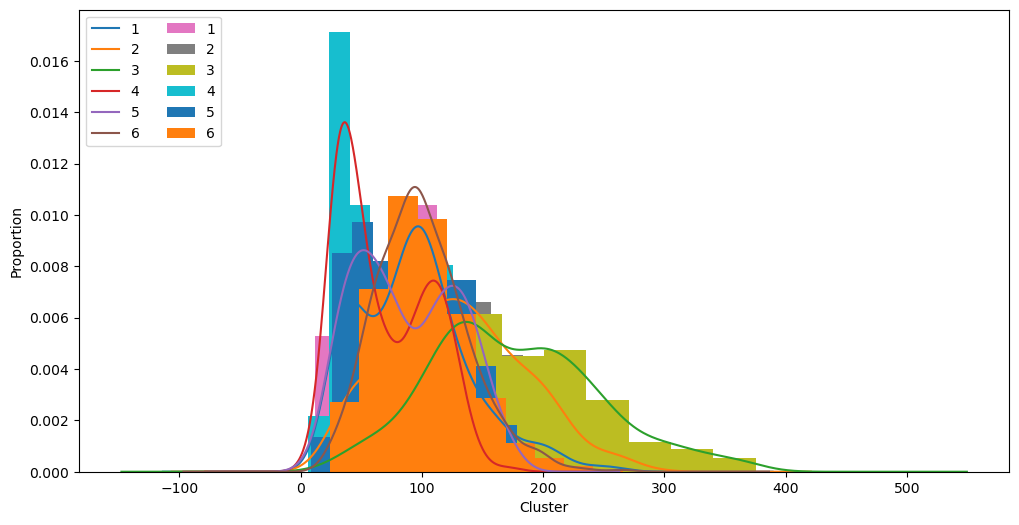

--------------------
Declividade_numerica
--------------------


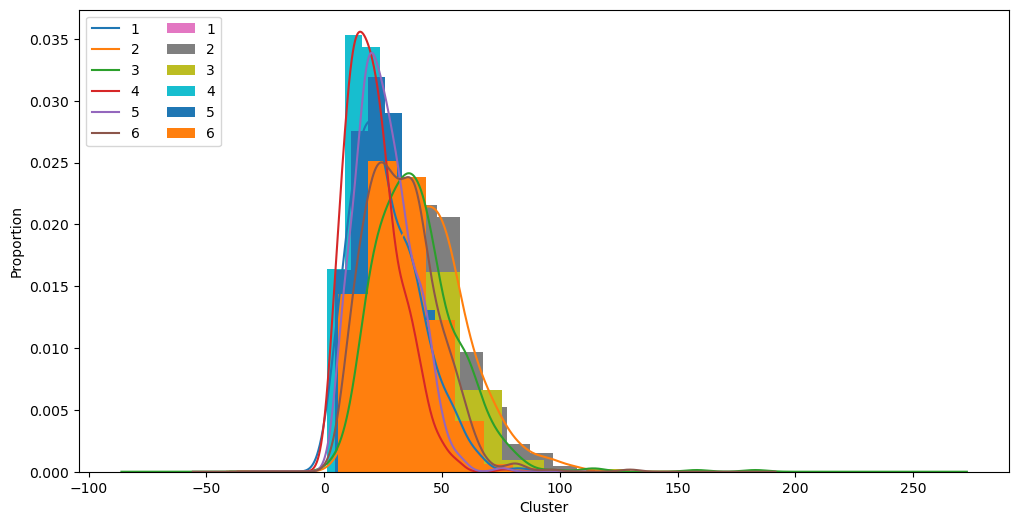

--------------------
Orientacao_numerica
--------------------


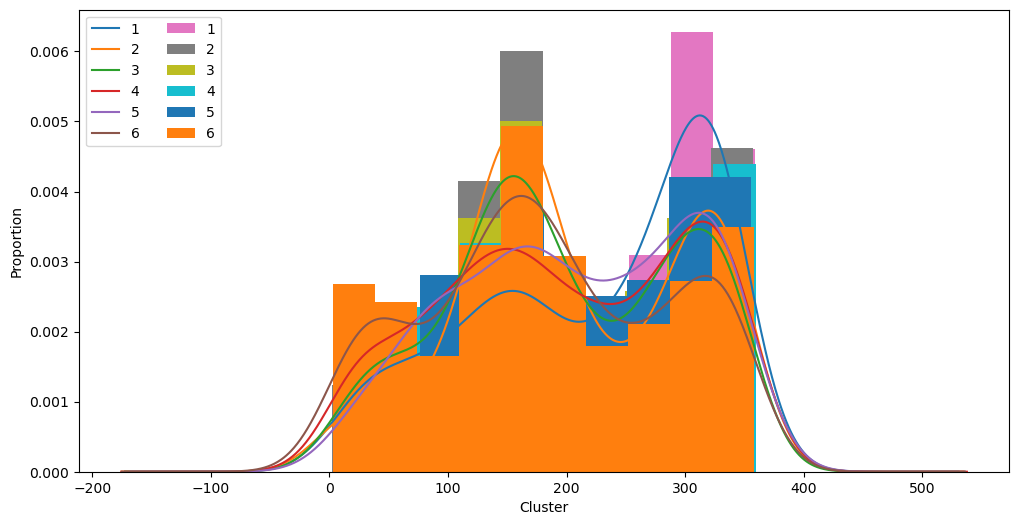

--------------------
Curv_Vertical_numerica
--------------------


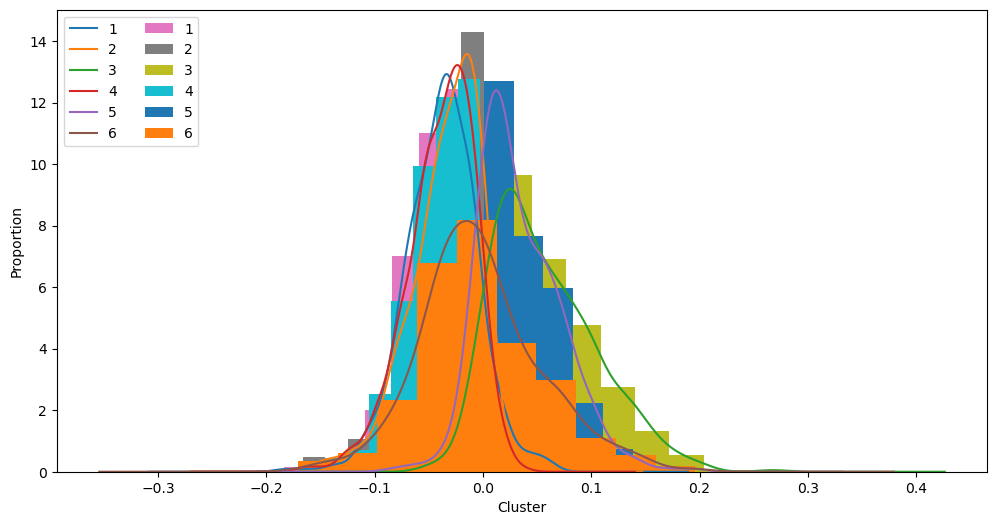

--------------------
Curv_Horizontal_numerica
--------------------


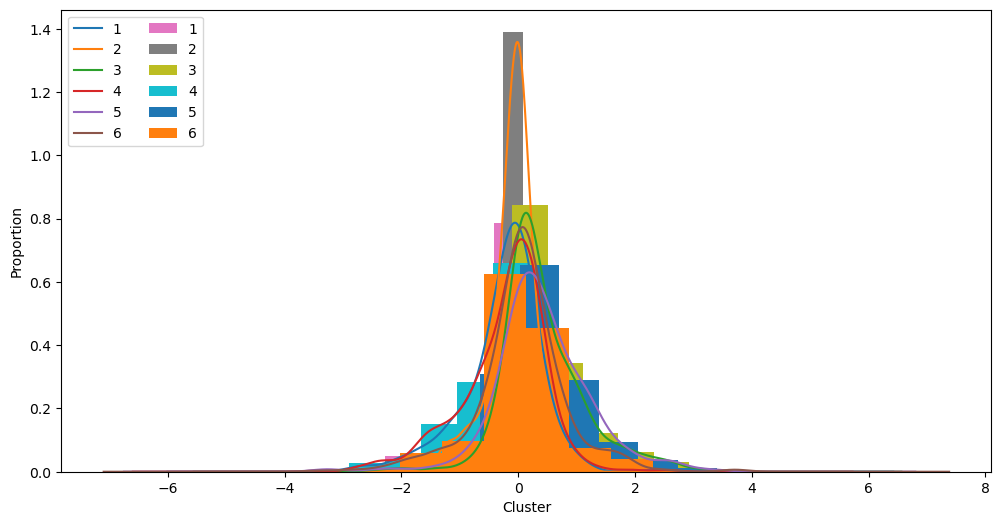

--------------------
Relevo_sombreado_numerico
--------------------


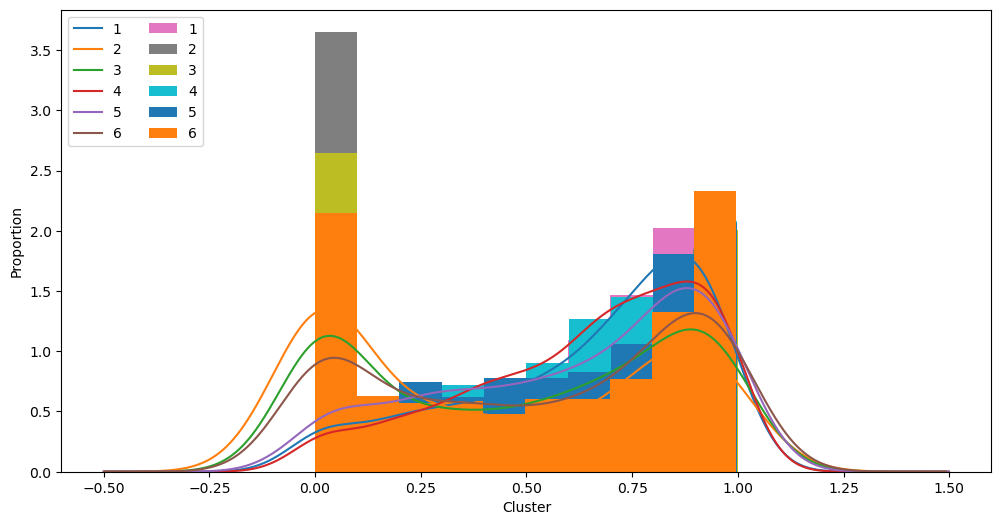

--------------------
lat
--------------------


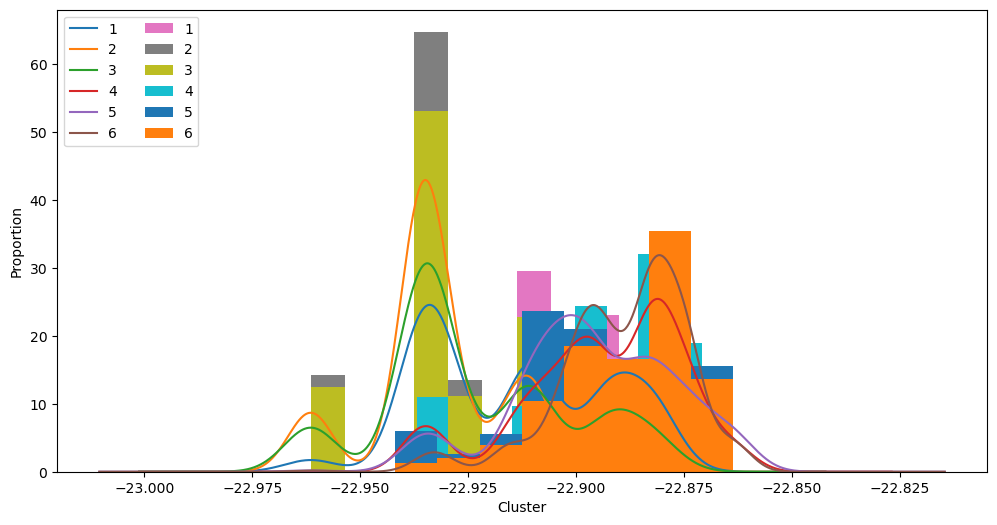

--------------------
long
--------------------


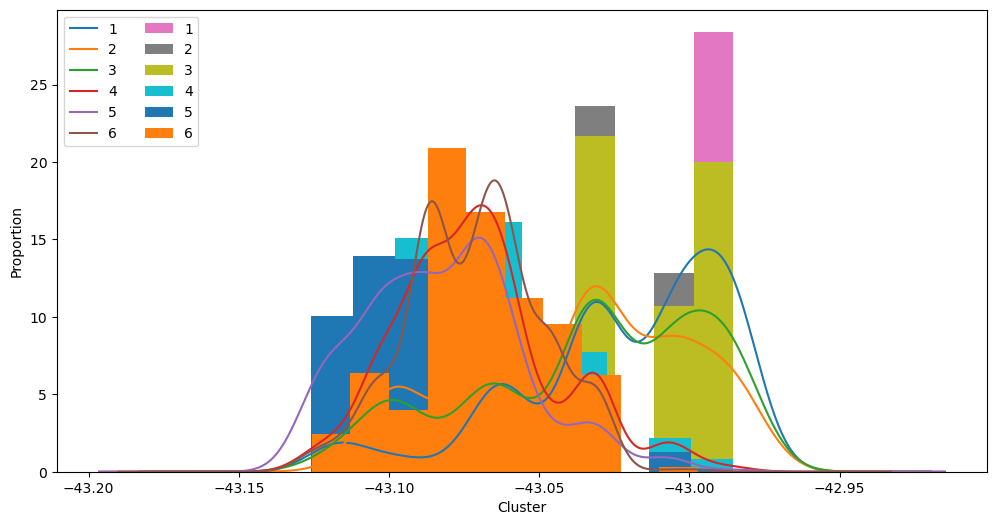

--------------------
Declividade_classes_A
--------------------


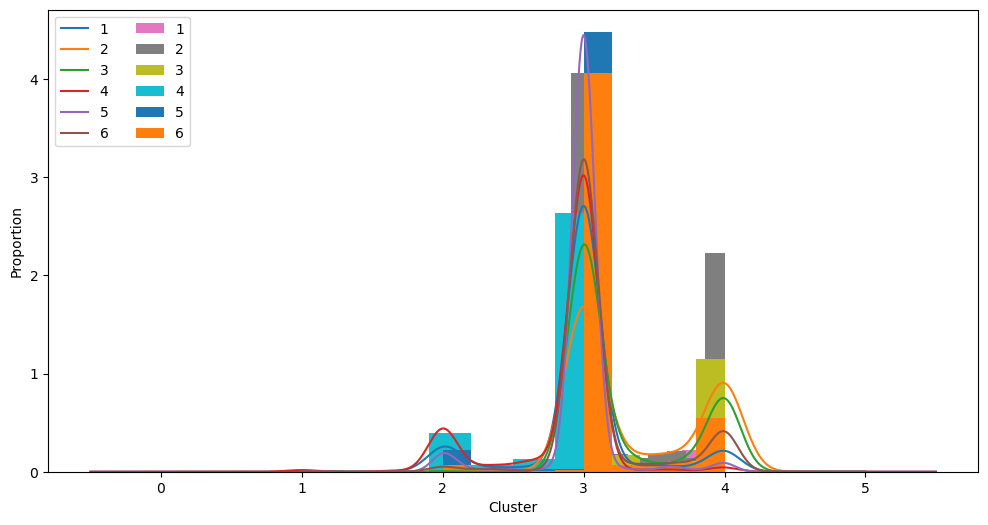

--------------------
Declividade_classes_B
--------------------


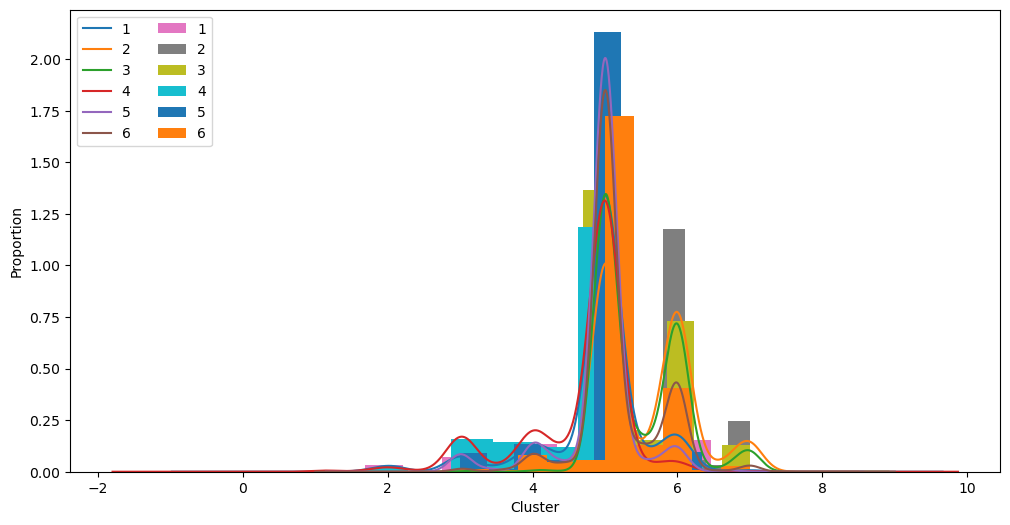

--------------------
Declividade_classes_C
--------------------


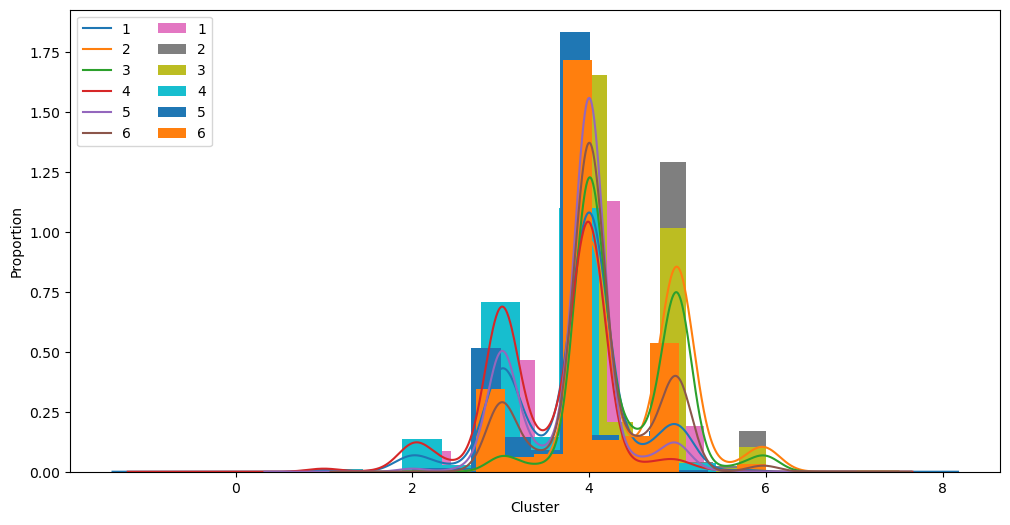

--------------------
Orientacao_octantes
--------------------


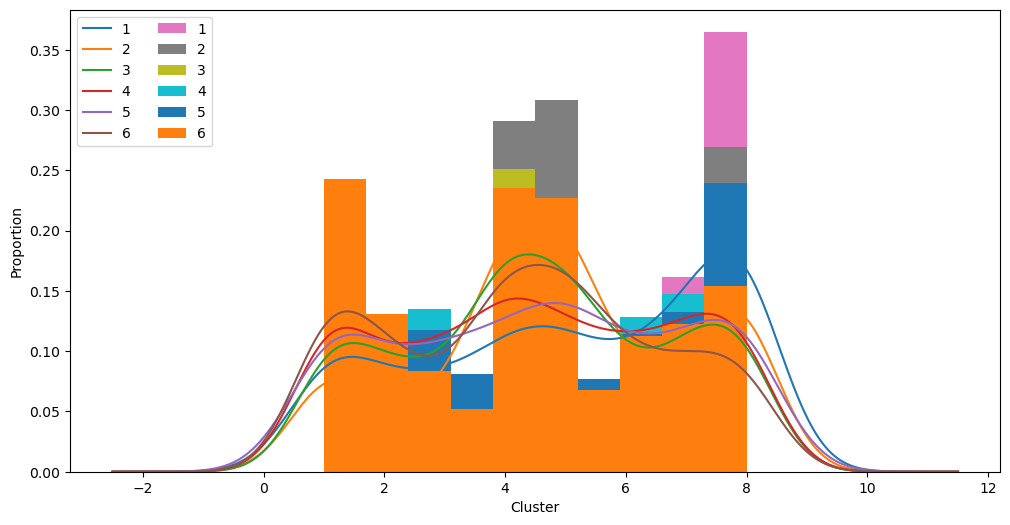

--------------------
Curv_Vertical_3classes
--------------------


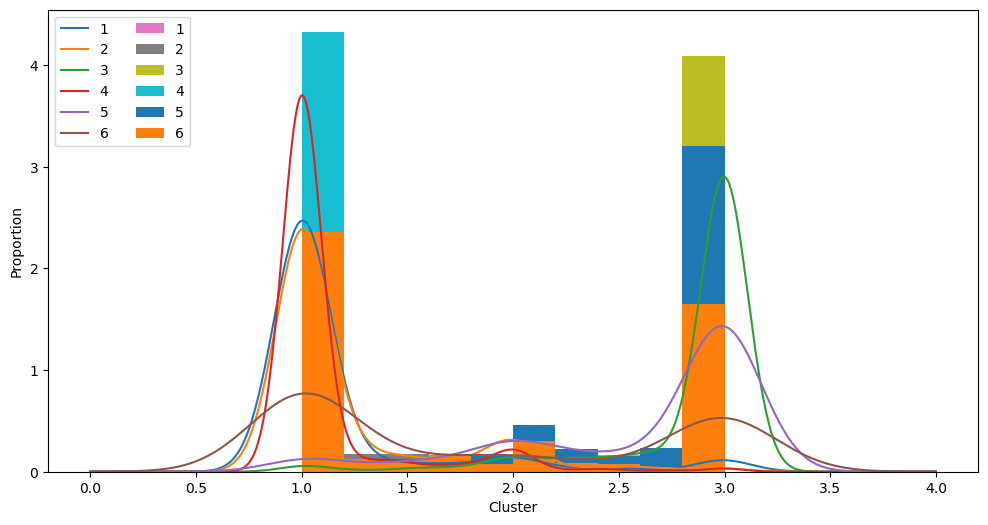

--------------------
Curv_Vertical_5classes
--------------------


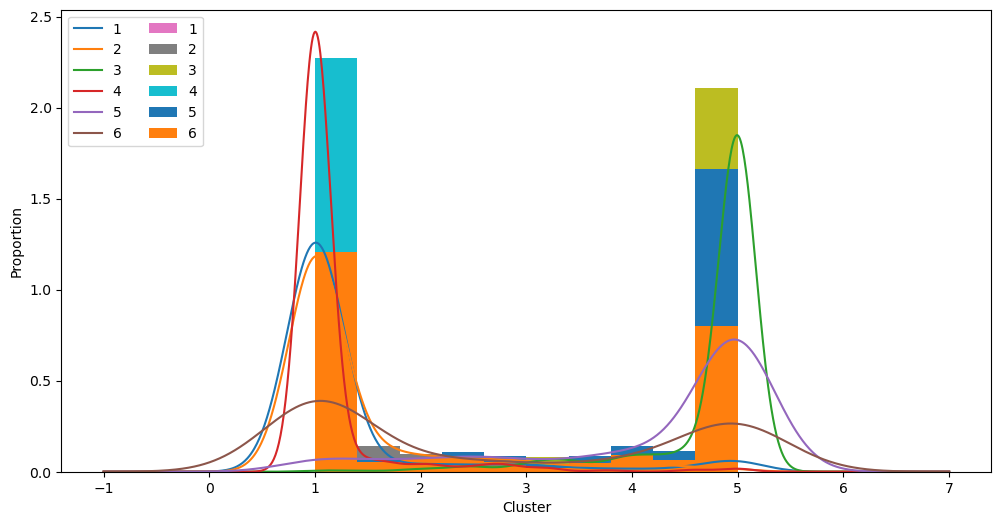

--------------------
Curv_Horizontal_3classes
--------------------


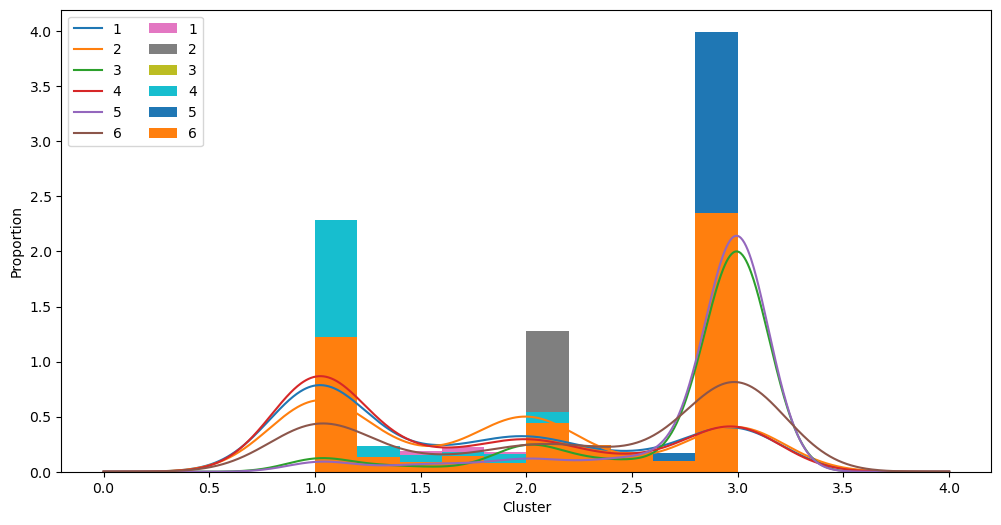

--------------------
Curv_Horizontal_5classes
--------------------


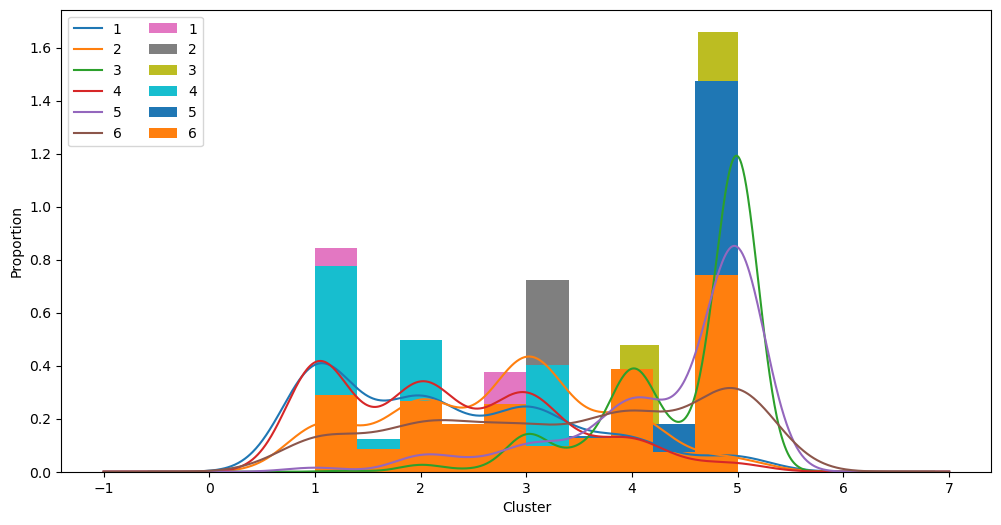

--------------------
Forma_de_terreno_classes
--------------------


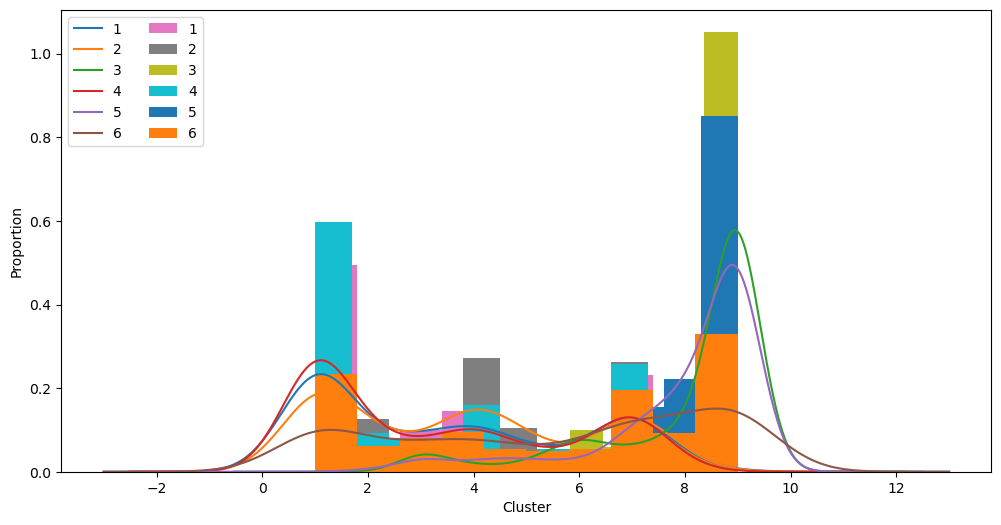

--------------------
ADD_divisores_talvegues
--------------------


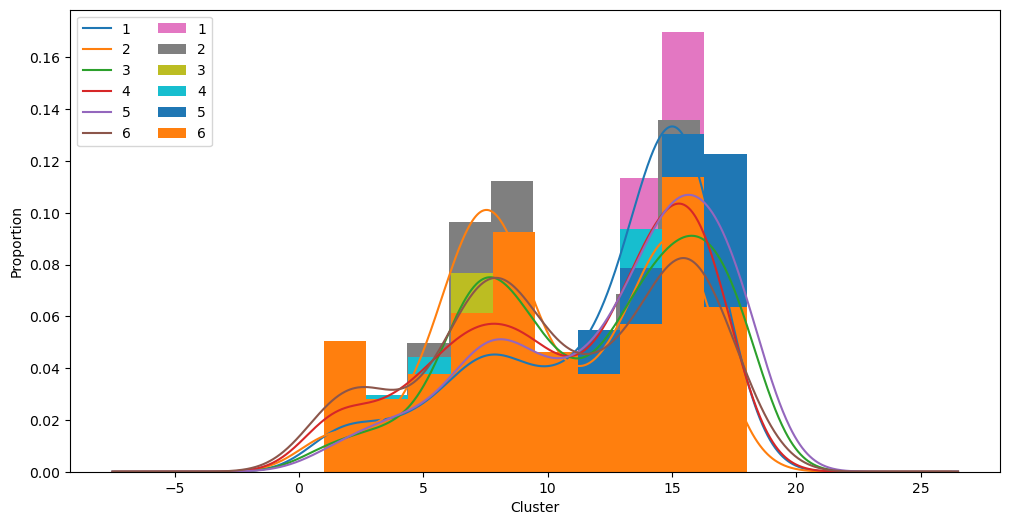

In [36]:
variaveis = ['Altitude_numerica'        
, 'Declividade_numerica'     
, 'Orientacao_numerica'      
, 'Curv_Vertical_numerica'   
, 'Curv_Horizontal_numerica' 
, 'Relevo_sombreado_numerico'
, 'lat'                      
, 'long' 
, 'Declividade_classes_A'    
, 'Declividade_classes_B'    
, 'Declividade_classes_C'    
, 'Orientacao_octantes'      
, 'Curv_Vertical_3classes'   
, 'Curv_Vertical_5classes'   
, 'Curv_Horizontal_3classes' 
, 'Curv_Horizontal_5classes' 
, 'Forma_de_terreno_classes'
, 'ADD_divisores_talvegues' 
,              
 ]
df_grouped = df_C_aux.groupby('Cluster')
for variavel in variaveis:
    print(20*'-')
    print( variavel)
    print(20*'-')
    df_grouped[variavel].plot.kde()
    df_grouped[variavel].plot.hist(density=True)
    
    plt.legend(loc="upper left", ncol=2)
    plt.xlabel("Cluster")
    plt.ylabel("Proportion")
    plt.show()

# Normalização dos Dados

In [9]:
normalizador_min_max(df_C,  ['Altitude_numerica'                            
,'Declividade_numerica'                         
,'Orientacao_numerica'                          
,'Curv_Vertical_numerica'                       
,'Curv_Horizontal_numerica'                     
,'Declividade_classes_A'                        
,'Declividade_classes_B'                        
,'Declividade_classes_C'                        
,'Orientacao_octantes'                          
,'Curv_Vertical_3classes'                       
,'Curv_Vertical_5classes'                       
,'Curv_Horizontal_3classes'                     
,'Curv_Horizontal_5classes'                     
,'Forma_de_terreno_classes'                     
,'Relevo_sombreado_numerico'                   
,'ADD_divisores_talvegues'                                          
,'graurisc'                                                                                                        
,'lat'                                          
,'long'])

,geometry,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,...,Acoes_DC_2,Acoes_DC_3,index_right,id_estacao,lat,long,geom,lat_ocr,lon_ocr,Cluster
n_coord,,,,,,,,,,,,,,,,,,,,,
0,POINT (-43.086619740961986 -22.98827473545556),0.172138,0.217604,0.516144,0.606277,0.525204,0.666667,0.709113,0.657810,0.571429,...,0,0,4,522,0.270676,0.188473,POLYGON ((-43.127740327967494 -23.102169999999...,-22.988275,-43.086620,3
1,POINT (-43.08296224331565 -22.98760592826406),0.081971,0.201985,0.422701,0.430061,0.529465,0.666667,0.659971,0.600000,0.495268,...,0,0,27,520,0.273433,0.395707,POLYGON ((-43.08503072753997 -22.9304164256828...,-22.987606,-43.082962,3
2,POINT (-43.08446320108891 -22.987003136353113),0.184681,0.154889,0.176934,0.619510,0.771365,0.666667,0.659971,0.600000,0.244470,...,0,0,27,520,0.273433,0.395707,POLYGON ((-43.08503072753997 -22.9304164256828...,-22.987003,-43.084463,3
3,POINT (-43.08221839805482 -22.986477845745018),0.063625,0.133140,0.109945,0.455394,0.619770,0.666667,0.659971,0.600000,0.120970,...,0,0,27,520,0.273433,0.395707,POLYGON ((-43.08503072753997 -22.9304164256828...,-22.986478,-43.082218,3
4,POINT (-43.06793512389238 -22.985090626070075),0.073960,0.183974,0.675214,0.450879,0.614051,0.666667,0.659971,0.600000,0.791150,...,0,0,6,509,0.000000,0.660863,POLYGON ((-42.85912867612292 -23.1021699999999...,-22.985091,-43.067935,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,POINT (-43.0602721445704 -22.9007430464298),0.374111,0.187439,0.743006,0.419621,0.501557,0.666667,0.659971,0.600000,0.853610,...,0,0,0,526,0.656524,0.472674,POLYGON ((-43.03478643985882 -22.9093971237883...,-22.900743,-43.060272,5
3131,POINT (-43.0515212971214 -22.8801471061243),0.302234,0.112763,0.352941,0.431759,0.394825,0.666667,0.659971,0.600000,0.424345,...,1,0,14,524,0.869104,0.566342,POLYGON ((-43.01582051143834 -22.7228100000000...,-22.880147,-43.051521,6
3132,POINT (-43.0712384049347 -22.9054908762728),0.287362,0.093428,0.654074,0.436583,0.513019,0.666667,0.659971,0.448483,0.726910,...,0,0,11,508,0.556361,0.391443,POLYGON ((-43.07981003775825 -22.9085487945791...,-22.905491,-43.071238,5


# Análise 6 Clusters

## Cluster 1

In [10]:
df_C1 = df_C[df_C['Cluster'] == 1].drop(columns= ["geometry"      
                                                , "index_right"
                                                , "geom"       
                                                , "lat_ocr"    
                                                , "lon_ocr"
                                                , "id_estacao"  
                                                , "Cluster" ])

In [12]:
#percentage of missing values in each variable

df_C1.isnull().sum()/len(df_C1)*100

Altitude_numerica                              0.0
Declividade_numerica                           0.0
Orientacao_numerica                            0.0
Curv_Vertical_numerica                         0.0
Curv_Horizontal_numerica                       0.0
Declividade_classes_A                          0.0
Declividade_classes_B                          0.0
Declividade_classes_C                          0.0
Orientacao_octantes                            0.0
Curv_Vertical_3classes                         0.0
Curv_Vertical_5classes                         0.0
Curv_Horizontal_3classes                       0.0
Curv_Horizontal_5classes                       0.0
Forma_de_terreno_classes                       0.0
Relevo_sombreado_numerico                      0.0
ADD_divisores_talvegues                        0.0
Vegetacao_Natural_Dominante                    0.0
Area_Antropica_Dominante                       0.0
Floresta_Ombrofila_Densa                       0.0
Formacao_Pioneira              

In [13]:
#storing the variance and name of variables

variance = df_C1.var()
columns = df_C1.columns

#saving the names of variables having variance more than a threshold value

variable = [ ]

for i in range(0,len(variance)):
    if variance[i]<=0.006: #setting the threshold as 1%
        variable.append(columns[i])

In [15]:
variable

['Curv_Vertical_numerica',
 'Vegetacao_Natural_Dominante',
 'Area_Antropica_Dominante',
 'Floresta_Ombrofila_Densa',
 'Formacao_Pioneira',
 'Floresta_Ombrofila_Densa_Submontana',
 'legenda_2_Pecuária (pastagens)',
 'Argilossolo',
 'Gleissolo',
 'Argilossolo_Vermelho_Amarelo',
 'Gleissolo_Melanico',
 'Area_Urbana',
 'Unidades_de_Conservacao_Protecao_Integral',
 'Plano_de_Manejo',
 'flg_agricola',
 'flg_exploracao_mineral',
 'flg_corpo_hidrico',
 'flg_rocha',
 'graurisc',
 'flg_areas_de_risco',
 'Acoes_DC_0',
 'Acoes_DC_1',
 'Acoes_DC_2',
 'Acoes_DC_3']

In [14]:
df_C1 = df_C1.drop(columns= variable)

<AxesSubplot:>

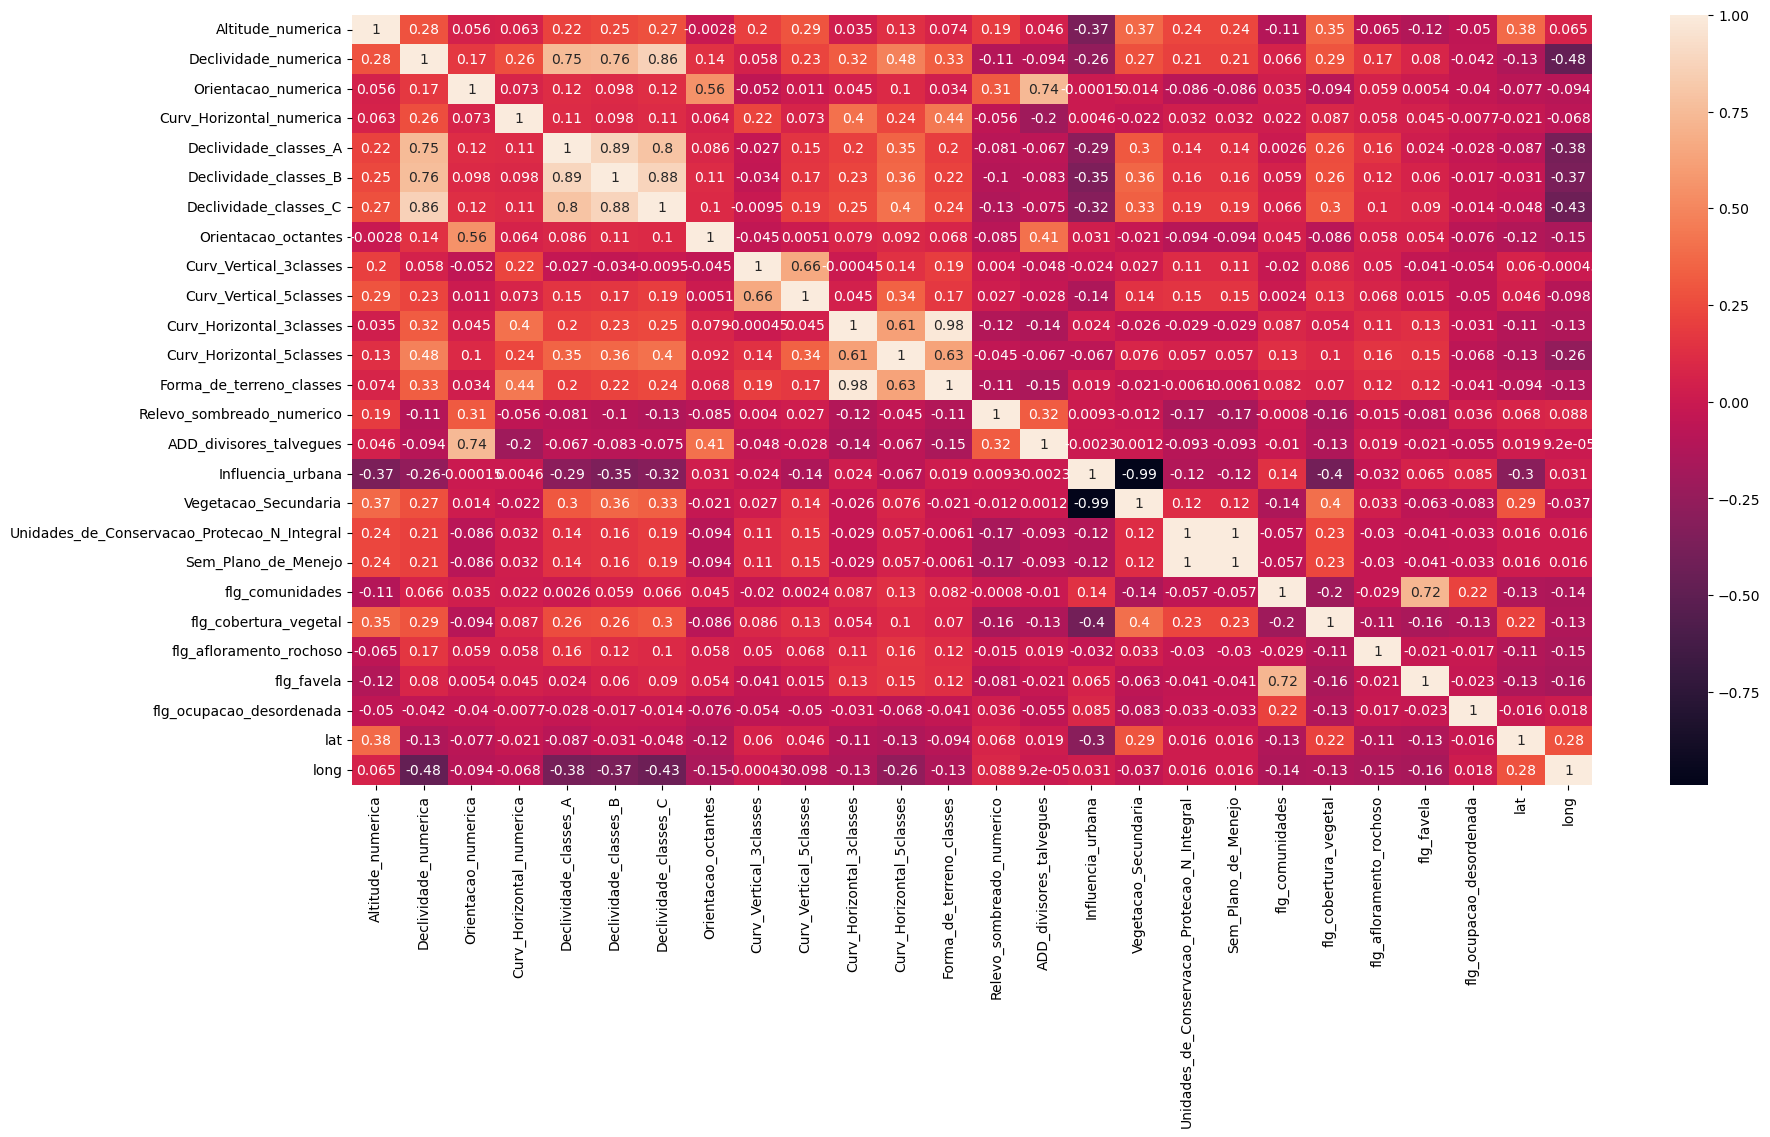

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(df_C1.corr(),annot=True)

In [17]:
print(get_top_abs_correlations(df_C1, 20))

Unidades_de_Conservacao_Protecao_N_Integral  Sem_Plano_de_Menejo         1.000000
Influencia_urbana                            Vegetacao_Secundaria        0.989867
Curv_Horizontal_3classes                     Forma_de_terreno_classes    0.981242
Declividade_classes_A                        Declividade_classes_B       0.890469
Declividade_classes_B                        Declividade_classes_C       0.877869
Declividade_numerica                         Declividade_classes_C       0.863771
Declividade_classes_A                        Declividade_classes_C       0.797339
Declividade_numerica                         Declividade_classes_B       0.761153
                                             Declividade_classes_A       0.751037
Orientacao_numerica                          ADD_divisores_talvegues     0.737942
flg_comunidades                              flg_favela                  0.722806
Curv_Vertical_3classes                       Curv_Vertical_5classes      0.662816
Curv_Horizontal_

In [18]:
df_C1.drop(columns=['Declividade_classes_A'
, 'Sem_Plano_de_Menejo'
, 'Vegetacao_Secundaria'
, 'Forma_de_terreno_classes'
, 'Declividade_classes_B'
, 'Declividade_classes_C'
, 'ADD_divisores_talvegues'
, 'flg_favela'], inplace=True)

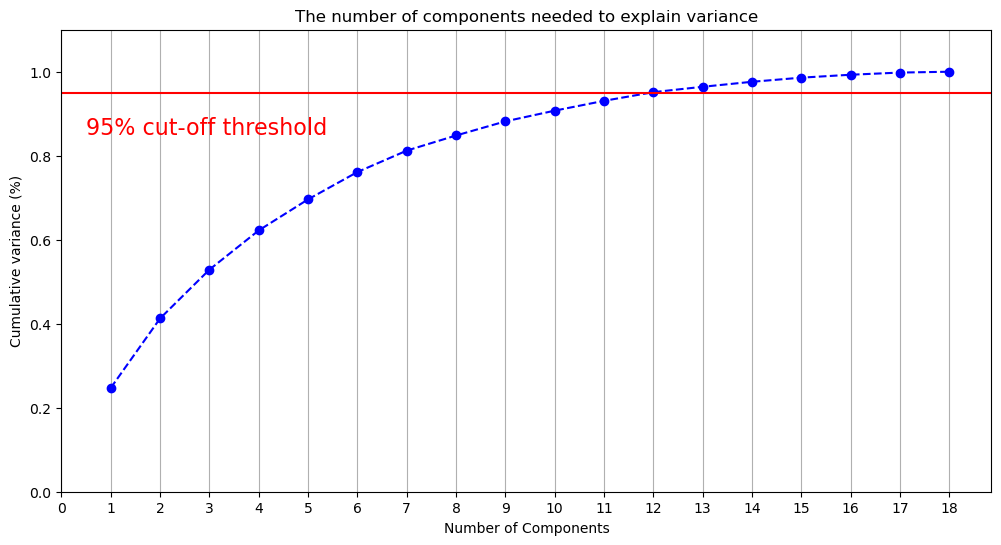

In [19]:
PCA_explicabilidade(df_C1, seed = 42)

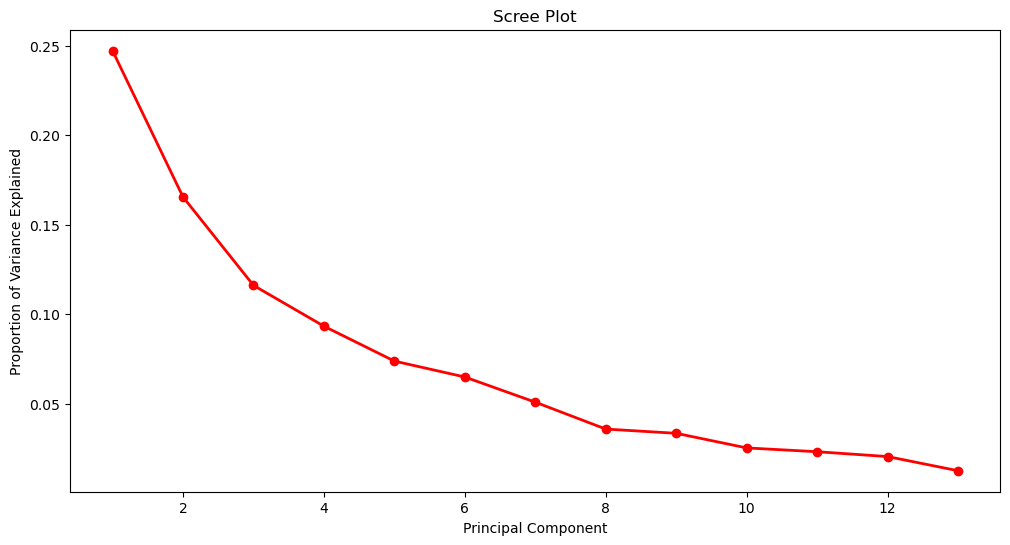

In [21]:
PCA_elbow(df_C1, componentes = 13, seed = 42)

|# varimax method, which simplifies the factors, and the quartimax method, which simplifies the variables.

In [22]:
# 8 fatores
fa = FactorAnalyzer( 8, rotation="varimax")

# o objeto tem o método fit para análise do dataframe
fa.fit(df_C1)

# Desse extraimos as cargas fatoriais (factor loadings)
# Observe que fa.loadings_ é um numpy.array com shape (25,6). Usamos o método
# do pandas pd.DataFrame.from_records para convertê-lo em um dataframe
factorLoadings = pd.DataFrame.from_records(fa.loadings_)
# Para ver a dataframe gerado:
factorLoadings.head()
# Substitue as linhas pelo nomes dos itens
itens=df_C1.columns
factorLoadings.index=itens

# Renomeia as colunas
factorLoadings.rename(columns = {0:'Fator 1',
                                 1:'Fator 2',
                                 2:'Fator 3',
                                 3:'Fator 4',
                                 4:'Fator 5',
                                5:'Fator 6',
                                6:'Fator 7',
                                7:'Fator 8'}, inplace = True)

# Exibe o resultado
factorLoadings

,Fator 1,Fator 2,Fator 3,Fator 4,Fator 5,Fator 6,Fator 7,Fator 8
Altitude_numerica,0.670019,0.195841,0.075996,0.082968,-0.151595,0.187493,0.029235,0.000973
Declividade_numerica,0.480100,0.037831,0.115633,0.257734,0.664257,-0.022835,0.182894,0.072260
Orientacao_numerica,-0.021643,-0.027424,0.594881,0.036767,0.134693,0.290710,0.047893,-0.015991
Curv_Horizontal_numerica,0.042095,0.102548,0.045729,0.217222,0.067275,-0.021018,0.701502,0.006961
Orientacao_octantes,-0.071717,-0.005023,0.978425,0.036050,0.088555,-0.144509,0.012213,-0.048493
Curv_Vertical_3classes,0.057143,0.841235,-0.043415,-0.027127,-0.020840,-0.009965,0.204804,-0.044426
Curv_Vertical_5classes,0.202678,0.801891,0.013952,0.157490,0.113992,0.028683,-0.086487,-0.013318
Curv_Horizontal_3classes,-0.013113,-0.058848,0.022734,0.729930,0.114092,-0.063263,0.346717,0.004124
Curv_Horizontal_5classes,0.111965,0.195309,0.051366,0.801059,0.307313,0.011719,0.019801,0.028101
Relevo_sombreado_numerico,-0.038361,0.026331,0.067092,-0.049404,-0.073904,0.989180,-0.034202,0.030251


In [23]:
df_C1_aux= df_C_aux[df_C_aux['Cluster'] == 1].drop(columns= ["geometry"      
                                                , "index_right"
                                                , "geom"       
                                                , "lat_ocr"    
                                                , "lon_ocr"
                                                , "id_estacao"  
                                                , "Cluster" ])

In [26]:
pd.options.display.max_columns = None

In [28]:
df_C1_aux.describe()

,n_coord,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,Curv_Vertical_3classes,Curv_Vertical_5classes,Curv_Horizontal_3classes,Curv_Horizontal_5classes,Forma_de_terreno_classes,Relevo_sombreado_numerico,ADD_divisores_talvegues,Vegetacao_Natural_Dominante,Area_Antropica_Dominante,Floresta_Ombrofila_Densa,Formacao_Pioneira,Floresta_Ombrofila_Densa_Submontana,Influencia_urbana,legenda_2_Pecuária (pastagens),Vegetacao_Secundaria,Argilossolo,Gleissolo,Argilossolo_Vermelho_Amarelo,Gleissolo_Melanico,Area_Urbana,Unidades_de_Conservacao_Protecao_N_Integral,Unidades_de_Conservacao_Protecao_Integral,Sem_Plano_de_Menejo,Plano_de_Manejo,flg_comunidades,flg_agricola,flg_exploracao_mineral,flg_corpo_hidrico,flg_rocha,flg_cobertura_vegetal,flg_afloramento_rochoso,flg_favela,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,index_right,id_estacao,lat,long,lat_ocr,lon_ocr,Cluster
count,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.0,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000,3135.000000
mean,1567.000000,108.091279,30.734504,202.610146,-0.005208,0.027883,3.081126,5.081469,3.992047,4.650892,1.767421,2.527976,2.157480,3.192666,5.239861,0.564118,11.328492,0.002871,0.975758,0.970016,0.008612,0.002871,0.366826,0.001276,0.602871,0.463796,0.030622,0.463796,0.030622,0.484211,0.013397,0.288676,0.024561,0.277512,0.200000,0.002233,0.001595,0.001914,0.0,0.491547,0.020415,0.126635,0.022967,0.111005,0.043381,0.015311,0.004466,0.021053,0.002552,12.790750,515.917703,-22.906953,-43.052543,-22.908271,-43.051524,3.512600
std,905.140873,61.279351,16.836459,99.297680,0.055680,0.768151,0.423880,0.711229,0.719126,2.266371,0.887557,1.799023,0.846438,1.416334,3.045271,0.338600,4.632351,0.053512,0.153825,0.170570,0.092417,0.053512,0.482015,0.035703,0.489381,0.498767,0.172319,0.498767,0.172319,0.499830,0.114986,0.453219,0.154809,0.447843,0.400064,0.047208,0.039911,0.043713,0.0,0.500008,0.141437,0.332616,0.149821,0.566950,0.203746,0.122806,0.066687,0.143583,0.050459,8.348212,8.628709,0.024382,0.038337,0.023877,0.038753,1.684917
min,0.000000,6.512249,1.075085,2.230569,-0.183575,-3.517959,1.000000,1.118150,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,-22.961460,-43.126090,-22.988275,-43.133000,1.000000
25%,783.500000,60.716569,18.353863,129.843485,-0.041709,-0.269052,3.000000,5.000000,3.924814,2.993348,1.000000,1.000000,1.046074,2.000000,2.026071,0.264642,7.757279,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,508.000000,-22.932000,-43.085860,-22.924373,-43.082550,2.000000
50%,1567.000000,101.057326,28.045734,193.577741,-0.011866,0.042083,3.000000,5.000000,4.000000,4.851376,1.039598,1.027890,2.285632,3.061223,5.750312,0.657822,12.535171,0.000000,1.000000,1.0